/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:1017: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:2776: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           8.319e-04  1.594e+01  y = 0.043932
3           1.493e-04  8.589e-01  y = x₀ * 0.068842
5           4.721e-05  5.757e-01  y = (x₀ * 0.080065) * x₀
7           4.695e-05  2.678e-03  y = (-0.003673 - (x₀ * -0.084179)) * x₀
9           4.695e-05  8.643e-07  y = x₀ * ((x₀ - (x₀ * 0.91583)) - 0.0036619)
───────────────────────────────────────────────────────────────────────────────────────────────────

Best symbolic expression:
complexity                                       5
loss                                      0.000047
equation                    (x0 * 0.08006483) * x0
score                                     0.575674
sympy_format                      x0*0.08006483*x0
lambda_format    PySRFunction(X=>x0*0.08006483*x0)
Name: 2, dtype: object

Sympy expression:
x0*0.08006483*x0

LaTeX expression:
x_{0} \cdot 0.0801 x_{0}
Ideal 0.79

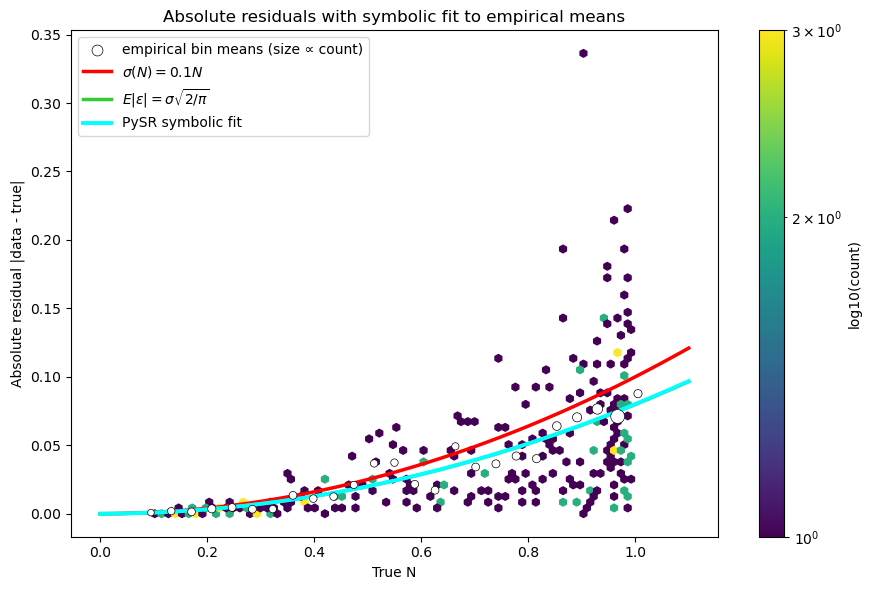

  - /var/folders/dn/jj6zl9nx6s541bq88x9x4zvm0000gn/T/tmp92sj_2xl/20260309_104459_eWNopf/hall_of_fame.csv


In [9]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from pysr import PySRRegressor

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
# ============================================================
r_true = 1.0
n_ics = 11
N0_list = np.random.uniform(0.01, 0.25, size=n_ics).tolist()

numpts = 4 * (24 // 4)
t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)
N_grid = torch.linspace(0.0, 1.1, 200, device=device).view(-1, 1)


def G_true(N):
    return r_true * N * (1.0 - N)


def sigma_true(N):
    return 0.1 * N**2


# ============================================================
# 2. RK4 integrator
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)


# ============================================================
# 3. Generate synthetic observed data
# ============================================================
y_true_list = []
y_data_list = []

with torch.no_grad():
    for N0 in N0_list:
        y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
        y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)
        noise = sigma_true(y_true) * torch.randn_like(y_true)
        y_data = y_true + noise

        y_true_list.append(y_true)
        y_data_list.append(y_data)

y_true_all = torch.stack(y_true_list, dim=0)
y_data_all = torch.stack(y_data_list, dim=0)
residuals_all = y_data_all - y_true_all
abs_residuals = torch.abs(residuals_all)

N_true_flat = y_true_all.squeeze(-1).reshape(-1).cpu().numpy()
abs_res_flat = abs_residuals.squeeze(-1).reshape(-1).cpu().numpy()

N_grid_np = N_grid.squeeze(-1).cpu().numpy()
sigma_grid_np = sigma_true(N_grid).squeeze(-1).cpu().numpy()
expected_abs = sigma_grid_np * np.sqrt(2 / np.pi)


# ============================================================
# 4. Build empirical means from bins
# ============================================================
bins = np.linspace(0.0, 1.1, 30)
centers = 0.5 * (bins[:-1] + bins[1:])
means = []
counts = []

for i in range(len(bins) - 1):
    mask = (N_true_flat >= bins[i]) & (N_true_flat < bins[i + 1])
    if np.any(mask):
        means.append(abs_res_flat[mask].mean())
        counts.append(mask.sum())
    else:
        means.append(np.nan)
        counts.append(0)

means = np.array(means, dtype=np.float64)
counts = np.array(counts, dtype=np.float64)

valid = ~np.isnan(means)
X_emp = centers[valid][:, None]          # shape [n_bins, 1]
Y_emp = means[valid]                     # shape [n_bins]
W_emp = counts[valid]                    # weights by number of points in bin


# ============================================================
# 5. Fit symbolic expression with PySR
# ============================================================
# We use count weights so bins with more residual points have
# more influence on the symbolic fit.
#
# Because the target should be nonnegative and increasing-ish,
# we keep the operator set simple. You can widen this later.
model = PySRRegressor(
    niterations=10,
    populations=8,
    population_size=40,
    maxsize=10,
    maxdepth=8,
    binary_operators=["+", "*", "-", "/"],
    unary_operators=[],
    model_selection="best",
    loss="loss(prediction, target, weight) = weight * (prediction - target)^2",
    verbosity=1,
    progress=True,
    temp_equation_file=True,
    delete_tempfiles=True,
)

model.fit(X_emp, Y_emp, weights=W_emp)

# Best symbolic expression
print("\nBest symbolic expression:")
print(model.get_best())

# Evaluate best symbolic model on grid
symbolic_pred = model.predict(N_grid_np.reshape(-1, 1))

# Optional: pretty export forms
try:
    print("\nSympy expression:")
    print(model.sympy())
except Exception:
    pass

try:
    print("\nLaTeX expression:")
    print(model.latex())
    print("Ideal", np.sqrt(2 / np.pi))
except Exception:
    pass


# ============================================================
# 6. Plot
# ============================================================
plt.figure(figsize=(9, 6))

hb = plt.hexbin(
    N_true_flat,
    abs_res_flat,
    gridsize=70,
    mincnt=1,
    bins="log"
)
plt.colorbar(hb, label="log10(count)")

marker_sizes = 20 + 80 * (W_emp / W_emp.max())
plt.scatter(
    X_emp[:, 0],
    Y_emp,
    s=marker_sizes,
    color="white",
    edgecolor="black",
    linewidth=0.5,
    label="empirical bin means (size ∝ count)",
    zorder=3
)

plt.plot(N_grid_np, sigma_grid_np, color="red", lw=2.5, label=r"$\sigma(N)=0.1N$")
plt.plot(N_grid_np, expected_abs, color="limegreen", lw=2.5, label=r"$E|\epsilon|=\sigma\sqrt{2/\pi}$")
plt.plot(N_grid_np, symbolic_pred, color="cyan", lw=2.8, label="PySR symbolic fit")

plt.xlabel("True N")
plt.ylabel("Absolute residual |data - true|")
plt.title("Absolute residuals with symbolic fit to empirical means")
plt.legend()
plt.tight_layout()
plt.show()


Starting PINN split 1/1
Dynamics init seed for split 1: 10000
Solution init seeds for split 1: [20000, 20001, 20002, 20003, 20004, 20005, 20006]
PINN | Split  1/1 | Epoch     1/3000 | Train Total: 4.872743e-01 | Train Data: 4.841432e-01 | Train Phys: 3.131071e-03 | Train Anchor: 8.872060e-03 | Val Total: 3.483458e-01 | Val Data: 3.452812e-01 | Val Phys: 3.064536e-03
PINN | Split  1/1 | Epoch   500/3000 | Train Total: 4.112623e-03 | Train Data: 3.553633e-03 | Train Phys: 5.589901e-04 | Train Anchor: 2.374638e-03 | Val Total: 2.797298e-03 | Val Data: 2.270003e-03 | Val Phys: 5.272952e-04
PINN | Split  1/1 | Epoch  1000/3000 | Train Total: 2.674725e-03 | Train Data: 2.535613e-03 | Train Phys: 1.391124e-04 | Train Anchor: 4.074414e-05 | Val Total: 1.335031e-03 | Val Data: 1.183669e-03 | Val Phys: 1.513621e-04
PINN | Split  1/1 | Epoch  1500/3000 | Train Total: 2.680364e-03 | Train Data: 2.487579e-03 | Train Phys: 1.927848e-04 | Train Anchor: 5.451381e-06 | Val Total: 1.279499e-03 | Val Da

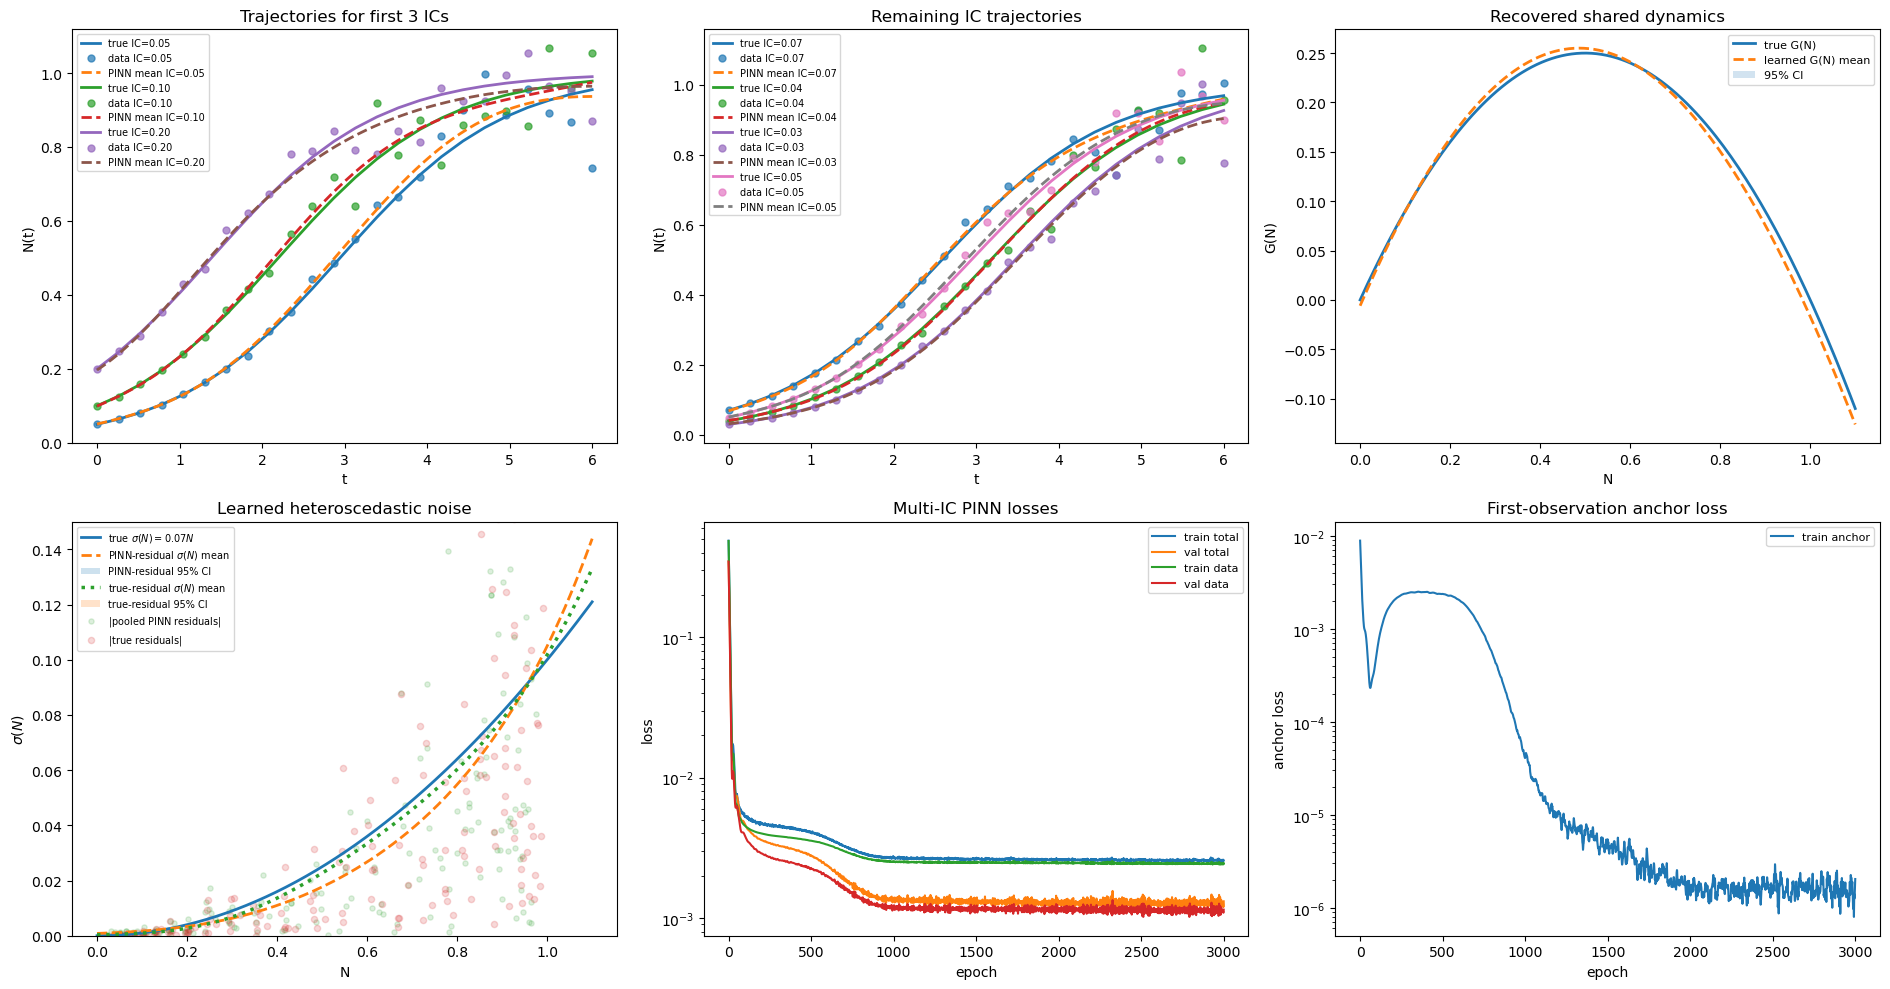

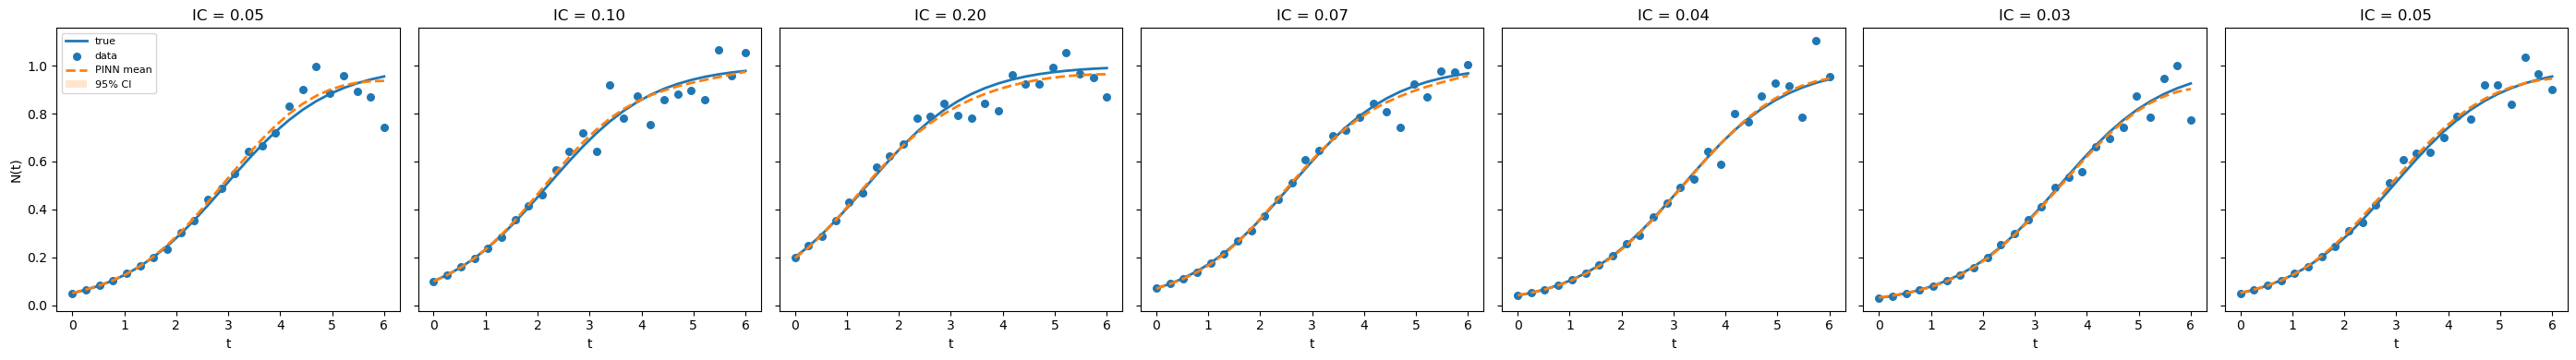

/var/folders/dn/jj6zl9nx6s541bq88x9x4zvm0000gn/T/ipykernel_84790/367038292.py:1085: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axes[0].set_yscale("log")


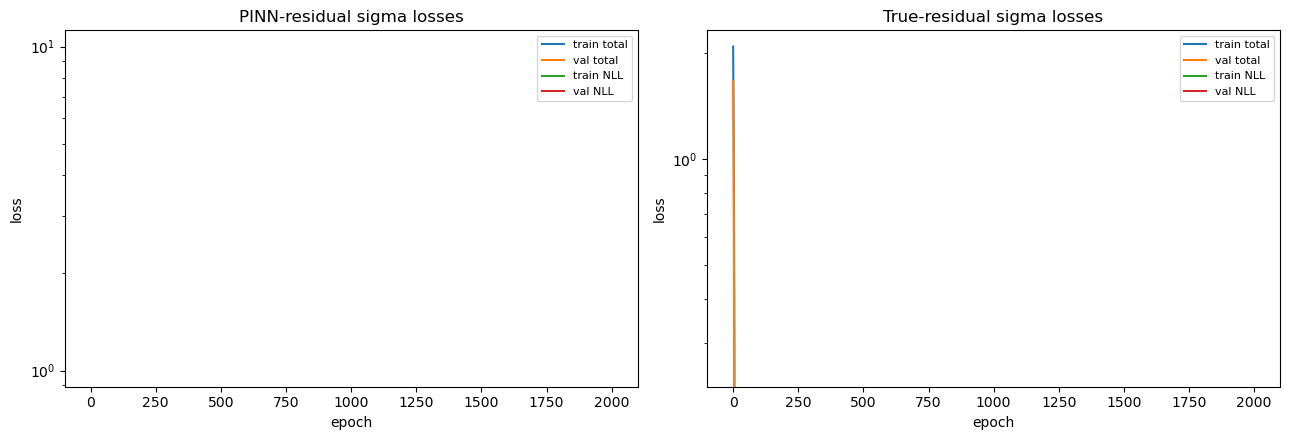

/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



Multi-IC PINN summary
---------------------
Number of trajectories / ICs: 7
Synthetic IC values used to generate data: [0.05, 0.1, 0.2, 0.07, 0.04, 0.03, 0.05]
Number of PINN splits: 1
Validation fraction: 0.2
Model-selection criterion: validation loss
Mean best selection loss: 1.120231e-03
Std  best selection loss: nan
Mean best epoch: 2791.00
Std  best epoch: nan
Anchor weight lambda_anchor: 0.000

Initialization summary by split
-------------------------------
Split 1: dyn_init_seed=10000, sol_init_seeds=[20000, 20001, 20002, 20003, 20004, 20005, 20006], selection_criterion=val

PINN-residual sigma summary
---------------------------
Number of sigma repeats: 1
Mean best selection loss: -6.995958e+00
Std  best selection loss: nan
Mean best epoch: 1999.00
Std  best epoch: nan

True-residual sigma summary
---------------------------
Number of sigma repeats: 1
Mean best selection loss: -7.785416e+00
Std  best selection loss: nan
Mean best epoch: 1999.00
Std  best epoch: nan

Observed t

In [35]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
# ============================================================
r_true = 1.0
N0_list = [0.05, 0.10, 0.20, 0.07, 0.04, 0.03, 0.05]
n_ics = len(N0_list)

numpts = 4 * (24 // 4)
t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)
t_plot = torch.linspace(0.0, 6.0, 200, device=device).view(-1, 1)
N_grid = torch.linspace(0.0, 1.1, 200, device=device).view(-1, 1)


def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# 2. Generate synthetic observed data for multiple ICs
#    Noise law is heteroscedastic: sigma_true(N) = 0.07 N
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)


y_true_list = []
y_data_list = []

with torch.no_grad():
    for N0 in N0_list:
        y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
        y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)
        y_data = y_true + 0.1 * torch.randn_like(y_true) * y_true**2

        y_true_list.append(y_true)
        y_data_list.append(y_data)

y_true_all = torch.stack(y_true_list, dim=0)   # [n_ics, numpts, 1]
y_data_all = torch.stack(y_data_list, dim=0)   # [n_ics, numpts, 1]

with torch.no_grad():
    G_grid_true = G_true(N_grid)
    sigma_true_grid = 0.1 * N_grid**2


# ============================================================
# 3. Model classes
# ============================================================
def init_weights_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        nn.init.zeros_(m.bias)
        
class SolutionNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        self.apply(init_weights_xavier)

    def forward(self, t):
        return self.net(t)


class DynamicsNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        self.apply(init_weights_xavier)

    def forward(self, N):
        return self.net(N)


class SigmaNet(nn.Module):
    def __init__(self, hidden_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
            nn.Softplus(),
        )

    def forward(self, N):
        return self.net(N) + 1e-4


# ============================================================
# 4. Helper functions
# ============================================================
def mean_and_ci(arr, ci=1.96):
    arr = np.array(arr)
    mean = arr.mean(axis=0)
    if arr.shape[0] == 1:
        lo = mean.copy()
        hi = mean.copy()
    else:
        sem = arr.std(axis=0, ddof=1) / np.sqrt(arr.shape[0])
        lo = mean - ci * sem
        hi = mean + ci * sem
    return mean, lo, hi

def g_zero_negative_penalty(dyn_net):
    N_zero = torch.zeros((1, 1), dtype=torch.float32, device=device)
    G_zero = dyn_net(N_zero)
    return torch.sum(torch.relu(-G_zero) ** 2)

def pinn_physics_residual(sol_net, dyn_net, t_col):
    N_pred_col = sol_net(t_col)
    dN_dt = torch.autograd.grad(
        outputs=N_pred_col,
        inputs=t_col,
        grad_outputs=torch.ones_like(N_pred_col),
        create_graph=True,
        retain_graph=True,
    )[0]
    rhs_pred = dyn_net(N_pred_col)
    phys_res = dN_dt - rhs_pred
    phys_res += g_zero_negative_penalty(dyn_net)
    return N_pred_col, dN_dt, rhs_pred, phys_res


def gaussian_sigma_nll(resid, sigma):
    sigma2 = sigma ** 2
    return torch.mean(torch.log(sigma2) + (resid ** 2) / sigma2)


def sigma_monotonicity_loss(model, N_col):
    N_req = N_col.clone().detach().requires_grad_(True)
    sigma_col = model(N_req)
    dsigma_dN = torch.autograd.grad(
        outputs=sigma_col,
        inputs=N_req,
        grad_outputs=torch.ones_like(sigma_col),
        create_graph=True,
        retain_graph=True,
    )[0]
    return torch.sum(torch.relu(-dsigma_dN) ** 2)


def fit_sigma_repeated(
    N_all,
    resid_all,
    N_eval_grid,
    N_col_base,
    n_repeats=1,
    val_fraction=0.2,
    n_epochs=3000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="sigma",
    print_every=500,
):
    n_samples = N_all.shape[0]
    use_validation = val_fraction > 0.0 and n_samples > 1

    if use_validation:
        n_val = int(round(val_fraction * n_samples))
        n_val = max(1, min(n_val, n_samples - 1))
    else:
        n_val = 0
    n_train = n_samples - n_val

    train_total_histories = []
    train_nll_histories = []
    train_mon_histories = []

    val_total_histories = []
    val_nll_histories = []
    val_mon_histories = []

    curve_histories = []
    best_val_losses = []
    best_epochs = []
    best_models = []

    for repeat in range(n_repeats):
        print(f"\n{'-' * 90}")
        print(f"Starting {label} repeat {repeat + 1}/{n_repeats}")
        print(f"{'-' * 90}")

        g = torch.Generator(device=device)
        g.manual_seed(seed_offset_split + repeat)

        perm = torch.randperm(n_samples, generator=g, device=device)
        train_idx = perm[:n_train].sort().values

        if use_validation:
            val_idx = perm[n_train:].sort().values
        else:
            val_idx = torch.empty(0, dtype=torch.long, device=device)

        N_train = N_all[train_idx]
        r_train = resid_all[train_idx]

        if use_validation:
            N_val = N_all[val_idx]
            r_val = resid_all[val_idx]

        torch.manual_seed(seed_offset_model + repeat)
        np.random.seed(seed_offset_model + repeat)

        sigma_net = SigmaNet(hidden_dim=hidden_dim).to(device)
        opt = torch.optim.Adam(sigma_net.parameters(), lr=lr)

        train_total_history = []
        train_nll_history = []
        train_mon_history = []

        val_total_history = []
        val_nll_history = []
        val_mon_history = []

        best_criterion = float("inf")
        best_epoch = -1
        best_state = None

        for epoch in range(n_epochs):
            opt.zero_grad()

            sigma_pred_train = sigma_net(N_train)
            train_nll = gaussian_sigma_nll(r_train, sigma_pred_train)
            train_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
            reg = lambda_reg * sum((p ** 2).sum() for p in sigma_net.parameters())

            train_total = train_nll + lambda_mon * train_mon + reg
            train_total.backward()
            opt.step()

            if use_validation:
                with torch.no_grad():
                    sigma_pred_val = sigma_net(N_val)
                    val_nll = gaussian_sigma_nll(r_val, sigma_pred_val)

                val_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
                val_total = val_nll + lambda_mon * val_mon

                criterion_value = val_total.item()
                val_total_item = val_total.item()
                val_nll_item = val_nll.item()
                val_mon_item = val_mon.item()
                criterion_name = "val"
            else:
                criterion_value = train_total.item()
                val_total_item = np.nan
                val_nll_item = np.nan
                val_mon_item = np.nan
                criterion_name = "train"

            train_total_history.append(train_total.item())
            train_nll_history.append(train_nll.item())
            train_mon_history.append(train_mon.item())

            val_total_history.append(val_total_item)
            val_nll_history.append(val_nll_item)
            val_mon_history.append(val_mon_item)

            if (epoch == 0) or ((epoch + 1) % print_every == 0) or (epoch == n_epochs - 1):
                if use_validation:
                    print(
                        f"{label} | Repeat {repeat + 1:2d}/{n_repeats} | "
                        f"Epoch {epoch + 1:5d}/{n_epochs} | "
                        f"Train Total: {train_total.item():.6e} | "
                        f"Train NLL: {train_nll.item():.6e} | "
                        f"Train Mon: {train_mon.item():.6e} | "
                        f"Val Total: {val_total_item:.6e} | "
                        f"Val NLL: {val_nll_item:.6e} | "
                        f"Val Mon: {val_mon_item:.6e}"
                    )
                else:
                    print(
                        f"{label} | Repeat {repeat + 1:2d}/{n_repeats} | "
                        f"Epoch {epoch + 1:5d}/{n_epochs} | "
                        f"Train Total: {train_total.item():.6e} | "
                        f"Train NLL: {train_nll.item():.6e} | "
                        f"Train Mon: {train_mon.item():.6e} | "
                        f"Val Total: N/A | Val NLL: N/A | Val Mon: N/A | "
                        f"Best-model criterion: training loss"
                    )

            if criterion_value < best_criterion:
                best_criterion = criterion_value
                best_epoch = epoch
                best_state = copy.deepcopy(sigma_net.state_dict())

        sigma_net.load_state_dict(best_state)
        sigma_net.eval()

        with torch.no_grad():
            sigma_curve = sigma_net(N_eval_grid).squeeze(1).cpu().numpy()

        best_models.append(copy.deepcopy(sigma_net))
        train_total_histories.append(train_total_history)
        train_nll_histories.append(train_nll_history)
        train_mon_histories.append(train_mon_history)

        val_total_histories.append(val_total_history)
        val_nll_histories.append(val_nll_history)
        val_mon_histories.append(val_mon_history)

        curve_histories.append(sigma_curve)
        best_val_losses.append(best_criterion)
        best_epochs.append(best_epoch)

        if use_validation:
            print(
                f"Finished {label} repeat {repeat + 1:2d}/{n_repeats} | "
                f"Best epoch = {best_epoch:5d} | Best val loss = {best_criterion:.6e}"
            )
        else:
            print(
                f"Finished {label} repeat {repeat + 1:2d}/{n_repeats} | "
                f"Best epoch = {best_epoch:5d} | Best train loss = {best_criterion:.6e}"
            )

    return {
        "train_total_histories": np.array(train_total_histories),
        "train_nll_histories": np.array(train_nll_histories),
        "train_mon_histories": np.array(train_mon_histories),
        "val_total_histories": np.array(val_total_histories),
        "val_nll_histories": np.array(val_nll_histories),
        "val_mon_histories": np.array(val_mon_histories),
        "curve_histories": np.array(curve_histories),
        "best_val_losses": np.array(best_val_losses),
        "best_epochs": np.array(best_epochs),
        "best_models": best_models,
    }


# ============================================================
# 5. Multi-IC PINN fit across train/validation splits
#    - one shared dyn_net
#    - one sol_net per IC
#    - NO true IC penalty
#    - optional anchor to first observed point
#    - DIVERSE NN INITIALIZATIONS across splits and ICs
#    - if val_fraction == 0, best model is chosen by training loss
# ============================================================
n_col = 1000
t_col_base = torch.linspace(0.0, 6.0, n_col, device=device).view(-1, 1)

n_epochs = 3000
n_splits = 1
print_every = 500
batch_obs = 24*4*n_ics
batch_col = 100

val_fraction = 0.2
n_obs = t_obs.shape[0]
use_validation = val_fraction > 0.0 and n_obs > 1

if use_validation:
    n_val = int(round(val_fraction * n_obs))
    n_val = max(1, min(n_val, n_obs - 1))
else:
    n_val = 0
n_train = n_obs - n_val

lambda_phys = 1.0
lambda_anchor = 0.0
learning_rate = 1e-3
hidden_dim_sol = 32
hidden_dim_dyn = 32

# seeds controlling diverse initializations
data_split_seed_base = 1000
dyn_init_seed_base = 10000
sol_init_seed_base = 20000

train_total_histories = []
train_data_histories = []
train_phys_histories = []
train_anchor_histories = []

val_total_histories = []
val_data_histories = []
val_phys_histories = []

traj_histories = []
rhs_histories = []
obs_fit_histories = []

best_val_losses = []
best_epochs = []
best_states = []

for split in range(n_splits):
    print(f"\n{'=' * 90}")
    print(f"Starting PINN split {split + 1}/{n_splits}")
    print(f"{'=' * 90}")

    # -------------------------
    # split-specific data split
    # -------------------------
    g = torch.Generator(device=device)
    g.manual_seed(data_split_seed_base + split)

    perm = torch.randperm(n_obs, generator=g, device=device)
    train_idx = perm[:n_train].sort().values

    if use_validation:
        val_idx = perm[n_train:].sort().values
    else:
        val_idx = torch.empty(0, dtype=torch.long, device=device)

    # -------------------------
    # DIVERSE model initialization
    # - different dyn_net init per split
    # - different sol_net init per split
    # - different sol_net init across ICs
    # -------------------------
    torch.manual_seed(dyn_init_seed_base + split)
    np.random.seed(dyn_init_seed_base + split)
    dyn_net = DynamicsNet(hidden_dim=hidden_dim_dyn).to(device)

    sol_net_list = []
    sol_init_seeds_this_split = []
    for i in range(n_ics):
        init_seed = sol_init_seed_base + 1000 * split + i
        sol_init_seeds_this_split.append(init_seed)
        torch.manual_seed(init_seed)
        np.random.seed(init_seed)
        sol_net_list.append(SolutionNet(hidden_dim=hidden_dim_sol).to(device))

    sol_nets = nn.ModuleList(sol_net_list)

    print(f"Dynamics init seed for split {split + 1}: {dyn_init_seed_base + split}")
    print(f"Solution init seeds for split {split + 1}: {sol_init_seeds_this_split}")

    optimizer = torch.optim.Adam(
        list(dyn_net.parameters()) + list(sol_nets.parameters()),
        lr=learning_rate,
    )

    train_total_history = []
    train_data_history = []
    train_phys_history = []
    train_anchor_history = []

    val_total_history = []
    val_data_history = []
    val_phys_history = []

    best_criterion = float("inf")
    best_epoch = -1
    best_state = None

    for epoch in range(n_epochs):
        optimizer.zero_grad()

        total_data_loss = 0.0
        total_phys_loss = 0.0
        total_anchor_loss = 0.0

        for i in range(n_ics):
            sol_net = sol_nets[i]

            # sample observation mini-batch from training indices
            obs_sel = train_idx[torch.randperm(len(train_idx), device=device)[:batch_obs]]
            t_train = t_obs[obs_sel]
            y_train = y_data_all[i][obs_sel]

            N_pred_train = sol_net(t_train)
            data_loss = torch.mean((N_pred_train - y_train) ** 2)

            # resample collocation points each epoch
            t_col = 6.0 * torch.rand(batch_col, 1, device=device)
            t_col.requires_grad_(True)
            _, _, _, phys_res = pinn_physics_residual(sol_net, dyn_net, t_col)
            phys_loss = torch.mean(phys_res ** 2)

            # anchor stays deterministic
            t0_obs = t_obs[0:1]
            y0_obs = y_data_all[i][0:1]
            N0_pred = sol_net(t0_obs)
            anchor_loss = torch.mean((N0_pred - y0_obs) ** 2)

            total_data_loss += data_loss
            total_phys_loss += phys_loss
            total_anchor_loss += anchor_loss

        total_data_loss /= n_ics
        total_phys_loss /= n_ics
        total_anchor_loss /= n_ics

        train_loss = total_data_loss + lambda_phys * total_phys_loss + lambda_anchor * total_anchor_loss
        train_loss.backward()
        optimizer.step()

        if use_validation:
            with torch.no_grad():
                total_val_data_loss = 0.0
                for i in range(n_ics):
                    sol_net = sol_nets[i]
                    t_val = t_obs[val_idx]
                    y_val = y_data_all[i][val_idx]
                    N_pred_val = sol_net(t_val)
                    total_val_data_loss = total_val_data_loss + torch.mean((N_pred_val - y_val) ** 2)

                total_val_data_loss = total_val_data_loss / n_ics

            total_val_phys_loss = 0.0
            for i in range(n_ics):
                sol_net = sol_nets[i]
                t_col_val = t_col_base.clone().detach().requires_grad_(True)
                _, _, _, val_phys_res = pinn_physics_residual(sol_net, dyn_net, t_col_val)
                total_val_phys_loss = total_val_phys_loss + torch.mean(val_phys_res ** 2)

            total_val_phys_loss = total_val_phys_loss / n_ics
            val_loss = total_val_data_loss + lambda_phys * total_val_phys_loss

            criterion_value = val_loss.item()
            criterion_name = "val"

            val_total_item = val_loss.item()
            val_data_item = total_val_data_loss.item()
            val_phys_item = total_val_phys_loss.item()
        else:
            criterion_value = train_loss.item()
            criterion_name = "train"

            val_total_item = np.nan
            val_data_item = np.nan
            val_phys_item = np.nan

        train_total_history.append(train_loss.item())
        train_data_history.append(total_data_loss.item())
        train_phys_history.append(total_phys_loss.item())
        train_anchor_history.append(total_anchor_loss.item())

        val_total_history.append(val_total_item)
        val_data_history.append(val_data_item)
        val_phys_history.append(val_phys_item)

        if (epoch == 0) or ((epoch + 1) % print_every == 0) or (epoch == n_epochs - 1):
            if use_validation:
                print(
                    f"PINN | Split {split + 1:2d}/{n_splits} | "
                    f"Epoch {epoch + 1:5d}/{n_epochs} | "
                    f"Train Total: {train_loss.item():.6e} | "
                    f"Train Data: {total_data_loss.item():.6e} | "
                    f"Train Phys: {total_phys_loss.item():.6e} | "
                    f"Train Anchor: {total_anchor_loss.item():.6e} | "
                    f"Val Total: {val_total_item:.6e} | "
                    f"Val Data: {val_data_item:.6e} | "
                    f"Val Phys: {val_phys_item:.6e}"
                )
            else:
                print(
                    f"PINN | Split {split + 1:2d}/{n_splits} | "
                    f"Epoch {epoch + 1:5d}/{n_epochs} | "
                    f"Train Total: {train_loss.item():.6e} | "
                    f"Train Data: {total_data_loss.item():.6e} | "
                    f"Train Phys: {total_phys_loss.item():.6e} | "
                    f"Train Anchor: {total_anchor_loss.item():.6e} | "
                    f"Val Total: N/A | Val Data: N/A | Val Phys: N/A | "
                    f"Best-model criterion: training loss"
                )

        if criterion_value < best_criterion:
            best_criterion = criterion_value
            best_epoch = epoch
            best_state = {
                "dyn_net": copy.deepcopy(dyn_net.state_dict()),
                "sol_nets": [copy.deepcopy(sol_net.state_dict()) for sol_net in sol_nets],
                "dyn_init_seed": dyn_init_seed_base + split,
                "sol_init_seeds": sol_init_seeds_this_split.copy(),
                "train_idx": train_idx.clone(),
                "val_idx": val_idx.clone(),
                "selection_criterion": criterion_name,
            }

    if use_validation:
        print(
            f"Finished PINN split {split + 1:2d}/{n_splits} | "
            f"Best epoch = {best_epoch:5d} | Best val loss = {best_criterion:.6e}"
        )
    else:
        print(
            f"Finished PINN split {split + 1:2d}/{n_splits} | "
            f"Best epoch = {best_epoch:5d} | Best train loss = {best_criterion:.6e}"
        )

    dyn_net.load_state_dict(best_state["dyn_net"])
    for i in range(n_ics):
        sol_nets[i].load_state_dict(best_state["sol_nets"][i])

    dyn_net.eval()
    for sol_net in sol_nets:
        sol_net.eval()

    with torch.no_grad():
        trajs_this_split = []
        obs_fits_this_split = []

        for i in range(n_ics):
            trajs_this_split.append(sol_nets[i](t_plot).squeeze(1).cpu().numpy())
            obs_fits_this_split.append(sol_nets[i](t_obs).squeeze(1).cpu().numpy())

        G_grid_learned = dyn_net(N_grid).squeeze(1).cpu().numpy()

    train_total_histories.append(train_total_history)
    train_data_histories.append(train_data_history)
    train_phys_histories.append(train_phys_history)
    train_anchor_histories.append(train_anchor_history)

    val_total_histories.append(val_total_history)
    val_data_histories.append(val_data_history)
    val_phys_histories.append(val_phys_history)

    traj_histories.append(np.array(trajs_this_split))
    obs_fit_histories.append(np.array(obs_fits_this_split))
    rhs_histories.append(G_grid_learned)

    best_val_losses.append(best_criterion)
    best_epochs.append(best_epoch)
    best_states.append(best_state)

train_total_histories = np.array(train_total_histories)
train_data_histories = np.array(train_data_histories)
train_phys_histories = np.array(train_phys_histories)
train_anchor_histories = np.array(train_anchor_histories)

val_total_histories = np.array(val_total_histories)
val_data_histories = np.array(val_data_histories)
val_phys_histories = np.array(val_phys_histories)

traj_histories = np.array(traj_histories)         # [n_splits, n_ics, len(t_plot)]
obs_fit_histories = np.array(obs_fit_histories)   # [n_splits, n_ics, len(t_obs)]
rhs_histories = np.array(rhs_histories)

rhs_mean, rhs_lo, rhs_hi = mean_and_ci(rhs_histories)

traj_mean_per_ic = []
traj_lo_per_ic = []
traj_hi_per_ic = []

obs_fit_mean_per_ic = []
obs_fit_lo_per_ic = []
obs_fit_hi_per_ic = []

for i in range(n_ics):
    m, lo, hi = mean_and_ci(traj_histories[:, i, :])
    traj_mean_per_ic.append(m)
    traj_lo_per_ic.append(lo)
    traj_hi_per_ic.append(hi)

    m, lo, hi = mean_and_ci(obs_fit_histories[:, i, :])
    obs_fit_mean_per_ic.append(m)
    obs_fit_lo_per_ic.append(lo)
    obs_fit_hi_per_ic.append(hi)


# ============================================================
# 6. Learn sigma(N) from pooled multi-IC PINN residuals
#    residual = y_data - N_hat_PINN
# ============================================================
with torch.no_grad():
    y_rep = y_data_all.squeeze(-1).cpu().numpy()[None, :, :]
    resid_pinn_all_np = y_rep - obs_fit_histories

    N_pinn_sigma_all_np = obs_fit_histories.reshape(-1, 1)
    resid_pinn_sigma_all_np = resid_pinn_all_np.reshape(-1, 1)

    mask = N_pinn_sigma_all_np.squeeze() > 0.0
    N_pinn_sigma_all_np = N_pinn_sigma_all_np[mask]
    resid_pinn_sigma_all_np = resid_pinn_sigma_all_np[mask]

N_pinn_sigma_all = torch.tensor(N_pinn_sigma_all_np, dtype=torch.float32, device=device)
resid_pinn_sigma_all = torch.tensor(resid_pinn_sigma_all_np, dtype=torch.float32, device=device)

N_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_pinn_sigma_all.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_pinn_results = fit_sigma_repeated(
    N_all=N_pinn_sigma_all,
    resid_all=resid_pinn_sigma_all,
    N_eval_grid=N_grid,
    N_col_base=N_sigma_col_base,
    n_repeats=1,
    val_fraction=0.4,
    n_epochs=2000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="PINN-sigma",
    print_every=250,
)

sigma_pinn_mean, sigma_pinn_lo, sigma_pinn_hi = mean_and_ci(
    sigma_pinn_results["curve_histories"]
)


# ============================================================
# 7. Learn sigma_truefit(N) from true residuals using all ICs
#    residual_true = y_data - y_true
# ============================================================
with torch.no_grad():
    N_true_sigma_np = y_true_all.squeeze(-1).cpu().numpy().reshape(-1, 1)
    resid_true_sigma_np = (y_data_all - y_true_all).squeeze(-1).cpu().numpy().reshape(-1, 1)

    mask_true = N_true_sigma_np.squeeze() > 0.0
    N_true_sigma_np = N_true_sigma_np[mask_true]
    resid_true_sigma_np = resid_true_sigma_np[mask_true]

N_true_sigma = torch.tensor(N_true_sigma_np, dtype=torch.float32, device=device)
resid_true_sigma = torch.tensor(resid_true_sigma_np, dtype=torch.float32, device=device)

N_true_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_true_sigma.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_truefit_results = fit_sigma_repeated(
    N_all=N_true_sigma,
    resid_all=resid_true_sigma,
    N_eval_grid=N_grid,
    N_col_base=N_true_sigma_col_base,
    n_repeats=1,
    val_fraction=0.2,
    n_epochs=2000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=9000,
    seed_offset_model=11000,
    label="TRUE-sigma",
    print_every=250,
)

sigma_truefit_mean, sigma_truefit_lo, sigma_truefit_hi = mean_and_ci(
    sigma_truefit_results["curve_histories"]
)


# ============================================================
# 8. Residuals across all ICs using mean PINN fit
# ============================================================
with torch.no_grad():
    obs_fit_mean_all = np.array(obs_fit_mean_per_ic)
    y_true_np = y_true_all.squeeze(-1).cpu().numpy()
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()

    residuals_all = y_data_np - obs_fit_mean_all
    N_fit_all = obs_fit_mean_all.reshape(-1, 1)
    residuals_flat = residuals_all.reshape(-1, 1)

    mask = N_fit_all.squeeze() > 0.0
    N_fit_all = N_fit_all[mask]
    residuals_flat = residuals_flat[mask]


# ============================================================
# 9. Plots
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(19, 10))

# ------------------------------------------------------------
# Trajectories for first 3 ICs
# ------------------------------------------------------------
for i in range(min(3, n_ics)):
    axes[0, 0].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        linewidth=2,
        label=f"true IC={N0_list[i]:.2f}",
    )
    axes[0, 0].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        s=25,
        alpha=0.7,
        label=f"data IC={N0_list[i]:.2f}",
    )
    axes[0, 0].plot(
        t_plot.cpu().numpy(),
        traj_mean_per_ic[i],
        "--",
        linewidth=2,
        label=f"PINN mean IC={N0_list[i]:.2f}",
    )
    axes[0, 0].fill_between(
        t_plot.squeeze(1).cpu().numpy(),
        traj_lo_per_ic[i],
        traj_hi_per_ic[i],
        alpha=0.18,
    )

axes[0, 0].set_xlabel("t")
axes[0, 0].set_ylabel("N(t)")
axes[0, 0].set_title("Trajectories for first 3 ICs")
axes[0, 0].legend(fontsize=7)

# ------------------------------------------------------------
# Trajectories for remaining ICs
# ------------------------------------------------------------
for i in range(3, n_ics):
    axes[0, 1].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        linewidth=2,
        label=f"true IC={N0_list[i]:.2f}",
    )
    axes[0, 1].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        s=25,
        alpha=0.7,
        label=f"data IC={N0_list[i]:.2f}",
    )
    axes[0, 1].plot(
        t_plot.cpu().numpy(),
        traj_mean_per_ic[i],
        "--",
        linewidth=2,
        label=f"PINN mean IC={N0_list[i]:.2f}",
    )
    axes[0, 1].fill_between(
        t_plot.squeeze(1).cpu().numpy(),
        traj_lo_per_ic[i],
        traj_hi_per_ic[i],
        alpha=0.18,
    )

axes[0, 1].set_xlabel("t")
axes[0, 1].set_ylabel("N(t)")
axes[0, 1].set_title("Remaining IC trajectories")
axes[0, 1].legend(fontsize=7)

# ------------------------------------------------------------
# Recovered dynamics
# ------------------------------------------------------------
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    G_grid_true.squeeze(1).cpu().numpy(),
    label="true G(N)",
    linewidth=2,
)
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    rhs_mean,
    "--",
    linewidth=2,
    label="learned G(N) mean",
)
axes[0, 2].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    rhs_lo,
    rhs_hi,
    alpha=0.20,
    label="95% CI",
)
axes[0, 2].set_xlabel("N")
axes[0, 2].set_ylabel("G(N)")
axes[0, 2].set_title("Recovered shared dynamics")
axes[0, 2].legend(fontsize=8)

# ------------------------------------------------------------
# Learned sigma(N): PINN residual sigma + true residual sigma
# ------------------------------------------------------------
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_true_grid.squeeze(1).cpu().numpy(),
    linewidth=2,
    label=r"true $\sigma(N)=0.07N$",
)
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_pinn_mean,
    "--",
    linewidth=2,
    label=r"PINN-residual $\sigma(N)$ mean",
)
axes[1, 0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_pinn_lo,
    sigma_pinn_hi,
    alpha=0.22,
    label="PINN-residual 95% CI",
)
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_truefit_mean,
    ":",
    linewidth=2.5,
    label=r"true-residual $\sigma(N)$ mean",
)
axes[1, 0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_truefit_lo,
    sigma_truefit_hi,
    alpha=0.22,
    label="true-residual 95% CI",
)
axes[1, 0].scatter(
    N_pinn_sigma_all.cpu().numpy().squeeze(),
    np.abs(resid_pinn_sigma_all.cpu().numpy().squeeze()),
    s=14,
    alpha=0.16,
    label=r"$|$pooled PINN residuals$|$",
)
axes[1, 0].scatter(
    N_true_sigma.cpu().numpy().squeeze(),
    np.abs(resid_true_sigma.cpu().numpy().squeeze()),
    s=20,
    alpha=0.18,
    label=r"$|$true residuals$|$",
)
axes[1, 0].set_xlabel("N")
axes[1, 0].set_ylabel(r"$\sigma(N)$")
axes[1, 0].set_title("Learned heteroscedastic noise")
axes[1, 0].legend(fontsize=7)
axes[1, 0].set_ylim(0, 0.15)

# ------------------------------------------------------------
# PINN training losses
# ------------------------------------------------------------
epochs_init = np.arange(n_epochs)

train_total_mean, train_total_lo, train_total_hi = mean_and_ci(train_total_histories)
val_total_mean, val_total_lo, val_total_hi = mean_and_ci(val_total_histories)
train_data_mean, train_data_lo, train_data_hi = mean_and_ci(train_data_histories)
val_data_mean, val_data_lo, val_data_hi = mean_and_ci(val_data_histories)

axes[1, 1].plot(epochs_init, train_total_mean, label="train total")
axes[1, 1].fill_between(epochs_init, train_total_lo, train_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, val_total_mean, label="val total")
axes[1, 1].fill_between(epochs_init, val_total_lo, val_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, train_data_mean, label="train data")
axes[1, 1].fill_between(epochs_init, train_data_lo, train_data_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, val_data_mean, label="val data")
axes[1, 1].fill_between(epochs_init, val_data_lo, val_data_hi, alpha=0.2)
axes[1, 1].set_yscale("log")
axes[1, 1].set_xlabel("epoch")
axes[1, 1].set_ylabel("loss")
axes[1, 1].set_title("Multi-IC PINN losses")
axes[1, 1].legend(fontsize=8)

# ------------------------------------------------------------
# Anchor loss
# ------------------------------------------------------------
train_anchor_mean, train_anchor_lo, train_anchor_hi = mean_and_ci(train_anchor_histories)
axes[1, 2].plot(epochs_init, train_anchor_mean, label="train anchor")
axes[1, 2].fill_between(epochs_init, train_anchor_lo, train_anchor_hi, alpha=0.2)
axes[1, 2].set_yscale("log")
axes[1, 2].set_xlabel("epoch")
axes[1, 2].set_ylabel("anchor loss")
axes[1, 2].set_title("First-observation anchor loss")
axes[1, 2].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# 10. Observation-time comparison for all ICs
# ============================================================
fig, axs = plt.subplots(1, n_ics, figsize=(4 * n_ics, 4), sharey=True)

if n_ics == 1:
    axs = [axs]

for i in range(n_ics):
    axs[i].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        label="true",
        linewidth=2,
    )
    axs[i].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        label="data",
        s=30,
    )
    axs[i].plot(
        t_obs.cpu().numpy(),
        obs_fit_mean_per_ic[i],
        "--",
        linewidth=2,
        label="PINN mean",
    )
    axs[i].fill_between(
        t_obs.squeeze(1).cpu().numpy(),
        obs_fit_lo_per_ic[i],
        obs_fit_hi_per_ic[i],
        alpha=0.20,
        label="95% CI",
    )
    axs[i].set_title(f"IC = {N0_list[i]:.2f}")
    axs[i].set_xlabel("t")

axs[0].set_ylabel("N(t)")
axs[0].legend(fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# 11. Sigma training diagnostics
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

epochs_sigma = np.arange(sigma_pinn_results["train_total_histories"].shape[1])

sp_train_total_mean, sp_train_total_lo, sp_train_total_hi = mean_and_ci(
    sigma_pinn_results["train_total_histories"]
)
sp_val_total_mean, sp_val_total_lo, sp_val_total_hi = mean_and_ci(
    sigma_pinn_results["val_total_histories"]
)
sp_train_nll_mean, sp_train_nll_lo, sp_train_nll_hi = mean_and_ci(
    sigma_pinn_results["train_nll_histories"]
)
sp_val_nll_mean, sp_val_nll_lo, sp_val_nll_hi = mean_and_ci(
    sigma_pinn_results["val_nll_histories"]
)

axes[0].plot(epochs_sigma, sp_train_total_mean, label="train total")
axes[0].fill_between(epochs_sigma, sp_train_total_lo, sp_train_total_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_val_total_mean, label="val total")
axes[0].fill_between(epochs_sigma, sp_val_total_lo, sp_val_total_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_train_nll_mean, label="train NLL")
axes[0].fill_between(epochs_sigma, sp_train_nll_lo, sp_train_nll_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_val_nll_mean, label="val NLL")
axes[0].fill_between(epochs_sigma, sp_val_nll_lo, sp_val_nll_hi, alpha=0.2)
axes[0].set_yscale("log")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("PINN-residual sigma losses")
axes[0].legend(fontsize=8)

st_train_total_mean, st_train_total_lo, st_train_total_hi = mean_and_ci(
    sigma_truefit_results["train_total_histories"]
)
st_val_total_mean, st_val_total_lo, st_val_total_hi = mean_and_ci(
    sigma_truefit_results["val_total_histories"]
)
st_train_nll_mean, st_train_nll_lo, st_train_nll_hi = mean_and_ci(
    sigma_truefit_results["train_nll_histories"]
)
st_val_nll_mean, st_val_nll_lo, st_val_nll_hi = mean_and_ci(
    sigma_truefit_results["val_nll_histories"]
)

axes[1].plot(epochs_sigma, st_train_total_mean, label="train total")
axes[1].fill_between(epochs_sigma, st_train_total_lo, st_train_total_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_val_total_mean, label="val total")
axes[1].fill_between(epochs_sigma, st_val_total_lo, st_val_total_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_train_nll_mean, label="train NLL")
axes[1].fill_between(epochs_sigma, st_train_nll_lo, st_train_nll_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_val_nll_mean, label="val NLL")
axes[1].fill_between(epochs_sigma, st_val_nll_lo, st_val_nll_hi, alpha=0.2)
axes[1].set_yscale("log")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].set_title("True-residual sigma losses")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# 12. Summary
# ============================================================
print("\nMulti-IC PINN summary")
print("---------------------")
print(f"Number of trajectories / ICs: {n_ics}")
print(f"Synthetic IC values used to generate data: {N0_list}")
print(f"Number of PINN splits: {n_splits}")
print(f"Validation fraction: {val_fraction}")
print(f"Model-selection criterion: {'validation loss' if use_validation else 'training loss'}")
print(f"Mean best selection loss: {np.mean(best_val_losses):.6e}")
print(f"Std  best selection loss: {np.std(best_val_losses, ddof=1):.6e}")
print(f"Mean best epoch: {np.mean(best_epochs):.2f}")
print(f"Std  best epoch: {np.std(best_epochs, ddof=1):.2f}")
print(f"Anchor weight lambda_anchor: {lambda_anchor:.3f}")

print("\nInitialization summary by split")
print("-------------------------------")
for split, st in enumerate(best_states, start=1):
    print(
        f"Split {split}: dyn_init_seed={st['dyn_init_seed']}, "
        f"sol_init_seeds={st['sol_init_seeds']}, "
        f"selection_criterion={st['selection_criterion']}"
    )

print("\nPINN-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_pinn_results['best_val_losses'])}")
print(f"Mean best selection loss: {sigma_pinn_results['best_val_losses'].mean():.6e}")
print(f"Std  best selection loss: {sigma_pinn_results['best_val_losses'].std(ddof=1):.6e}")
print(f"Mean best epoch: {sigma_pinn_results['best_epochs'].mean():.2f}")
print(f"Std  best epoch: {sigma_pinn_results['best_epochs'].std(ddof=1):.2f}")

print("\nTrue-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_truefit_results['best_val_losses'])}")
print(f"Mean best selection loss: {sigma_truefit_results['best_val_losses'].mean():.6e}")
print(f"Std  best selection loss: {sigma_truefit_results['best_val_losses'].std(ddof=1):.6e}")
print(f"Mean best epoch: {sigma_truefit_results['best_epochs'].mean():.2f}")
print(f"Std  best epoch: {sigma_truefit_results['best_epochs'].std(ddof=1):.2f}")

print("\nObserved time points: true vs data vs PINN mean")
for i in range(n_ics):
    print(f"\nTrajectory {i + 1} (synthetic IC used to generate data = {N0_list[i]:.2f})")
    for ti, yt, yd, mu in zip(
        t_obs.squeeze(1).cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        obs_fit_mean_per_ic[i],
    ):
        print(
            f"t = {ti:6.3f} | true = {yt:8.5f} | data = {yd:8.5f} | PINN = {mu:8.5f}"
        )


Pooled symbolic regression on learned G(N) curves from dyn_net
Number of learned G(N) curves: 1
PySR runs per curve: 1
Total symbolic fits to run: 1

--- G symbolic fit | curve 1/1 | run 1/1 | seed=10000 ---


/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:1017: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:2776: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:1850: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


Number of equations reported in equations_: 7
Number of 'good' equations retained from this run: 2
Best equation:
complexity                                                      11
loss                                                           0.0
equation         ((-0.2012686 - (x0 * -0.20120053)) * x0) * (x0...
score                                                     3.235246
sympy_format     x0*(x0 - 5.4542894)*(-(-0.20120053)*x0 - 0.201...
lambda_format    PySRFunction(X=>x0*(x0 - 5.4542894)*(-(-0.2012...
Name: 5, dtype: object
Sympy expression:
x0*(x0 - 5.4542894)*(-(-0.20120053)*x0 - 0.2012686)

Pooling finished
Total good equations before deduplication: 2
Total good equations after deduplication: 2

================ G(N) CONSENSUS MOTIFS ================

C*tanh(0.799503156758264*x0)  freq=50.00%  mean=+1.3211  std=0.0000  median=+1.3211
C*x0                  freq=50.00%  mean=+1.0978  std=0.0000  median=+1.0978
C*x0**2               freq=50.00%  mean=-1.2987  std=0.0000  media

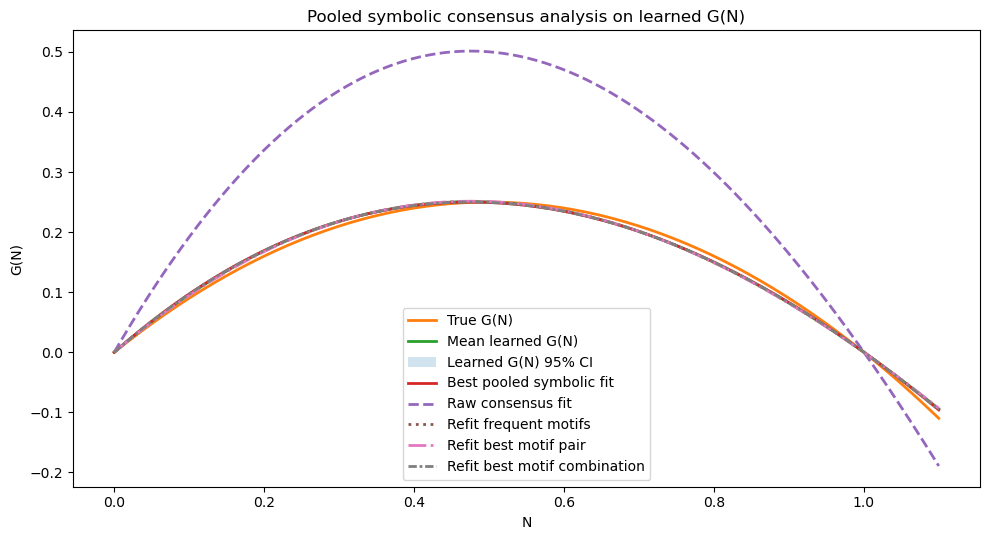

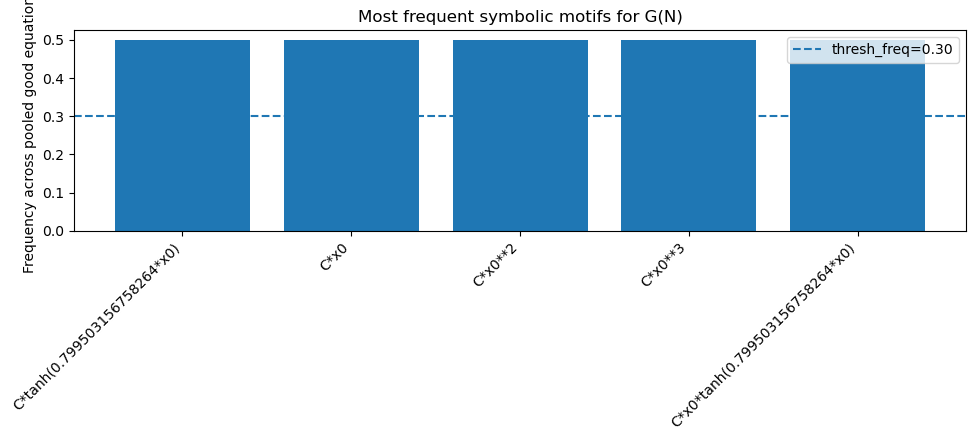

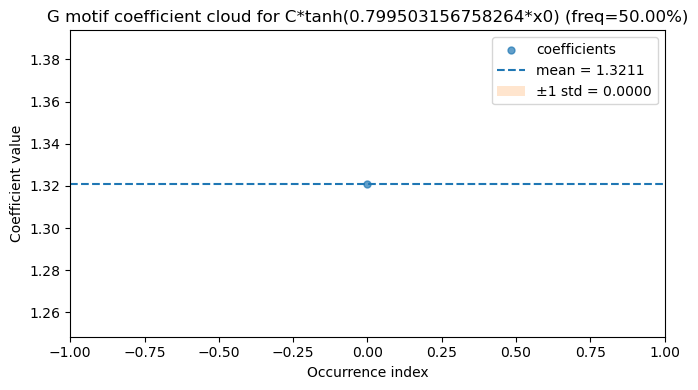

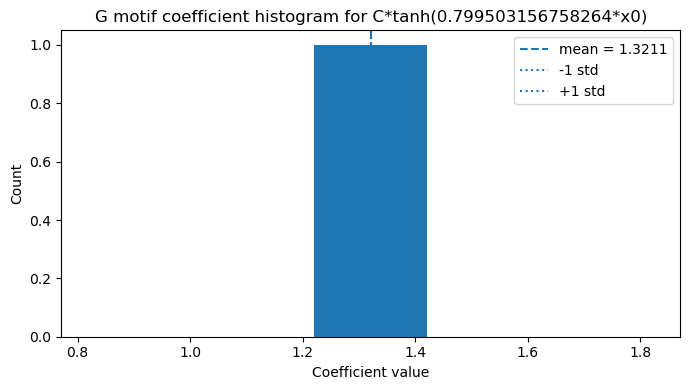

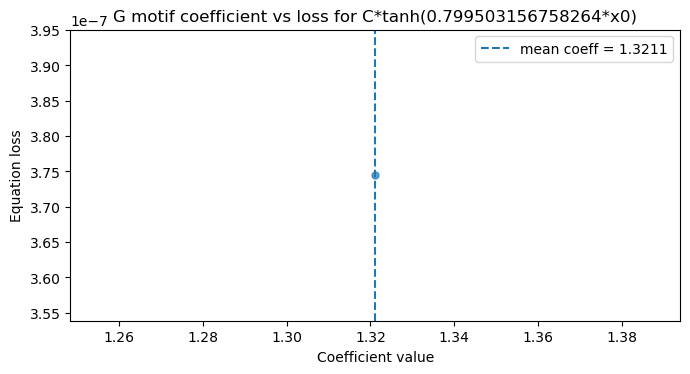

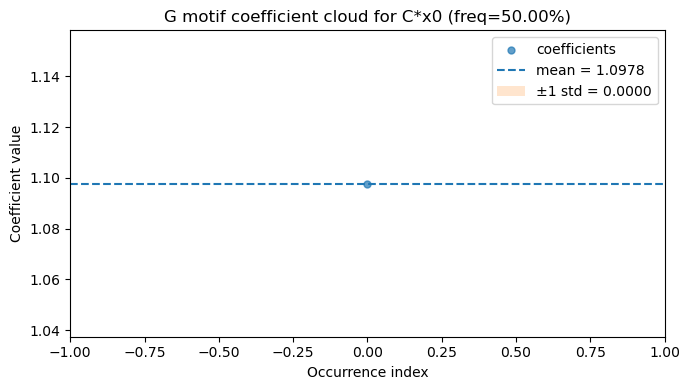

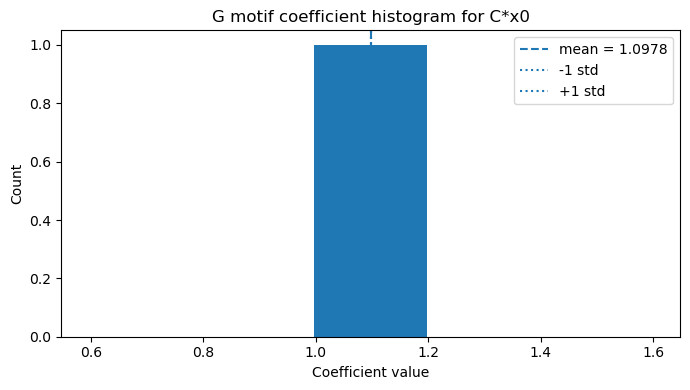

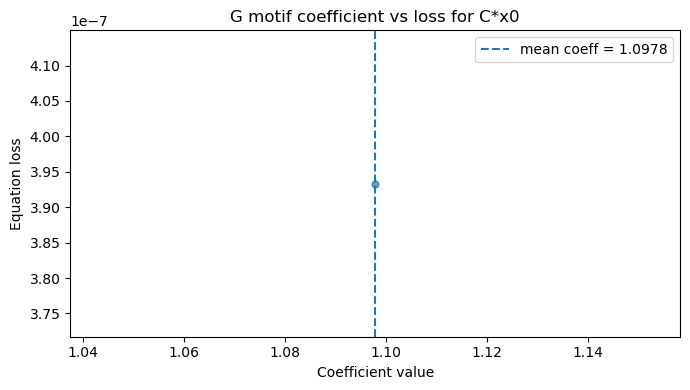

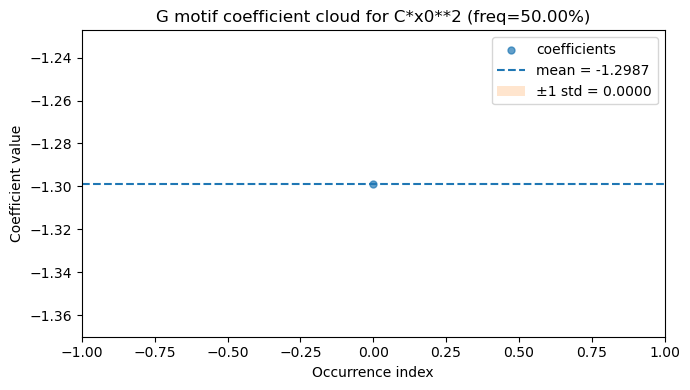

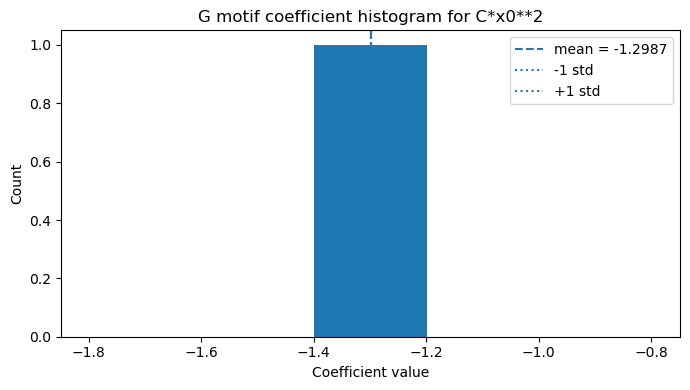

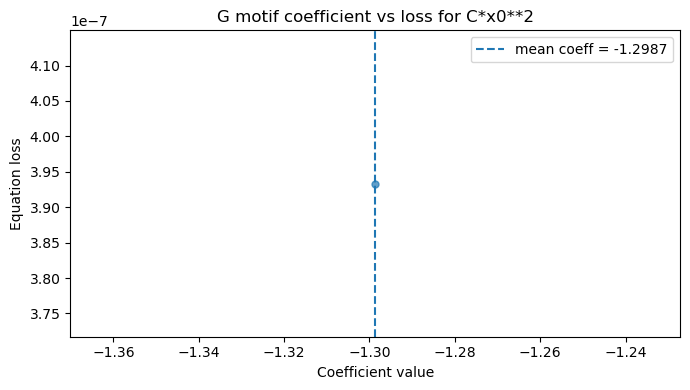

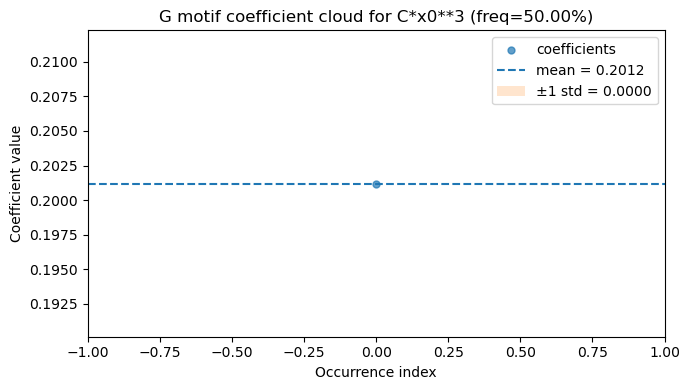

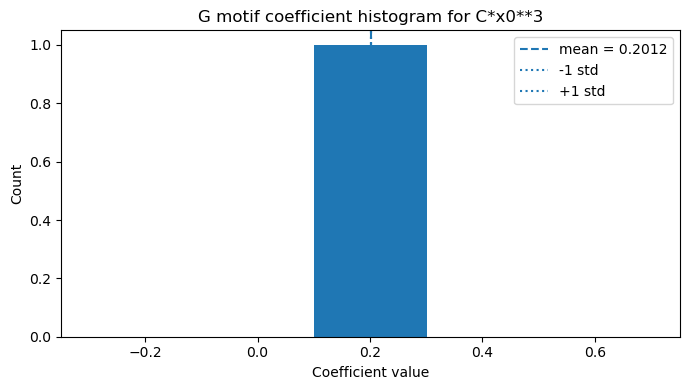

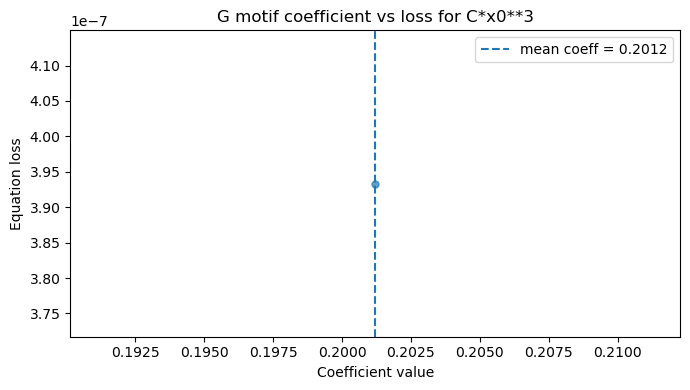

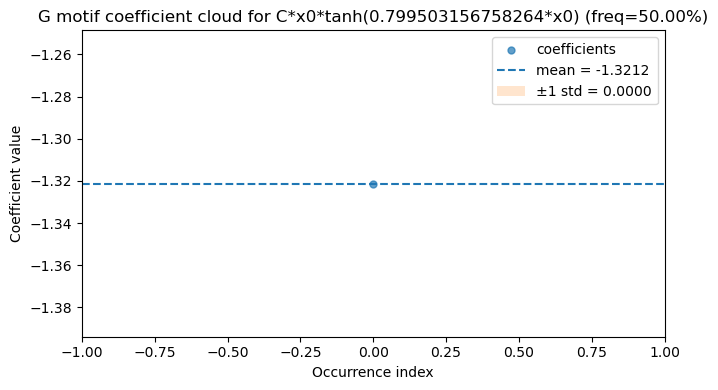

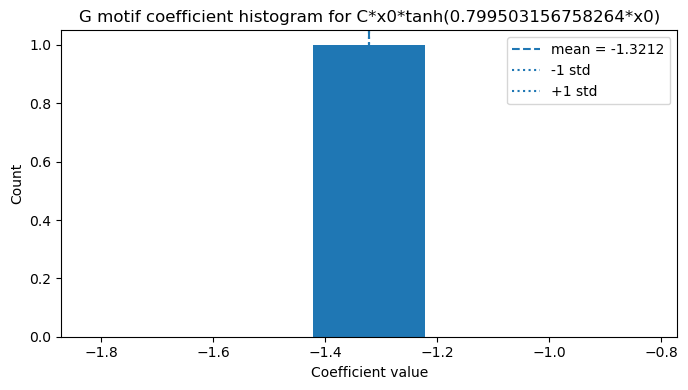

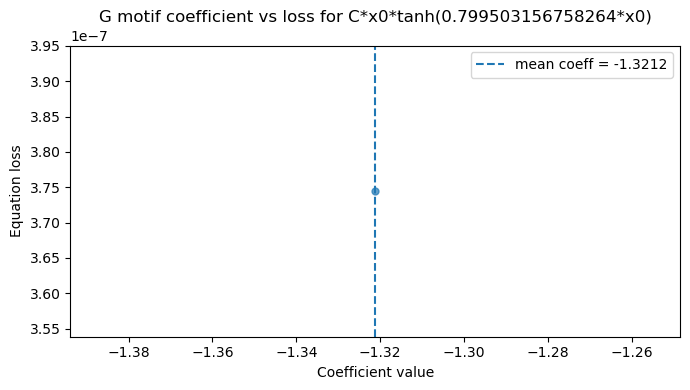

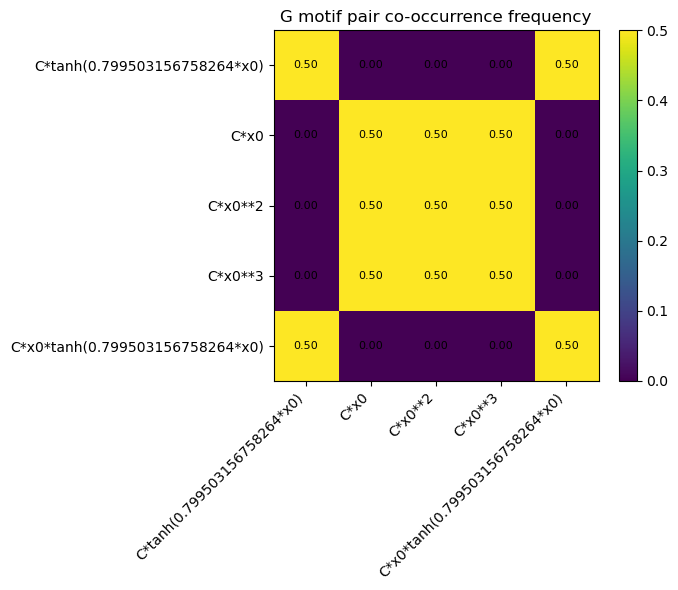

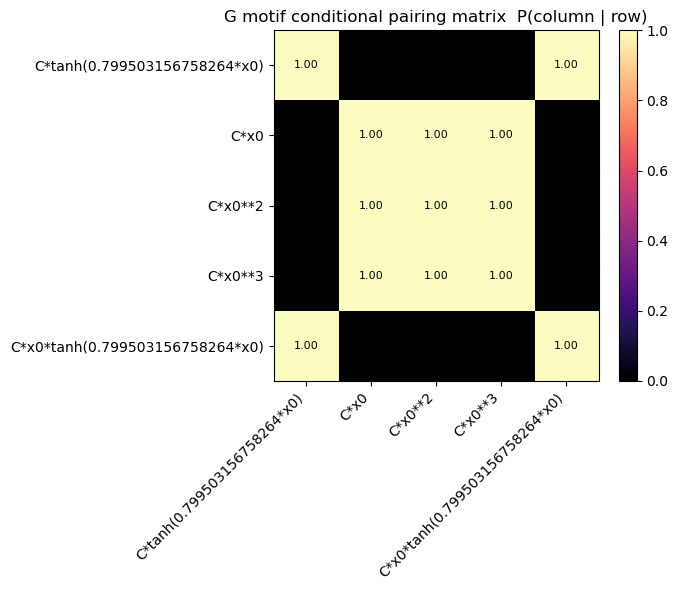

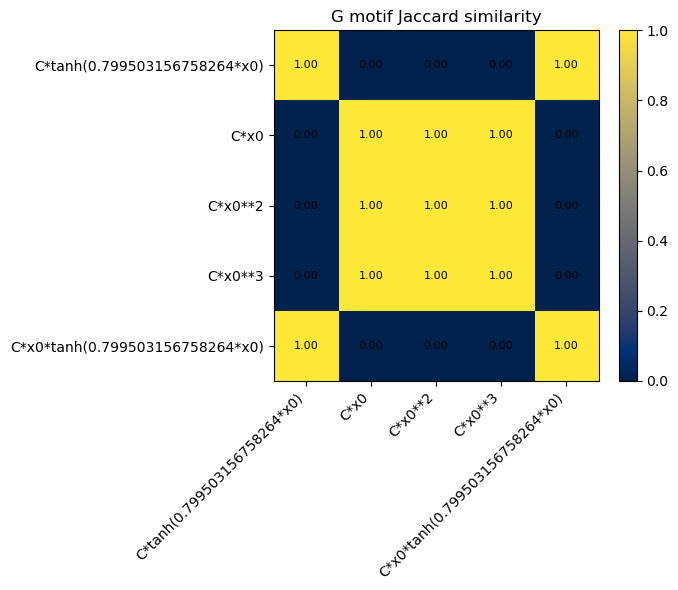

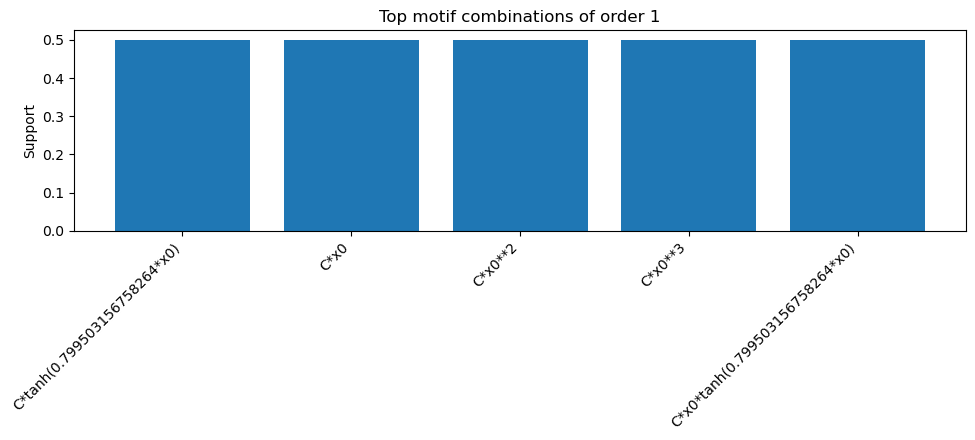

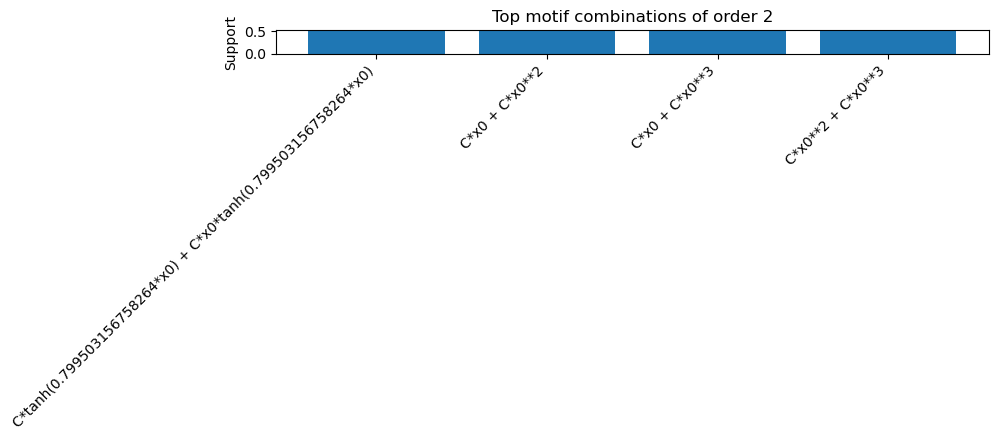

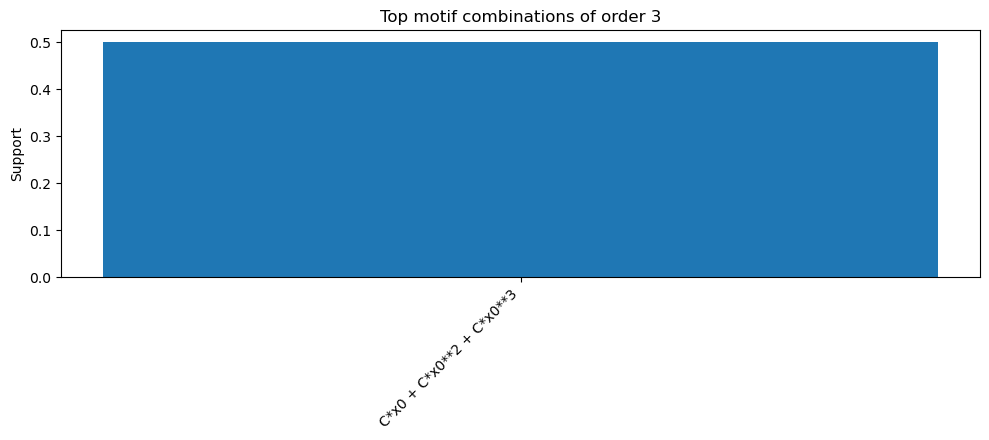


================ G(N) SUMMARY TABLE ================

                          motif  frequency  num_coeffs  mean_coeff  std_coeff  median_coeff
   C*tanh(0.799503156758264*x0)        0.5           1    1.321114        0.0      1.321114
                           C*x0        0.5           1    1.097777        0.0      1.097777
                        C*x0**2        0.5           1   -1.298675        0.0     -1.298675
                        C*x0**3        0.5           1    0.201201        0.0      0.201201
C*x0*tanh(0.799503156758264*x0)        0.5           1   -1.321220        0.0     -1.321220

================ TOP POOLED GOOD G(N) EQUATIONS ================

 curve_idx  run_idx         loss  complexity                                                expr                                                                         expr_canonical
         0        0 3.744502e-07          12      tanh(x0/1.2507768)*1.3212197*(0.99992037 - x0) -1.3212197*x0*tanh(0.799503156758264*x0) + 1.

In [38]:
# ============================================================
# 13. Symbolic consensus analysis on learned G(N)
#     POOLED across many independent PySR fits
# ============================================================
import sympy as sp
import pandas as pd
from itertools import combinations
from collections import Counter, defaultdict
from pysr import PySRRegressor

# ============================================================
# Settings
# ============================================================
# IMPORTANT:
# This is the main fix for the "equations_ is too small" issue:
# run MANY PySR fits and pool all equations_ tables.
symbolic_n_runs_per_curve = 1

symbolic_rel_loss_threshold = 1.25
symbolic_thresh_freq = 0.30
symbolic_signed_thresh = symbolic_thresh_freq / 2
symbolic_top_k_motifs_for_pairing = 10

symbolic_max_combo_order = 4
symbolic_combo_min_support = 0.15
symbolic_combo_top_k_candidates = 14
symbolic_max_complexity_keep = None

# Optional deduplication tolerance on symbolic strings after simplification
symbolic_deduplicate_equations = True

pysr_G_kwargs = dict(
    niterations=100,
    populations=100,
    population_size=100,
    maxsize=12,
    maxdepth=6,

    model_selection="best",

    binary_operators=["+", "-", "*", "/"],
    unary_operators=["exp", "log", "tanh", "sqrt"],

    nested_constraints={
        "exp": {"exp": 0},
        "log": {"log": 0},
        "tanh": {"tanh": 0},
    },

    complexity_of_operators={
        "+": 1,
        "-": 1,
        "*": 1,
        "/": 1,
        "exp": 3,
        "log": 3,
        "tanh": 3,
        "sqrt": 3,
    },

    extra_sympy_mappings={},
    loss="loss(prediction, target) = (prediction - target)^2",

    verbosity=0,
)

# ============================================================
# Helper functions
# ============================================================
x = sp.Symbol("x0")

def to_sympy_expr(obj):
    if isinstance(obj, sp.Expr):
        return obj
    return sp.sympify(obj)

def safe_float(val):
    try:
        return float(val)
    except Exception:
        return np.nan

def canonicalize_rest(rest):
    rest = sp.expand(rest)
    return sp.sstr(rest)

def sign_label(coeff):
    if not np.isfinite(coeff):
        return "nan"
    if coeff > 0:
        return "+"
    if coeff < 0:
        return "-"
    return "0"

def extract_term_records(expr):
    """
    Expand expression into additive terms and extract motif information.
    """
    expr = sp.expand(expr)
    terms = expr.as_ordered_terms()
    records = []

    for term in terms:
        coeff, rest = term.as_coeff_Mul()

        if rest == 1:
            coeff_value = safe_float(coeff)
            motif = "CONST"
            signed_motif = f"{sign_label(coeff_value)}CONST"
            records.append({
                "motif": motif,
                "signed_motif": signed_motif,
                "coeff": coeff_value,
                "rest": sp.Integer(1),
                "sign": sign_label(coeff_value),
            })
            continue

        rest_canon = canonicalize_rest(rest)

        if coeff == 1:
            motif = rest_canon
            coeff_value = 1.0
            signed_motif = f"+{rest_canon}"
        elif coeff == -1:
            motif = f"C*{rest_canon}"
            coeff_value = -1.0
            signed_motif = f"-C*{rest_canon}"
        else:
            motif = f"C*{rest_canon}"
            coeff_value = safe_float(coeff)
            signed_motif = f"{sign_label(coeff_value)}{motif}"

        records.append({
            "motif": motif,
            "signed_motif": signed_motif,
            "coeff": coeff_value,
            "rest": rest,
            "sign": sign_label(coeff_value),
        })

    return records

def get_good_equations_df(model, rel_loss_threshold=1.10, max_complexity_keep=None):
    eq_df = model.equations_.copy()
    eq_df["loss"] = pd.to_numeric(eq_df["loss"], errors="coerce")

    best_loss = eq_df["loss"].min()
    good_df = eq_df[eq_df["loss"] <= rel_loss_threshold * best_loss].copy()

    if max_complexity_keep is not None and "complexity" in good_df.columns:
        good_df = good_df[good_df["complexity"] <= max_complexity_keep].copy()

    return good_df

def canonical_equation_string(expr):
    """
    Canonical-ish string for deduplication across runs.
    """
    try:
        expr = sp.expand(sp.simplify(expr))
    except Exception:
        expr = sp.expand(expr)
    return sp.sstr(expr)

def analyze_good_equations(good_df, curve_idx, run_idx):
    equation_records = []
    motif_presence_counter = Counter()
    signed_motif_presence_counter = Counter()
    motif_coeffs = defaultdict(list)
    motif_coeff_loss_pairs = defaultdict(list)

    for _, row in good_df.iterrows():
        expr = to_sympy_expr(row["sympy_format"])
        loss = safe_float(row["loss"])
        complexity = row["complexity"] if "complexity" in row else np.nan

        term_records = extract_term_records(expr)
        present_motifs = set(rec["motif"] for rec in term_records)
        present_signed_motifs = set(rec["signed_motif"] for rec in term_records)

        for motif in present_motifs:
            motif_presence_counter[motif] += 1
        for sm in present_signed_motifs:
            signed_motif_presence_counter[sm] += 1

        for rec in term_records:
            coeff = rec["coeff"]
            if np.isfinite(coeff):
                motif_coeffs[rec["motif"]].append(coeff)
                motif_coeff_loss_pairs[rec["motif"]].append((coeff, loss))

        equation_records.append({
            "curve_idx": curve_idx,
            "run_idx": run_idx,
            "expr": expr,
            "expr_str": sp.sstr(expr),
            "expr_canonical": canonical_equation_string(expr),
            "loss": loss,
            "complexity": complexity,
            "term_records": term_records,
            "present_motifs": present_motifs,
            "present_signed_motifs": present_signed_motifs,
        })

    return (
        equation_records,
        motif_presence_counter,
        signed_motif_presence_counter,
        motif_coeffs,
        motif_coeff_loss_pairs,
    )

def deduplicate_equation_records(equation_records):
    """
    Keep only the best-loss copy of each canonical expression.
    """
    best_by_expr = {}
    for rec in equation_records:
        key = rec["expr_canonical"]
        if key not in best_by_expr or rec["loss"] < best_by_expr[key]["loss"]:
            best_by_expr[key] = rec
    return list(best_by_expr.values())

def recompute_stats_from_records(equation_records):
    motif_presence_counter = Counter()
    signed_motif_presence_counter = Counter()
    motif_coeffs = defaultdict(list)
    motif_coeff_loss_pairs = defaultdict(list)

    for rec in equation_records:
        for motif in rec["present_motifs"]:
            motif_presence_counter[motif] += 1
        for sm in rec["present_signed_motifs"]:
            signed_motif_presence_counter[sm] += 1
        for term_rec in rec["term_records"]:
            coeff = term_rec["coeff"]
            motif = term_rec["motif"]
            if np.isfinite(coeff):
                motif_coeffs[motif].append(coeff)
                motif_coeff_loss_pairs[motif].append((coeff, rec["loss"]))

    return (
        motif_presence_counter,
        signed_motif_presence_counter,
        motif_coeffs,
        motif_coeff_loss_pairs,
    )

def motif_to_basis_expr(motif):
    if motif == "CONST":
        return sp.Integer(1)
    if motif.startswith("C*"):
        return sp.sympify(motif[2:])
    return sp.sympify(motif)

def build_design_matrix(X_1d, motifs):
    cols = []
    basis_exprs = []
    n = len(X_1d)

    for motif in motifs:
        basis_expr = motif_to_basis_expr(motif)
        func = sp.lambdify(x, basis_expr, "numpy")
        vals = func(X_1d)
        vals = np.asarray(vals, dtype=float)

        if vals.ndim == 0:
            vals = np.full(n, float(vals))
        elif vals.shape == (1,):
            vals = np.full(n, float(vals[0]))
        else:
            vals = vals.reshape(-1)

        if len(vals) != n:
            raise ValueError(
                f"Basis '{motif}' produced length {len(vals)} but expected {n}."
            )

        cols.append(vals)
        basis_exprs.append(basis_expr)

    return np.column_stack(cols), basis_exprs

def refit_structure_least_squares(X_1d, y, motifs):
    if len(motifs) == 0:
        return None, None, None

    A, basis_exprs = build_design_matrix(X_1d, motifs)

    keep_idx = []
    kept_cols = []
    for j in range(A.shape[1]):
        col = A[:, j]
        is_duplicate = any(np.allclose(col, prev_col) for prev_col in kept_cols)
        if not is_duplicate:
            keep_idx.append(j)
            kept_cols.append(col)

    if len(keep_idx) == 0:
        return None, None, None

    A = A[:, keep_idx]
    kept_basis_exprs = [basis_exprs[j] for j in keep_idx]
    kept_motifs = [motifs[j] for j in keep_idx]

    coeffs, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
    y_pred = A @ coeffs

    expr = 0
    for c, b in zip(coeffs, kept_basis_exprs):
        expr += float(c) * b

    return sp.expand(expr), list(zip(kept_motifs, coeffs)), y_pred

def build_consensus_equation(motif_freq, motif_coeffs, thresh_freq):
    expr = 0
    used_terms = []

    for motif, freq in sorted(motif_freq.items(), key=lambda kv: (-kv[1], kv[0])):
        if freq < thresh_freq:
            continue
        if motif not in motif_coeffs or len(motif_coeffs[motif]) == 0:
            continue

        mean_coeff = float(np.mean(motif_coeffs[motif]))

        if motif == "CONST":
            expr += mean_coeff
        elif motif.startswith("C*"):
            rest_expr = sp.sympify(motif[2:])
            expr += mean_coeff * rest_expr
        else:
            rest_expr = sp.sympify(motif)
            expr += mean_coeff * rest_expr

        used_terms.append((motif, mean_coeff))

    return sp.expand(expr), used_terms

def compute_pair_stats(equation_records, motifs):
    motif_sets = [rec["present_motifs"] for rec in equation_records]
    n_eq = len(motif_sets)
    motifs = list(motifs)

    count_mat = np.zeros((len(motifs), len(motifs)), dtype=float)
    cond_mat = np.zeros((len(motifs), len(motifs)), dtype=float)
    jacc_mat = np.zeros((len(motifs), len(motifs)), dtype=float)

    individual_counts = {m: sum(m in s for s in motif_sets) for m in motifs}
    pair_rows = []

    for i, mi in enumerate(motifs):
        count_i = individual_counts[mi]

        for j, mj in enumerate(motifs):
            both = sum((mi in s) and (mj in s) for s in motif_sets)
            union = sum((mi in s) or (mj in s) for s in motif_sets)

            count_mat[i, j] = both
            cond_mat[i, j] = both / count_i if count_i > 0 else np.nan
            jacc_mat[i, j] = both / union if union > 0 else np.nan

        for j in range(i + 1, len(motifs)):
            mj = motifs[j]
            count_j = individual_counts[mj]
            both = sum((mi in s) and (mj in s) for s in motif_sets)
            union = sum((mi in s) or (mj in s) for s in motif_sets)

            pair_rows.append({
                "motif_i": mi,
                "motif_j": mj,
                "count_i": count_i,
                "count_j": count_j,
                "count_both": both,
                "freq_both": both / n_eq if n_eq > 0 else np.nan,
                "P(j|i)": both / count_i if count_i > 0 else np.nan,
                "P(i|j)": both / count_j if count_j > 0 else np.nan,
                "jaccard": both / union if union > 0 else np.nan,
            })

    cooccur_count_df = pd.DataFrame(count_mat, index=motifs, columns=motifs)
    cooccur_freq_df = cooccur_count_df / n_eq if n_eq > 0 else cooccur_count_df * np.nan
    conditional_df = pd.DataFrame(cond_mat, index=motifs, columns=motifs)
    jaccard_df = pd.DataFrame(jacc_mat, index=motifs, columns=motifs)
    pair_df = pd.DataFrame(pair_rows)

    if len(pair_df) > 0:
        pair_df = pair_df.sort_values(
            ["freq_both", "jaccard", "count_both"],
            ascending=[False, False, False]
        )

    return cooccur_count_df, cooccur_freq_df, conditional_df, jaccard_df, pair_df

def compute_signed_pair_stats(equation_records, signed_motifs):
    signed_sets = [rec["present_signed_motifs"] for rec in equation_records]
    n_eq = len(signed_sets)
    signed_motifs = list(signed_motifs)

    rows = []
    individual_counts = {m: sum(m in s for s in signed_sets) for m in signed_motifs}

    for i, mi in enumerate(signed_motifs):
        for j in range(i + 1, len(signed_motifs)):
            mj = signed_motifs[j]
            count_i = individual_counts[mi]
            count_j = individual_counts[mj]
            both = sum((mi in s) and (mj in s) for s in signed_sets)
            union = sum((mi in s) or (mj in s) for s in signed_sets)

            rows.append({
                "signed_motif_i": mi,
                "signed_motif_j": mj,
                "count_i": count_i,
                "count_j": count_j,
                "count_both": both,
                "freq_both": both / n_eq if n_eq > 0 else np.nan,
                "P(j|i)": both / count_i if count_i > 0 else np.nan,
                "P(i|j)": both / count_j if count_j > 0 else np.nan,
                "jaccard": both / union if union > 0 else np.nan,
            })

    if len(rows) == 0:
        return pd.DataFrame(columns=[
            "signed_motif_i", "signed_motif_j", "count_i", "count_j",
            "count_both", "freq_both", "P(j|i)", "P(i|j)", "jaccard"
        ])

    return pd.DataFrame(rows).sort_values(
        ["freq_both", "jaccard", "count_both"],
        ascending=[False, False, False]
    )

def score_pair_row(row):
    vals = [
        row.get("freq_both", np.nan),
        row.get("P(j|i)", np.nan),
        row.get("P(i|j)", np.nan),
        row.get("jaccard", np.nan),
    ]
    vals = [v for v in vals if np.isfinite(v)]
    if len(vals) == 0:
        return -np.inf
    return float(np.mean(vals))

def choose_best_pair(pair_df):
    if pair_df is None or len(pair_df) == 0:
        return None

    pair_df = pair_df.copy()
    pair_df["pair_score"] = pair_df.apply(score_pair_row, axis=1)
    pair_df = pair_df.sort_values(
        ["pair_score", "freq_both", "jaccard", "count_both"],
        ascending=[False, False, False, False]
    )
    return pair_df.iloc[0].to_dict()

def mine_frequent_combinations(equation_records, motifs, max_order=4, min_support=0.2):
    motif_sets = [rec["present_motifs"] for rec in equation_records]
    n_eq = len(motif_sets)
    rows = []

    motifs = list(motifs)
    if len(motifs) == 0:
        return pd.DataFrame(columns=["order", "motifs", "count", "support"])

    for k in range(1, min(max_order, len(motifs)) + 1):
        for combo in combinations(motifs, k):
            count = sum(all(m in s for m in combo) for s in motif_sets)
            support = count / n_eq if n_eq > 0 else np.nan
            if support >= min_support:
                rows.append({
                    "order": k,
                    "motifs": combo,
                    "count": count,
                    "support": support,
                })

    combo_df = pd.DataFrame(rows)
    if len(combo_df) > 0:
        combo_df = combo_df.sort_values(
            ["support", "order"],
            ascending=[False, True]
        ).reset_index(drop=True)

    return combo_df

def enrich_combination_stats(combo_df, equation_records):
    if combo_df is None or len(combo_df) == 0:
        return pd.DataFrame(columns=[
            "order", "motifs", "count", "support",
            "min_single_support", "max_single_support",
            "mean_single_support", "lift_vs_independence",
            "all_but_last_support", "confidence_last_given_prefix",
            "combo_score"
        ])

    motif_sets = [rec["present_motifs"] for rec in equation_records]
    n_eq = len(motif_sets)
    single_support = {}

    all_unique_motifs = sorted(set(m for combo in combo_df["motifs"] for m in combo))
    for m in all_unique_motifs:
        single_support[m] = sum(m in s for s in motif_sets) / n_eq if n_eq > 0 else np.nan

    rows = []
    for _, row in combo_df.iterrows():
        combo = tuple(row["motifs"])
        support = row["support"]
        order = row["order"]

        single_supps = [single_support[m] for m in combo]
        indep_prod = np.prod(single_supps) if len(single_supps) > 0 else np.nan
        lift = support / indep_prod if indep_prod > 0 else np.nan

        if order >= 2:
            prefix = combo[:-1]
            prefix_count = sum(all(m in s for m in prefix) for s in motif_sets)
            prefix_support = prefix_count / n_eq if n_eq > 0 else np.nan
            confidence_last_given_prefix = support / prefix_support if prefix_support > 0 else np.nan
        else:
            prefix_support = np.nan
            confidence_last_given_prefix = np.nan

        score_terms = [support + 0.03 * order]
        if np.isfinite(lift):
            score_terms.append(min(lift, 5.0) / 5.0)
        if np.isfinite(confidence_last_given_prefix):
            score_terms.append(confidence_last_given_prefix)
        combo_score = float(np.mean(score_terms))

        rows.append({
            "order": order,
            "motifs": combo,
            "count": row["count"],
            "support": support,
            "min_single_support": np.min(single_supps) if len(single_supps) else np.nan,
            "max_single_support": np.max(single_supps) if len(single_supps) else np.nan,
            "mean_single_support": np.mean(single_supps) if len(single_supps) else np.nan,
            "lift_vs_independence": lift,
            "all_but_last_support": prefix_support,
            "confidence_last_given_prefix": confidence_last_given_prefix,
            "combo_score": combo_score,
        })

    out = pd.DataFrame(rows).sort_values(
        ["combo_score", "support", "order"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    return out

def choose_best_combination(combo_df):
    if combo_df is None or len(combo_df) == 0:
        return None
    combo_df = combo_df.copy()
    combo_df = combo_df.sort_values(
        ["combo_score", "support", "order"],
        ascending=[False, False, False]
    )
    return combo_df.iloc[0].to_dict()

def plot_heatmap(df, title, cmap="viridis", figsize=(7, 6), fmt="{:.2f}"):
    arr = df.values.astype(float)

    plt.figure(figsize=figsize)
    im = plt.imshow(arr, aspect="auto", cmap=cmap)
    plt.colorbar(im)

    plt.xticks(range(len(df.columns)), df.columns, rotation=45, ha="right")
    plt.yticks(range(len(df.index)), df.index)

    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            val = arr[i, j]
            if np.isfinite(val):
                plt.text(j, i, fmt.format(val), ha="center", va="center", fontsize=8)

    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_combo_support_by_order(combo_stats_df, top_n_per_order=8):
    if combo_stats_df is None or len(combo_stats_df) == 0:
        return

    orders = sorted(combo_stats_df["order"].unique())
    for order in orders:
        subset = combo_stats_df[combo_stats_df["order"] == order].head(top_n_per_order)
        if len(subset) == 0:
            continue

        labels = [" + ".join(m for m in combo) for combo in subset["motifs"]]
        supports = subset["support"].values

        plt.figure(figsize=(10, 4.5))
        plt.bar(range(len(labels)), supports)
        plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
        plt.ylabel("Support")
        plt.title(f"Top motif combinations of order {order}")
        plt.tight_layout()
        plt.show()

# ============================================================
# Prepare data for symbolic regression on G(N)
# ============================================================
X_G = N_grid.cpu().numpy()[:, 0].reshape(-1, 1)
Y_G_true = G_grid_true.cpu().numpy()[:, 0]

n_curves = rhs_histories.shape[0]

print("\n============================================================")
print("Pooled symbolic regression on learned G(N) curves from dyn_net")
print("============================================================")
print(f"Number of learned G(N) curves: {n_curves}")
print(f"PySR runs per curve: {symbolic_n_runs_per_curve}")
print(f"Total symbolic fits to run: {n_curves * symbolic_n_runs_per_curve}")

# ============================================================
# Run MANY PySR fits and pool all equations_
# ============================================================
all_G_models = []
all_G_equation_records = []

for curve_idx in range(n_curves):
    y_curve = rhs_histories[curve_idx].reshape(-1)

    for run_idx in range(symbolic_n_runs_per_curve):
        seed = 10000 + 1000 * curve_idx + run_idx

        print(f"\n--- G symbolic fit | curve {curve_idx + 1}/{n_curves} | run {run_idx + 1}/{symbolic_n_runs_per_curve} | seed={seed} ---")

        model = PySRRegressor(random_state=seed, **pysr_G_kwargs)
        model.fit(X_G, y_curve)

        all_G_models.append({
            "curve_idx": curve_idx,
            "run_idx": run_idx,
            "seed": seed,
            "model": model,
        })

        eq_df = model.equations_.copy()
        print(f"Number of equations reported in equations_: {len(eq_df)}")

        good_df = get_good_equations_df(
            model,
            rel_loss_threshold=symbolic_rel_loss_threshold,
            max_complexity_keep=symbolic_max_complexity_keep,
        )

        print(f"Number of 'good' equations retained from this run: {len(good_df)}")
        print("Best equation:")
        print(model.get_best())
        print("Sympy expression:")
        print(model.sympy())

        (
            eq_records,
            _,
            _,
            _,
            _,
        ) = analyze_good_equations(good_df, curve_idx=curve_idx, run_idx=run_idx)

        all_G_equation_records.extend(eq_records)

print("\n============================================================")
print("Pooling finished")
print("============================================================")
print(f"Total good equations before deduplication: {len(all_G_equation_records)}")

if symbolic_deduplicate_equations:
    all_G_equation_records = deduplicate_equation_records(all_G_equation_records)
    print(f"Total good equations after deduplication: {len(all_G_equation_records)}")

# Recompute stats from pooled records
(
    global_G_motif_presence_counter,
    global_G_signed_motif_presence_counter,
    global_G_motif_coeffs,
    global_G_motif_coeff_loss_pairs,
) = recompute_stats_from_records(all_G_equation_records)

# ============================================================
# Aggregate motif stats
# ============================================================
n_good_G_equations = len(all_G_equation_records)
if n_good_G_equations == 0:
    raise RuntimeError("No pooled good symbolic equations found for G(N).")

G_motif_freq = {
    motif: count / n_good_G_equations
    for motif, count in global_G_motif_presence_counter.items()
}

G_signed_motif_freq = {
    motif: count / n_good_G_equations
    for motif, count in global_G_signed_motif_presence_counter.items()
}

G_frequent_motifs = {
    motif: freq
    for motif, freq in G_motif_freq.items()
    if freq >= symbolic_thresh_freq
}

print("\n================ G(N) CONSENSUS MOTIFS ================\n")
for motif, freq in sorted(G_frequent_motifs.items(), key=lambda kv: (-kv[1], kv[0])):
    coeffs = np.array(global_G_motif_coeffs[motif], dtype=float)
    coeffs = coeffs[np.isfinite(coeffs)]
    if len(coeffs) > 0:
        mean = coeffs.mean()
        std = coeffs.std()
        median = np.median(coeffs)
        print(f"{motif:20s}  freq={freq:.2%}  mean={mean:+.4f}  std={std:.4f}  median={median:+.4f}")
    else:
        print(f"{motif:20s}  freq={freq:.2%}")

# ============================================================
# Raw consensus equation
# ============================================================
G_consensus_expr, G_used_terms = build_consensus_equation(
    motif_freq=G_motif_freq,
    motif_coeffs=global_G_motif_coeffs,
    thresh_freq=symbolic_thresh_freq,
)

print("\n================ RAW G(N) CONSENSUS EQUATION ================\n")
print(G_consensus_expr)

# ============================================================
# Refit frequent motifs on rhs_mean
# ============================================================
G_frequent_motif_list = [
    motif for motif, _ in sorted(G_frequent_motifs.items(), key=lambda kv: (-kv[1], kv[0]))
]

G_refit_expr, G_refit_coeffs, G_y_pred_refit = refit_structure_least_squares(
    X_G[:, 0],
    rhs_mean,
    G_frequent_motif_list,
)

print("\n================ REFIT-ON-FREQUENT-G-MOTIFS EQUATION ================\n")
if G_refit_expr is not None:
    print(G_refit_expr)
    print("\nRefit coefficients by motif:")
    for motif, c in G_refit_coeffs:
        print(f"{motif:20s}  {float(c):+.6f}")
else:
    print("No frequent motifs available for refit.")

# ============================================================
# Pairing analysis
# ============================================================
sorted_G_motifs = sorted(G_motif_freq.items(), key=lambda kv: (-kv[1], kv[0]))
G_pairing_motifs = [m for m, _ in sorted_G_motifs[:min(symbolic_top_k_motifs_for_pairing, len(sorted_G_motifs))]]

if len(G_pairing_motifs) > 0:
    (
        G_cooccur_count_df,
        G_cooccur_freq_df,
        G_conditional_df,
        G_jaccard_df,
        G_pair_df,
    ) = compute_pair_stats(all_G_equation_records, G_pairing_motifs)

    print("\n================ TOP G(N) PAIRINGS (UNSIGNED MOTIFS) ================\n")
    if len(G_pair_df) > 0:
        print(G_pair_df.head(20).to_string(index=False))
    else:
        print("No pairings available.")
else:
    G_cooccur_count_df = None
    G_cooccur_freq_df = None
    G_conditional_df = None
    G_jaccard_df = None
    G_pair_df = pd.DataFrame()

# ============================================================
# Signed pairing analysis
# ============================================================
G_top_signed = sorted(G_signed_motif_freq.items(), key=lambda kv: (-kv[1], kv[0]))
G_top_signed = [m for m, f in G_top_signed if f >= symbolic_signed_thresh]
G_top_signed = G_top_signed[:min(12, len(G_top_signed))]

G_signed_pair_df = compute_signed_pair_stats(all_G_equation_records, G_top_signed)

print("\n================ TOP G(N) PAIRINGS (SIGNED MOTIFS) ================\n")
if len(G_signed_pair_df) > 0:
    print(G_signed_pair_df.head(20).to_string(index=False))
else:
    print("No signed pairings available.")

# ============================================================
# Best pair and pair refit
# ============================================================
G_best_pair = choose_best_pair(G_pair_df)

G_pair_refit_expr = None
G_pair_refit_coeffs = None
G_y_pred_pair_refit = None

print("\n================ BEST G(N) MOTIF PAIR ================\n")
if G_best_pair is not None:
    print(G_best_pair)
    G_best_pair_motifs = [G_best_pair["motif_i"], G_best_pair["motif_j"]]
    G_pair_refit_expr, G_pair_refit_coeffs, G_y_pred_pair_refit = refit_structure_least_squares(
        X_G[:, 0], rhs_mean, G_best_pair_motifs
    )

    print("\n================ REFIT-ON-BEST-G-PAIR EQUATION ================\n")
    if G_pair_refit_expr is not None:
        print(G_pair_refit_expr)
        print("\nPair-refit coefficients:")
        for motif, c in G_pair_refit_coeffs:
            print(f"{motif:20s}  {float(c):+.6f}")
    else:
        print("Could not refit best pair.")
else:
    print("No best pair available.")

# ============================================================
# Higher-order combinations
# ============================================================
G_combo_candidate_motifs = [m for m, _ in sorted_G_motifs[:min(symbolic_combo_top_k_candidates, len(sorted_G_motifs))]]

G_combo_df = mine_frequent_combinations(
    all_G_equation_records,
    motifs=G_combo_candidate_motifs,
    max_order=symbolic_max_combo_order,
    min_support=symbolic_combo_min_support,
)

G_combo_stats_df = enrich_combination_stats(G_combo_df, all_G_equation_records)

print("\n================ FREQUENT HIGHER-ORDER G(N) MOTIF COMBINATIONS ================\n")
if len(G_combo_stats_df) > 0:
    print(G_combo_stats_df.head(30).to_string(index=False))
else:
    print("No higher-order combinations found.")

G_best_combo = choose_best_combination(G_combo_stats_df)

G_combo_refit_expr = None
G_combo_refit_coeffs = None
G_y_pred_combo_refit = None

print("\n================ BEST G(N) MOTIF COMBINATION ================\n")
if G_best_combo is not None:
    print(G_best_combo)
    G_combo_motifs = list(G_best_combo["motifs"])

    G_combo_refit_expr, G_combo_refit_coeffs, G_y_pred_combo_refit = refit_structure_least_squares(
        X_G[:, 0], rhs_mean, G_combo_motifs
    )

    print("\n================ REFIT-ON-BEST-G-COMBINATION EQUATION ================\n")
    if G_combo_refit_expr is not None:
        print(G_combo_refit_expr)
        print("\nCombination-refit coefficients:")
        for motif, c in G_combo_refit_coeffs:
            print(f"{motif:20s}  {float(c):+.6f}")
    else:
        print("Could not refit best combination.")
else:
    print("No best higher-order combination available.")

# ============================================================
# Best single PySR model across all runs
# ============================================================
best_G_model_info = None
best_G_model_loss = np.inf

for info in all_G_models:
    model = info["model"]
    eq_df = model.equations_.copy()
    eq_df["loss"] = pd.to_numeric(eq_df["loss"], errors="coerce")
    current_best = eq_df["loss"].min()
    if current_best < best_G_model_loss:
        best_G_model_loss = current_best
        best_G_model_info = info

best_G_model = best_G_model_info["model"]
G_y_pred_best = best_G_model.predict(X_G)

# Safe evaluation of raw consensus
try:
    G_consensus_func = sp.lambdify(x, G_consensus_expr, "numpy")
    G_y_pred_consensus = np.asarray(G_consensus_func(X_G[:, 0]), dtype=float).reshape(-1)
    if G_y_pred_consensus.ndim == 0 or len(G_y_pred_consensus) == 1:
        G_y_pred_consensus = np.full(len(X_G[:, 0]), float(G_y_pred_consensus))
except Exception:
    G_y_pred_consensus = None

# ============================================================
# Plot 1: learned G(N) curves and symbolic fits
# ============================================================
plt.figure(figsize=(10, 5.5))

for i in range(n_curves):
    plt.plot(X_G[:, 0], rhs_histories[i], alpha=0.20, linewidth=1)

plt.plot(X_G[:, 0], Y_G_true, label="True G(N)", linewidth=2)
plt.plot(X_G[:, 0], rhs_mean, label="Mean learned G(N)", linewidth=2)
plt.fill_between(X_G[:, 0], rhs_lo, rhs_hi, alpha=0.20, label="Learned G(N) 95% CI")

plt.plot(X_G[:, 0], G_y_pred_best, label="Best pooled symbolic fit", linewidth=2)

if G_y_pred_consensus is not None and len(G_y_pred_consensus) == len(X_G[:, 0]):
    plt.plot(X_G[:, 0], G_y_pred_consensus, "--", linewidth=2, label="Raw consensus fit")

if G_y_pred_refit is not None:
    plt.plot(X_G[:, 0], G_y_pred_refit, ":", linewidth=2, label="Refit frequent motifs")

if G_y_pred_pair_refit is not None:
    plt.plot(X_G[:, 0], G_y_pred_pair_refit, "-.", linewidth=2, label="Refit best motif pair")

if G_y_pred_combo_refit is not None:
    plt.plot(X_G[:, 0], G_y_pred_combo_refit, linewidth=2, linestyle=(0, (3, 1, 1, 1)), label="Refit best motif combination")

plt.xlabel("N")
plt.ylabel("G(N)")
plt.title("Pooled symbolic consensus analysis on learned G(N)")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Plot 2: motif frequencies
# ============================================================
top_k = min(14, len(sorted_G_motifs))
top_G_motifs = sorted_G_motifs[:top_k]

if top_k > 0:
    labels = [m for m, _ in top_G_motifs]
    freqs = [f for _, f in top_G_motifs]

    plt.figure(figsize=(10, 4.5))
    plt.bar(range(len(labels)), freqs)
    plt.axhline(symbolic_thresh_freq, linestyle="--", label=f"thresh_freq={symbolic_thresh_freq:.2f}")
    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    plt.ylabel("Frequency across pooled good equations")
    plt.title("Most frequent symbolic motifs for G(N)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ============================================================
# Plot 3/4/5: coefficient visualizations
# ============================================================
for motif, freq in sorted(G_frequent_motifs.items(), key=lambda kv: (-kv[1], kv[0])):
    coeffs = np.array(global_G_motif_coeffs[motif], dtype=float)
    coeffs = coeffs[np.isfinite(coeffs)]
    if len(coeffs) == 0:
        continue

    mean = coeffs.mean()
    std = coeffs.std()

    plt.figure(figsize=(7, 4))
    idx = np.arange(len(coeffs))
    plt.scatter(idx, coeffs, alpha=0.7, s=25, label="coefficients")
    plt.axhline(mean, linestyle="--", label=f"mean = {mean:.4f}")
    plt.fill_between(
        [-1, len(coeffs)],
        mean - std,
        mean + std,
        alpha=0.2,
        label=f"±1 std = {std:.4f}",
    )
    plt.xlim(-1, len(coeffs))
    plt.xlabel("Occurrence index")
    plt.ylabel("Coefficient value")
    plt.title(f"G motif coefficient cloud for {motif} (freq={freq:.2%})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.hist(coeffs, bins=min(20, max(5, len(coeffs) // 2)))
    plt.axvline(mean, linestyle="--", label=f"mean = {mean:.4f}")
    plt.axvline(mean - std, linestyle=":", label="-1 std")
    plt.axvline(mean + std, linestyle=":", label="+1 std")
    plt.xlabel("Coefficient value")
    plt.ylabel("Count")
    plt.title(f"G motif coefficient histogram for {motif}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    pairs = global_G_motif_coeff_loss_pairs[motif]
    pairs = [(c, l) for c, l in pairs if np.isfinite(c) and np.isfinite(l)]
    if len(pairs) > 0:
        coeff_vals = np.array([p[0] for p in pairs], dtype=float)
        loss_vals = np.array([p[1] for p in pairs], dtype=float)

        plt.figure(figsize=(7, 4))
        plt.scatter(coeff_vals, loss_vals, alpha=0.7, s=25)
        plt.axvline(mean, linestyle="--", label=f"mean coeff = {mean:.4f}")
        plt.xlabel("Coefficient value")
        plt.ylabel("Equation loss")
        plt.title(f"G motif coefficient vs loss for {motif}")
        plt.legend()
        plt.tight_layout()
        plt.show()

# ============================================================
# Plot 6/7/8: pairing heatmaps
# ============================================================
if G_cooccur_freq_df is not None and len(G_cooccur_freq_df) > 0:
    plot_heatmap(
        G_cooccur_freq_df,
        title="G motif pair co-occurrence frequency",
        cmap="viridis",
        figsize=(7, 6),
        fmt="{:.2f}",
    )

    plot_heatmap(
        G_conditional_df,
        title="G motif conditional pairing matrix  P(column | row)",
        cmap="magma",
        figsize=(7, 6),
        fmt="{:.2f}",
    )

    plot_heatmap(
        G_jaccard_df,
        title="G motif Jaccard similarity",
        cmap="cividis",
        figsize=(7, 6),
        fmt="{:.2f}",
    )

# ============================================================
# Plot 9: higher-order combination supports
# ============================================================
plot_combo_support_by_order(G_combo_stats_df, top_n_per_order=8)

# ============================================================
# Summary tables
# ============================================================
G_summary_rows = []
for motif, freq in sorted(G_frequent_motifs.items(), key=lambda kv: (-kv[1], kv[0])):
    coeffs = np.array(global_G_motif_coeffs[motif], dtype=float)
    coeffs = coeffs[np.isfinite(coeffs)]
    G_summary_rows.append({
        "motif": motif,
        "frequency": freq,
        "num_coeffs": len(coeffs),
        "mean_coeff": np.mean(coeffs) if len(coeffs) else np.nan,
        "std_coeff": np.std(coeffs) if len(coeffs) else np.nan,
        "median_coeff": np.median(coeffs) if len(coeffs) else np.nan,
    })

G_summary_df = pd.DataFrame(G_summary_rows)

print("\n================ G(N) SUMMARY TABLE ================\n")
if len(G_summary_df) > 0:
    print(G_summary_df.to_string(index=False))
else:
    print("No motifs passed thresh_freq.")

G_ensemble_df = pd.DataFrame([
    {
        "curve_idx": rec["curve_idx"],
        "run_idx": rec["run_idx"],
        "loss": rec["loss"],
        "complexity": rec["complexity"],
        "expr": rec["expr_str"],
        "expr_canonical": rec["expr_canonical"],
    }
    for rec in all_G_equation_records
]).sort_values(["loss", "complexity"], ascending=[True, True])

print("\n================ TOP POOLED GOOD G(N) EQUATIONS ================\n")
if len(G_ensemble_df) > 0:
    print(G_ensemble_df.head(30).to_string(index=False))
else:
    print("No good symbolic G(N) equations found.")

print("\n================ G(N) POOLED SYMBOLIC ANALYSIS CONFIG ================\n")
print({
    "n_curves": n_curves,
    "symbolic_n_runs_per_curve": symbolic_n_runs_per_curve,
    "total_symbolic_fits": n_curves * symbolic_n_runs_per_curve,
    "symbolic_rel_loss_threshold": symbolic_rel_loss_threshold,
    "symbolic_thresh_freq": symbolic_thresh_freq,
    "symbolic_top_k_motifs_for_pairing": symbolic_top_k_motifs_for_pairing,
    "symbolic_max_combo_order": symbolic_max_combo_order,
    "symbolic_combo_min_support": symbolic_combo_min_support,
    "symbolic_combo_top_k_candidates": symbolic_combo_top_k_candidates,
    "symbolic_max_complexity_keep": symbolic_max_complexity_keep,
    "symbolic_deduplicate_equations": symbolic_deduplicate_equations,
})

Original SR expression:
-2.20616117278116*(x0 + 0.08743078)*tanh(0.7278127*x0 - 0.74297529476037) - 0.17275558

Expanded SR expression:
-2.20616117278116*x0*tanh(0.7278127*x0 - 0.74297529476037) - 0.192886392141972*tanh(0.7278127*x0 - 0.74297529476037) - 0.17275558

Extracted additive terms from SR expression:
[0] original_term = -2.20616117278116*x0*tanh(0.7278127*x0 - 0.74297529476037)
    coeff_from_sr = -2.206161
    basis_name    = x0*tanh(0.7278127*x0 - 0.74297529476037)

[1] original_term = -0.192886392141972*tanh(0.7278127*x0 - 0.74297529476037)
    coeff_from_sr = -0.192886
    basis_name    = tanh(0.7278127*x0 - 0.74297529476037)

[2] original_term = -0.172755580000000
    coeff_from_sr = -0.172756
    basis_name    = CONST


Basis functions used for refit:
[0] x0*tanh(0.7278127*x0 - 0.74297529476037)
[1] tanh(0.7278127*x0 - 0.74297529476037)
[2] CONST

FULL REFIT USING ALL TERMS FROM FINAL SR EXPRESSION
x0*tanh(0.7278127*x0 - 0.74297529476037)           -1.58800927
tanh(0.72

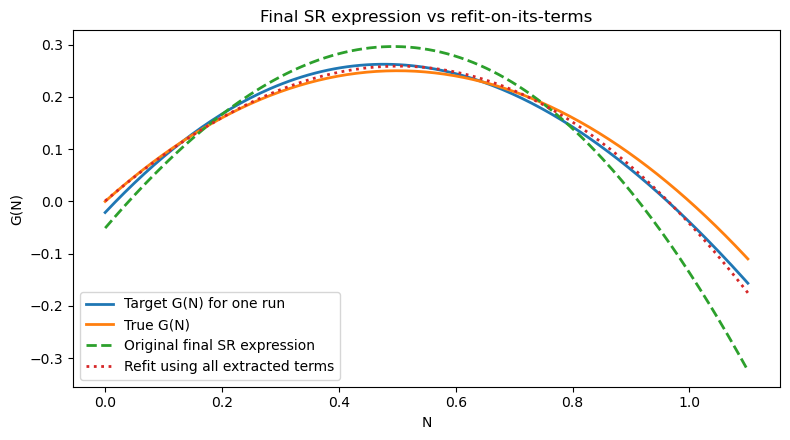

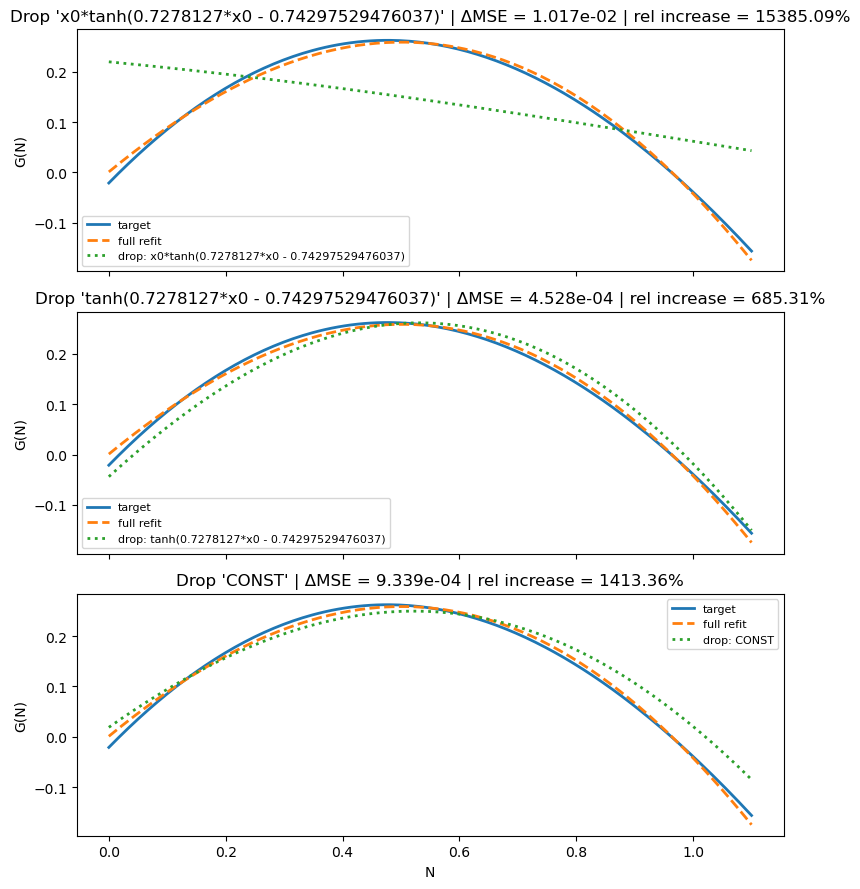

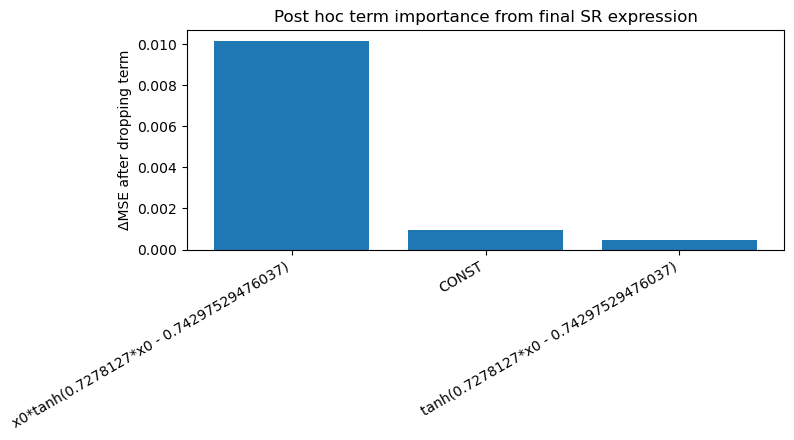


REDUCED MODEL USING IMPORTANT TERMS ONLY
Kept terms:
x0*tanh(0.7278127*x0 - 0.74297529476037)           -1.38770501
metrics: {'mse': 0.0010446190256926053, 'rmse': 0.03232056660537691, 'r2': 0.9192966589015968}

Reduced expression:
-1.38770501323258*x0*tanh(0.7278127*x0 - 0.74297529476037)


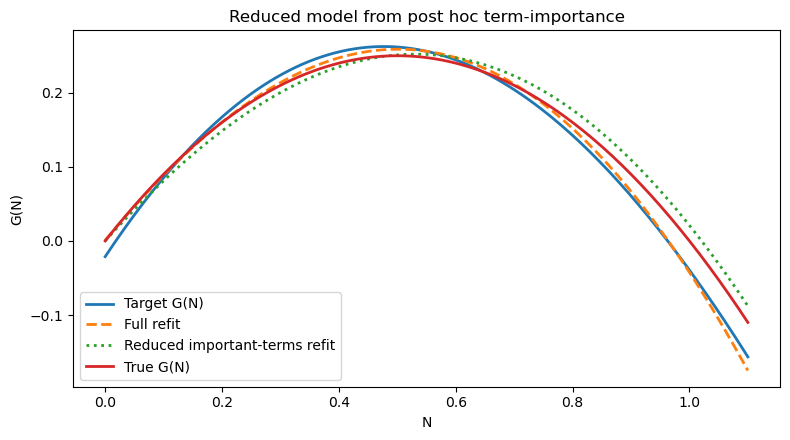


SUMMARY
Original SR expression:
-2.20616117278116*(x0 + 0.08743078)*tanh(0.7278127*x0 - 0.74297529476037) - 0.17275558

Expanded SR expression:
-2.20616117278116*x0*tanh(0.7278127*x0 - 0.74297529476037) - 0.192886392141972*tanh(0.7278127*x0 - 0.74297529476037) - 0.17275558

Full refit expression:
-1.58800927352445*x0*tanh(0.7278127*x0 - 0.74297529476037) - 0.109329600350191*tanh(0.7278127*x0 - 0.74297529476037) - 0.0680986152004929

Reduced important-terms expression:
-1.38770501323258*x0*tanh(0.7278127*x0 - 0.74297529476037)

Term-importance table:
                            dropped_term  delta_mse  relative_mse_increase  mse_without_term  r2_without_term
x0*tanh(0.7278127*x0 - 0.74297529476037)   0.010166             153.850889          0.010232         0.209543
                                   CONST   0.000934              14.133577          0.001000         0.922749
   tanh(0.7278127*x0 - 0.74297529476037)   0.000453               6.853081          0.000519         0.959913


In [31]:
# ============================================================
# Post hoc term-importance analysis for ONE final SR expression
#
# What this does:
#   1. Parse one final SR expression
#   2. Expand it into additive terms
#   3. Turn each additive term into a basis function
#      (numeric coefficient stripped off)
#   4. Refit coefficients for the FULL basis on your target G(N)
#   5. Drop one term at a time
#   6. Refit remaining coefficients
#   7. Measure how much MSE increases
#
# Assumes these already exist from your notebook:
#   N_grid
#   rhs_histories   OR   rhs_mean
#   G_grid_true     (optional, only for plotting)
#
# One-run use:
#   target_y = rhs_histories[0]
#
# If you instead want the mean learned G(N), replace:
#   target_y = rhs_histories[0]
# with:
#   target_y = rhs_mean
# ============================================================

import numpy as np
import sympy as sp
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. Choose the final SR expression and the target curve
# ============================================================
sr_expr_str = "(x0 - 1*(-0.08743078))*tanh((1.0208331 - x0)*0.7278127)/0.45327604 - 1*0.17275558"

# One-run target:
X = N_grid.cpu().numpy().reshape(-1, 1)[:, 0]     # shape (n,)
target_y = np.asarray(rhs_histories[0]).reshape(-1)  # one learned G(N) curve

# Optional true curve for plotting if available:
try:
    true_y = G_grid_true.cpu().numpy().reshape(-1)
except Exception:
    true_y = None

# ============================================================
# 2. Parse and expand the SR expression into additive terms
# ============================================================
x0 = sp.Symbol("x0")
expr = sp.sympify(sr_expr_str)
expr_expanded = sp.expand(expr)

print("Original SR expression:")
print(expr)
print("\nExpanded SR expression:")
print(expr_expanded)

def extract_basis_terms_from_expression(expr):
    """
    Expand expression and extract additive terms.
    For each term:
      term = coeff * basis
    store:
      - original_term
      - coeff_from_sr
      - basis_expr    (numeric coefficient stripped)
      - basis_name
    """
    expr = sp.expand(expr)
    terms = expr.as_ordered_terms()

    basis_records = []
    for term in terms:
        coeff, rest = term.as_coeff_Mul()

        # constant term
        if rest == 1:
            basis_expr = sp.Integer(1)
            basis_name = "CONST"
        else:
            basis_expr = sp.simplify(rest)
            basis_name = sp.sstr(basis_expr)

        basis_records.append({
            "original_term": term,
            "coeff_from_sr": float(coeff),
            "basis_expr": basis_expr,
            "basis_name": basis_name,
        })

    return basis_records

basis_records = extract_basis_terms_from_expression(expr_expanded)

print("\nExtracted additive terms from SR expression:")
for i, rec in enumerate(basis_records):
    print(
        f"[{i}] original_term = {rec['original_term']}\n"
        f"    coeff_from_sr = {rec['coeff_from_sr']:+.6f}\n"
        f"    basis_name    = {rec['basis_name']}\n"
    )

# ============================================================
# 3. Build design matrix from extracted basis terms
# ============================================================
def eval_basis_expr_on_x(basis_expr, x_values):
    """
    Evaluate SymPy basis expression on numpy array x_values.
    Broadcast scalars to full length.
    """
    f = sp.lambdify(x0, basis_expr, "numpy")
    vals = f(x_values)
    vals = np.asarray(vals, dtype=float)

    if vals.ndim == 0:
        vals = np.full(len(x_values), float(vals))
    elif vals.shape == (1,):
        vals = np.full(len(x_values), float(vals[0]))
    else:
        vals = vals.reshape(-1)

    if len(vals) != len(x_values):
        raise ValueError(
            f"Basis expression {basis_expr} evaluated to length {len(vals)}, "
            f"expected {len(x_values)}."
        )
    return vals

def build_design_matrix(x_values, basis_records):
    cols = []
    basis_exprs = []
    basis_names = []

    for rec in basis_records:
        vals = eval_basis_expr_on_x(rec["basis_expr"], x_values)
        cols.append(vals)
        basis_exprs.append(rec["basis_expr"])
        basis_names.append(rec["basis_name"])

    A = np.column_stack(cols)
    return A, basis_exprs, basis_names

A_full, basis_exprs_full, basis_names_full = build_design_matrix(X, basis_records)

# Optional: drop duplicate columns if SR expansion produced duplicate basis terms
def deduplicate_columns(A, basis_exprs, basis_names):
    keep_idx = []
    kept_cols = []

    for j in range(A.shape[1]):
        col = A[:, j]
        is_duplicate = any(np.allclose(col, prev_col) for prev_col in kept_cols)
        if not is_duplicate:
            keep_idx.append(j)
            kept_cols.append(col)

    A_new = A[:, keep_idx]
    basis_exprs_new = [basis_exprs[j] for j in keep_idx]
    basis_names_new = [basis_names[j] for j in keep_idx]
    return A_new, basis_exprs_new, basis_names_new, keep_idx

A_full, basis_exprs_full, basis_names_full, keep_idx = deduplicate_columns(
    A_full, basis_exprs_full, basis_names_full
)

print("\nBasis functions used for refit:")
for j, name in enumerate(basis_names_full):
    print(f"[{j}] {name}")

# ============================================================
# 4. Refit the FULL structured model
# ============================================================
def fit_linear_model(A, y):
    coeffs, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
    yhat = A @ coeffs

    mse = np.mean((y - yhat) ** 2)
    rmse = np.sqrt(mse)
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return coeffs, yhat, {
        "mse": mse,
        "rmse": rmse,
        "r2": r2,
    }

full_coeffs, yhat_full, full_metrics = fit_linear_model(A_full, target_y)

print("\n============================================================")
print("FULL REFIT USING ALL TERMS FROM FINAL SR EXPRESSION")
print("============================================================")
for name, c in zip(basis_names_full, full_coeffs):
    print(f"{name:50s} {c:+.8f}")
print("metrics:", full_metrics)

# Reconstruct full refit expression
refit_expr_full = 0
for c, basis_expr in zip(full_coeffs, basis_exprs_full):
    refit_expr_full += float(c) * basis_expr
refit_expr_full = sp.expand(refit_expr_full)

print("\nRefit full expression:")
print(refit_expr_full)

# ============================================================
# 5. Leave-one-term-out importance:
#    drop one term, refit remaining coefficients, compare MSE
# ============================================================
ablation_rows = []
ablation_predictions = {}

for drop_j, dropped_name in enumerate(basis_names_full):
    keep_cols = [j for j in range(len(basis_names_full)) if j != drop_j]

    A_drop = A_full[:, keep_cols]
    kept_basis_names = [basis_names_full[j] for j in keep_cols]
    kept_basis_exprs = [basis_exprs_full[j] for j in keep_cols]

    coeffs_drop, yhat_drop, metrics_drop = fit_linear_model(A_drop, target_y)

    delta_mse = metrics_drop["mse"] - full_metrics["mse"]
    relative_increase = delta_mse / full_metrics["mse"] if full_metrics["mse"] > 0 else np.nan

    expr_drop = 0
    for c, basis_expr in zip(coeffs_drop, kept_basis_exprs):
        expr_drop += float(c) * basis_expr
    expr_drop = sp.expand(expr_drop)

    ablation_rows.append({
        "dropped_term": dropped_name,
        "mse_without_term": metrics_drop["mse"],
        "rmse_without_term": metrics_drop["rmse"],
        "r2_without_term": metrics_drop["r2"],
        "delta_mse": delta_mse,
        "relative_mse_increase": relative_increase,
        "kept_terms": kept_basis_names,
        "expr_without_term": expr_drop,
        "coeffs_without_term": coeffs_drop,
    })

    ablation_predictions[dropped_name] = yhat_drop

ablation_df = pd.DataFrame(ablation_rows).sort_values(
    "delta_mse", ascending=False
).reset_index(drop=True)

print("\n============================================================")
print("LEAVE-ONE-TERM-OUT IMPORTANCE")
print("Bigger delta_mse means the dropped term mattered more.")
print("============================================================")
print(
    ablation_df[
        ["dropped_term", "mse_without_term", "delta_mse", "relative_mse_increase", "r2_without_term"]
    ].to_string(index=False)
)

# ============================================================
# 6. Compare original SR expression prediction vs refit prediction
# ============================================================
def eval_sympy_expr(expr, x_values):
    f = sp.lambdify(x0, expr, "numpy")
    vals = f(x_values)
    vals = np.asarray(vals, dtype=float)
    if vals.ndim == 0:
        vals = np.full(len(x_values), float(vals))
    elif vals.shape == (1,):
        vals = np.full(len(x_values), float(vals[0]))
    else:
        vals = vals.reshape(-1)
    return vals

yhat_original_sr = eval_sympy_expr(expr, X)

orig_mse = np.mean((target_y - yhat_original_sr) ** 2)
refit_mse = np.mean((target_y - yhat_full) ** 2)

print("\nOriginal SR-expression MSE on target:", orig_mse)
print("Refit-full-expression MSE on target:", refit_mse)

# ============================================================
# 7. Plot target, original SR, and full refit
# ============================================================
plt.figure(figsize=(8, 4.5))
plt.plot(X, target_y, label="Target G(N) for one run", linewidth=2)
if true_y is not None:
    plt.plot(X, true_y, label="True G(N)", linewidth=2)
plt.plot(X, yhat_original_sr, "--", label="Original final SR expression", linewidth=2)
plt.plot(X, yhat_full, ":", label="Refit using all extracted terms", linewidth=2)
plt.xlabel("N")
plt.ylabel("G(N)")
plt.title("Final SR expression vs refit-on-its-terms")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 8. Plot all leave-one-term-out fits
# ============================================================
n_terms = len(basis_names_full)
fig, axes = plt.subplots(n_terms, 1, figsize=(8, 3.0 * n_terms), sharex=True)

if n_terms == 1:
    axes = [axes]

for ax, row in zip(axes, ablation_rows):
    dropped_name = row["dropped_term"]
    ax.plot(X, target_y, label="target", linewidth=2)
    ax.plot(X, yhat_full, label="full refit", linewidth=2, linestyle="--")
    ax.plot(X, ablation_predictions[dropped_name], label=f"drop: {dropped_name}", linewidth=2, linestyle=":")
    ax.set_ylabel("G(N)")
    ax.set_title(
        f"Drop '{dropped_name}' | ΔMSE = {row['delta_mse']:.3e} | "
        f"rel increase = {100*row['relative_mse_increase']:.2f}%"
    )
    ax.legend(fontsize=8)

axes[-1].set_xlabel("N")
plt.tight_layout()
plt.show()

# ============================================================
# 9. Bar chart of term importance
# ============================================================
plt.figure(figsize=(8, 4.5))
plt.bar(range(len(ablation_df)), ablation_df["delta_mse"].values)
plt.xticks(range(len(ablation_df)), ablation_df["dropped_term"].values, rotation=30, ha="right")
plt.ylabel("ΔMSE after dropping term")
plt.title("Post hoc term importance from final SR expression")
plt.tight_layout()
plt.show()

# ============================================================
# 10. Optional: choose "important" terms and build reduced model
#
# Here we keep terms whose removal increases MSE by at least
# keep_threshold_frac * max_delta_mse
# ============================================================
keep_threshold_frac = 0.10  # adjust as desired

max_delta = ablation_df["delta_mse"].max()
important_terms = ablation_df.loc[
    ablation_df["delta_mse"] >= keep_threshold_frac * max_delta, "dropped_term"
].tolist()

# If nothing survives due to tiny deltas, keep the top term
if len(important_terms) == 0 and len(ablation_df) > 0:
    important_terms = [ablation_df.iloc[0]["dropped_term"]]

# Careful:
# ablation_df ranks dropped terms by importance, but for the reduced model
# we want to KEEP those important terms.
reduced_basis_names = important_terms

# Map basis name -> basis expr
basis_expr_map = dict(zip(basis_names_full, basis_exprs_full))
reduced_basis_exprs = [basis_expr_map[name] for name in reduced_basis_names]

A_reduced = np.column_stack([
    eval_basis_expr_on_x(basis_expr_map[name], X) for name in reduced_basis_names
])

reduced_coeffs, yhat_reduced, reduced_metrics = fit_linear_model(A_reduced, target_y)

reduced_expr = 0
for c, basis_expr in zip(reduced_coeffs, reduced_basis_exprs):
    reduced_expr += float(c) * basis_expr
reduced_expr = sp.expand(reduced_expr)

print("\n============================================================")
print("REDUCED MODEL USING IMPORTANT TERMS ONLY")
print("============================================================")
print("Kept terms:")
for name, c in zip(reduced_basis_names, reduced_coeffs):
    print(f"{name:50s} {c:+.8f}")
print("metrics:", reduced_metrics)
print("\nReduced expression:")
print(reduced_expr)

plt.figure(figsize=(8, 4.5))
plt.plot(X, target_y, label="Target G(N)", linewidth=2)
plt.plot(X, yhat_full, label="Full refit", linewidth=2, linestyle="--")
plt.plot(X, yhat_reduced, label="Reduced important-terms refit", linewidth=2, linestyle=":")
if true_y is not None:
    plt.plot(X, true_y, label="True G(N)", linewidth=2)
plt.xlabel("N")
plt.ylabel("G(N)")
plt.title("Reduced model from post hoc term-importance")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 11. Summary
# ============================================================
print("\n============================================================")
print("SUMMARY")
print("============================================================")
print("Original SR expression:")
print(expr)
print("\nExpanded SR expression:")
print(expr_expanded)
print("\nFull refit expression:")
print(refit_expr_full)
print("\nReduced important-terms expression:")
print(reduced_expr)
print("\nTerm-importance table:")
print(
    ablation_df[
        ["dropped_term", "delta_mse", "relative_mse_increase", "mse_without_term", "r2_without_term"]
    ].to_string(index=False)
)


Starting PINN split 1/1
Dynamics init seed for split 1: 10000
Solution init seeds for split 1: [20000, 20001, 20002, 20003, 20004, 20005, 20006]
PINN | Split  1/1 | Epoch     1/4000 | Train Total: 4.861829e-01 | Train Data: 4.841432e-01 | Train Phys: 2.039661e-03 | Train Anchor: 8.872060e-03 | Val Total: 3.474347e-01 | Val Data: 3.452817e-01 | Val Phys: 2.153063e-03
PINN | Split  1/1 | Epoch   500/4000 | Train Total: 2.824935e-03 | Train Data: 2.583850e-03 | Train Phys: 2.410851e-04 | Train Anchor: 3.328049e-05 | Val Total: 1.528264e-03 | Val Data: 1.291253e-03 | Val Phys: 2.370117e-04
PINN | Split  1/1 | Epoch  1000/4000 | Train Total: 2.635385e-03 | Train Data: 2.509299e-03 | Train Phys: 1.260867e-04 | Train Anchor: 3.358719e-06 | Val Total: 1.314998e-03 | Val Data: 1.169566e-03 | Val Phys: 1.454315e-04
PINN | Split  1/1 | Epoch  1500/4000 | Train Total: 2.619131e-03 | Train Data: 2.485648e-03 | Train Phys: 1.334839e-04 | Train Anchor: 4.072482e-06 | Val Total: 1.261751e-03 | Val Da

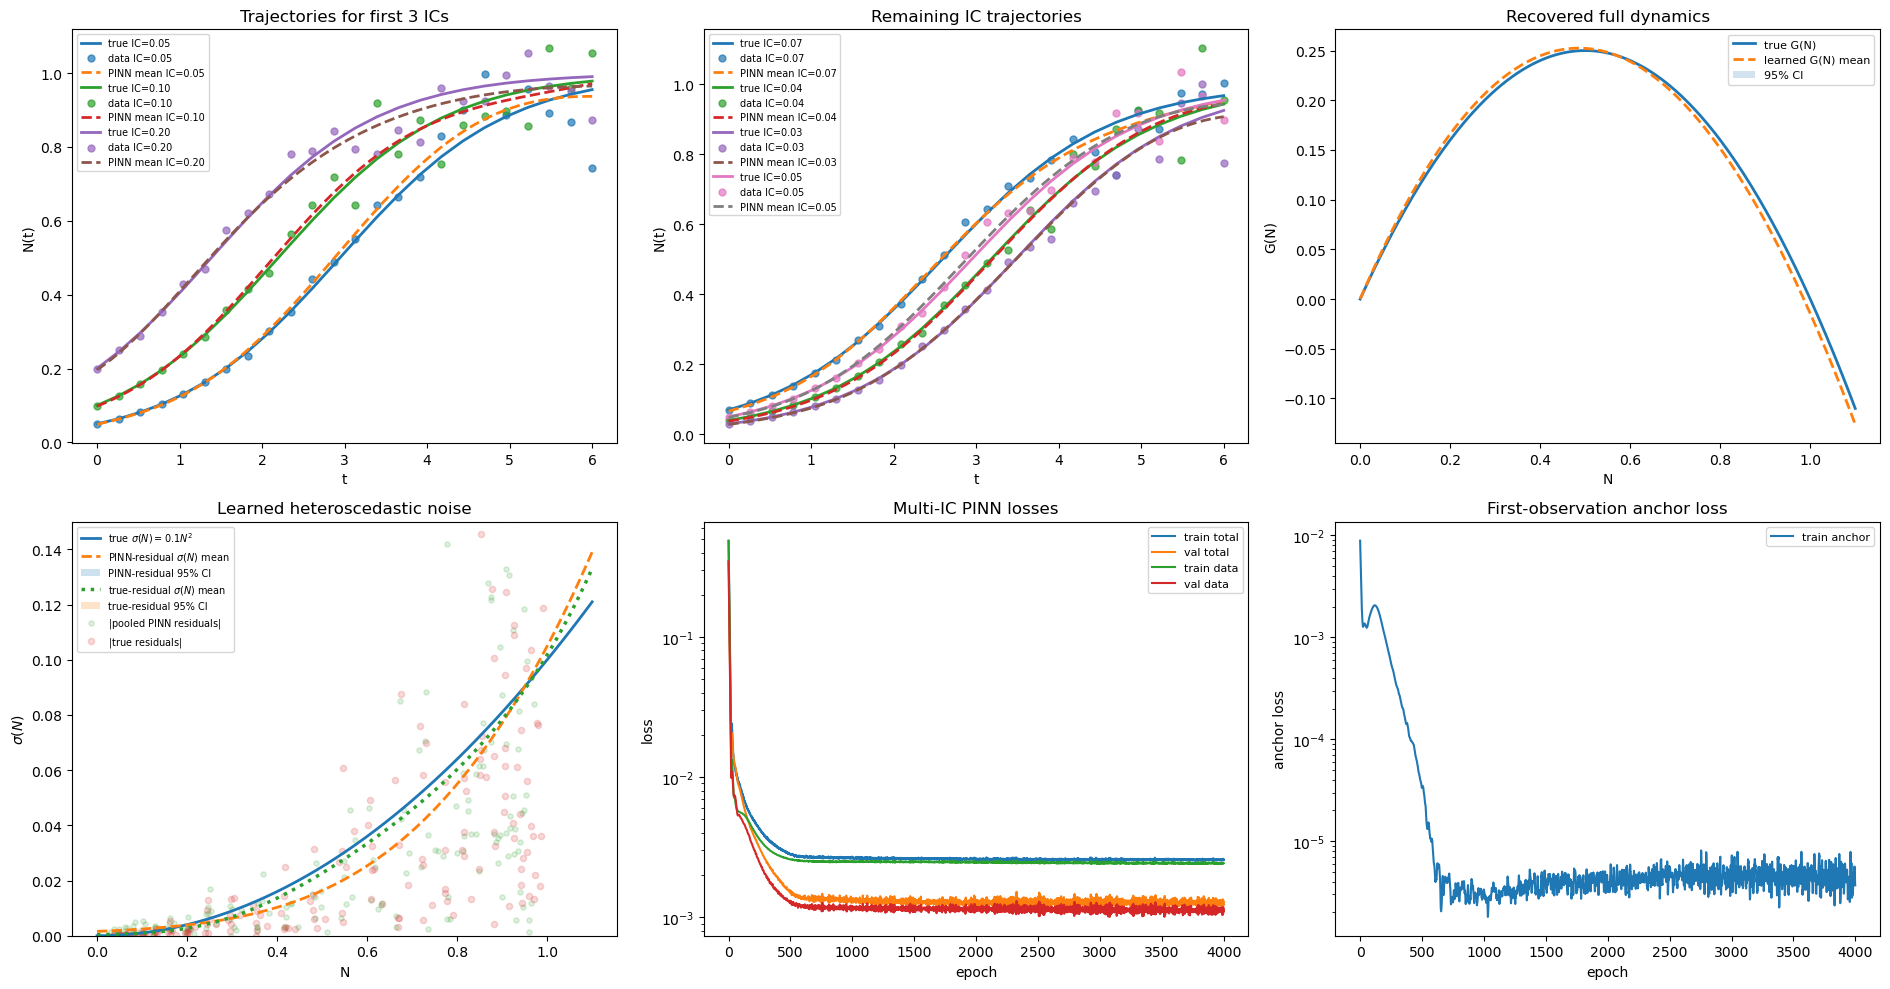

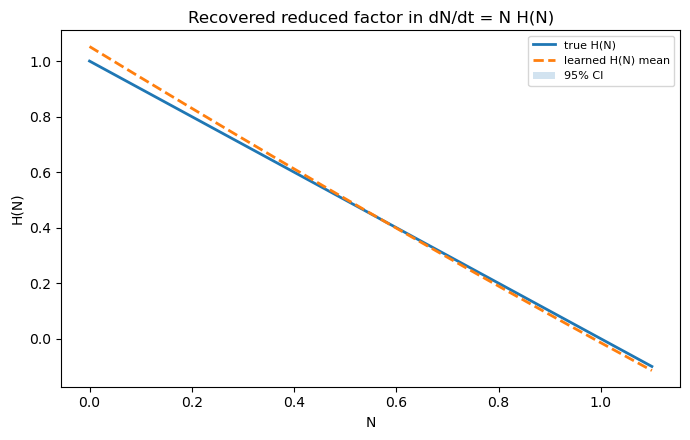

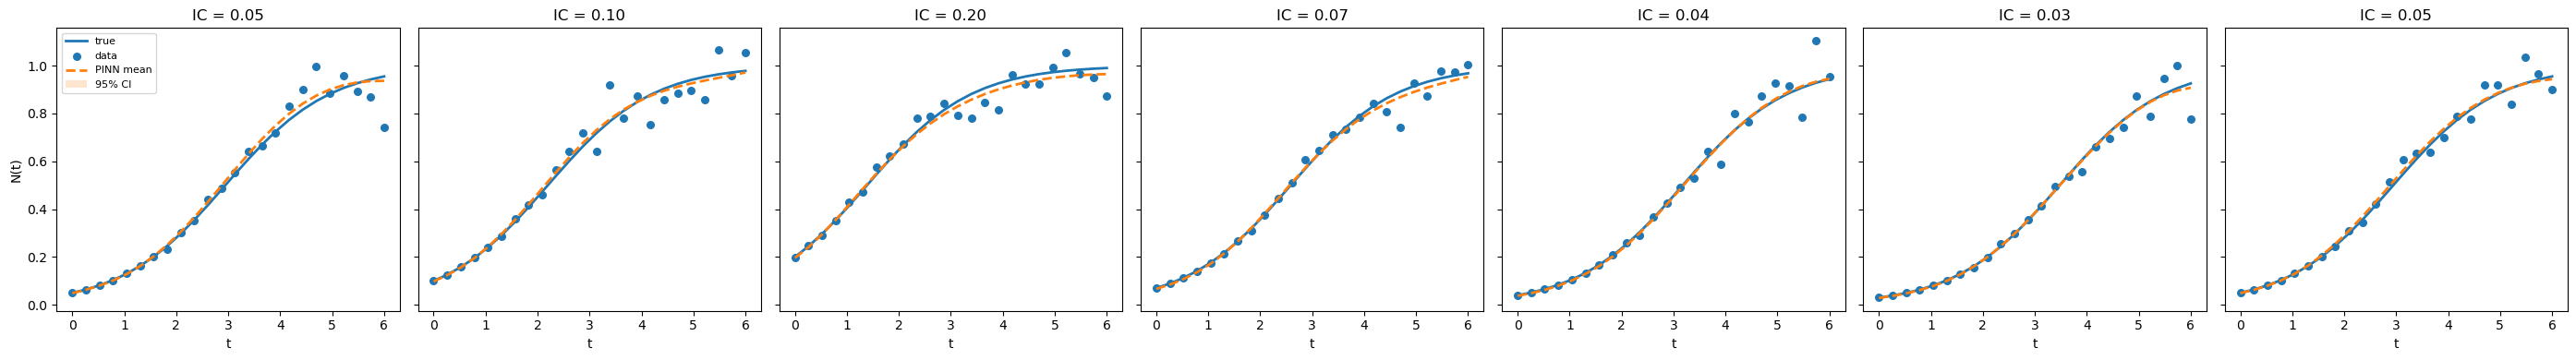

/var/folders/dn/jj6zl9nx6s541bq88x9x4zvm0000gn/T/ipykernel_84790/3950408055.py:1110: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axes[0].set_yscale("log")


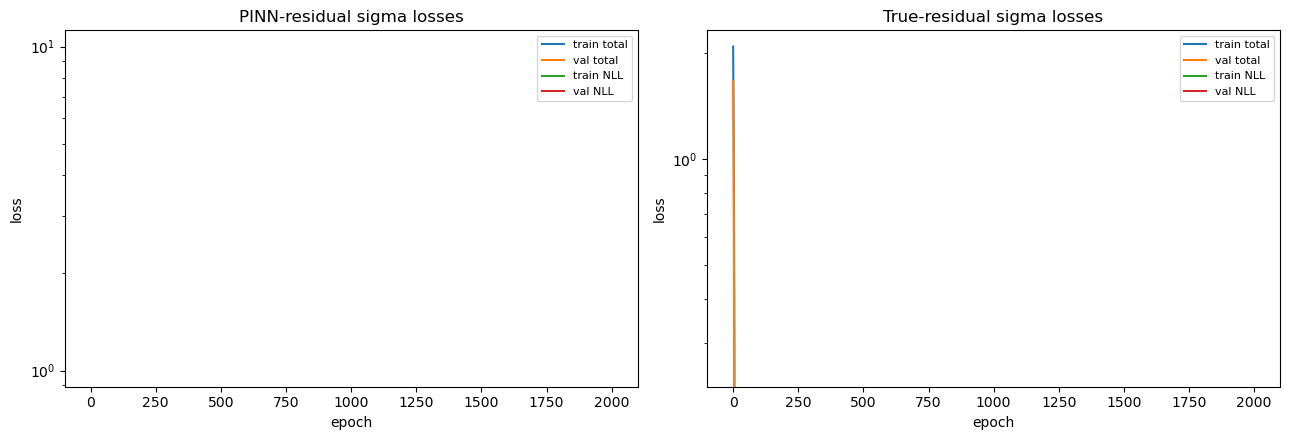


Multi-IC PINN summary
---------------------
Number of trajectories / ICs: 7
Synthetic IC values used to generate data: [0.05, 0.1, 0.2, 0.07, 0.04, 0.03, 0.05]
Number of PINN splits: 1
Validation fraction: 0.2
Model-selection criterion: validation loss
Mean best selection loss: 1.116556e-03
Std  best selection loss: N/A (only one split)
Mean best epoch: 2512.00
Std  best epoch: N/A (only one split)
Anchor weight lambda_anchor: 0.000
Dynamics model assumption: dN/dt = N * H(N), with dyn_net learning H(N)

Initialization summary by split
-------------------------------
Split 1: dyn_init_seed=10000, sol_init_seeds=[20000, 20001, 20002, 20003, 20004, 20005, 20006], selection_criterion=val

PINN-residual sigma summary
---------------------------
Number of sigma repeats: 1
Mean best selection loss: -6.717906e+00
Std  best selection loss: N/A (only one repeat)
Mean best epoch: 1999.00
Std  best epoch: N/A (only one repeat)

True-residual sigma summary
---------------------------
Number of si

In [36]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = N * H(N)
#    with H(N) = r (1 - N)
# ============================================================
r_true = 1.0
N0_list = [0.05, 0.10, 0.20, 0.07, 0.04, 0.03, 0.05]
n_ics = len(N0_list)

numpts = 4 * (24 // 4)
t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)
t_plot = torch.linspace(0.0, 6.0, 200, device=device).view(-1, 1)
N_grid = torch.linspace(0.0, 1.1, 200, device=device).view(-1, 1)


def H_true(N):
    return r_true * (1.0 - N)


def G_true(N):
    return N * H_true(N)


# ============================================================
# 2. Generate synthetic observed data
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)


y_true_list = []
y_data_list = []

with torch.no_grad():
    for N0 in N0_list:
        y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
        y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)
        y_data = y_true + 0.1 * torch.randn_like(y_true) * y_true**2

        y_true_list.append(y_true)
        y_data_list.append(y_data)

y_true_all = torch.stack(y_true_list, dim=0)   # [n_ics, numpts, 1]
y_data_all = torch.stack(y_data_list, dim=0)   # [n_ics, numpts, 1]

with torch.no_grad():
    G_grid_true = G_true(N_grid)
    H_grid_true = H_true(N_grid)
    sigma_true_grid = 0.1 * N_grid**2


# ============================================================
# 3. Model classes
# ============================================================
def init_weights_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        nn.init.zeros_(m.bias)


class SolutionNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        self.apply(init_weights_xavier)

    def forward(self, t):
        return self.net(t)


class DynamicsNet(nn.Module):
    """
    Learns H(N) in dN/dt = N * H(N)
    """
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        self.apply(init_weights_xavier)

    def forward(self, N):
        return self.net(N)


class SigmaNet(nn.Module):
    def __init__(self, hidden_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
            nn.Softplus(),
        )

    def forward(self, N):
        return self.net(N) + 1e-4


# ============================================================
# 4. Helper functions
# ============================================================
def mean_and_ci(arr, ci=1.96):
    arr = np.array(arr)
    mean = arr.mean(axis=0)
    if arr.shape[0] == 1:
        lo = mean.copy()
        hi = mean.copy()
    else:
        sem = arr.std(axis=0, ddof=1) / np.sqrt(arr.shape[0])
        lo = mean - ci * sem
        hi = mean + ci * sem
    return mean, lo, hi


def pinn_physics_residual(sol_net, dyn_net, t_col):
    """
    Physics model:
        dN/dt = N * H(N)
    where dyn_net(N) approximates H(N).
    """
    N_pred_col = sol_net(t_col)
    dN_dt = torch.autograd.grad(
        outputs=N_pred_col,
        inputs=t_col,
        grad_outputs=torch.ones_like(N_pred_col),
        create_graph=True,
        retain_graph=True,
    )[0]
    h_pred = dyn_net(N_pred_col)
    rhs_pred = N_pred_col * h_pred
    phys_res = dN_dt - rhs_pred
    return N_pred_col, dN_dt, h_pred, rhs_pred, phys_res


def gaussian_sigma_nll(resid, sigma):
    sigma2 = sigma ** 2
    return torch.mean(torch.log(sigma2) + (resid ** 2) / sigma2)


def sigma_monotonicity_loss(model, N_col):
    N_req = N_col.clone().detach().requires_grad_(True)
    sigma_col = model(N_req)
    dsigma_dN = torch.autograd.grad(
        outputs=sigma_col,
        inputs=N_req,
        grad_outputs=torch.ones_like(sigma_col),
        create_graph=True,
        retain_graph=True,
    )[0]
    return torch.sum(torch.relu(-dsigma_dN) ** 2)


def fit_sigma_repeated(
    N_all,
    resid_all,
    N_eval_grid,
    N_col_base,
    n_repeats=1,
    val_fraction=0.2,
    n_epochs=3000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="sigma",
    print_every=500,
):
    n_samples = N_all.shape[0]
    use_validation = val_fraction > 0.0 and n_samples > 1

    if use_validation:
        n_val = int(round(val_fraction * n_samples))
        n_val = max(1, min(n_val, n_samples - 1))
    else:
        n_val = 0
    n_train = n_samples - n_val

    train_total_histories = []
    train_nll_histories = []
    train_mon_histories = []

    val_total_histories = []
    val_nll_histories = []
    val_mon_histories = []

    curve_histories = []
    best_val_losses = []
    best_epochs = []
    best_models = []

    for repeat in range(n_repeats):
        print(f"\n{'-' * 90}")
        print(f"Starting {label} repeat {repeat + 1}/{n_repeats}")
        print(f"{'-' * 90}")

        g = torch.Generator(device=device)
        g.manual_seed(seed_offset_split + repeat)

        perm = torch.randperm(n_samples, generator=g, device=device)
        train_idx = perm[:n_train].sort().values

        if use_validation:
            val_idx = perm[n_train:].sort().values
        else:
            val_idx = torch.empty(0, dtype=torch.long, device=device)

        N_train = N_all[train_idx]
        r_train = resid_all[train_idx]

        if use_validation:
            N_val = N_all[val_idx]
            r_val = resid_all[val_idx]

        torch.manual_seed(seed_offset_model + repeat)
        np.random.seed(seed_offset_model + repeat)

        sigma_net = SigmaNet(hidden_dim=hidden_dim).to(device)
        opt = torch.optim.Adam(sigma_net.parameters(), lr=lr)

        train_total_history = []
        train_nll_history = []
        train_mon_history = []

        val_total_history = []
        val_nll_history = []
        val_mon_history = []

        best_criterion = float("inf")
        best_epoch = -1
        best_state = None

        for epoch in range(n_epochs):
            opt.zero_grad()

            sigma_pred_train = sigma_net(N_train)
            train_nll = gaussian_sigma_nll(r_train, sigma_pred_train)
            train_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
            reg = lambda_reg * sum((p ** 2).sum() for p in sigma_net.parameters())

            train_total = train_nll + lambda_mon * train_mon + reg
            train_total.backward()
            opt.step()

            if use_validation:
                with torch.no_grad():
                    sigma_pred_val = sigma_net(N_val)
                    val_nll = gaussian_sigma_nll(r_val, sigma_pred_val)

                val_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
                val_total = val_nll + lambda_mon * val_mon

                criterion_value = val_total.item()
                val_total_item = val_total.item()
                val_nll_item = val_nll.item()
                val_mon_item = val_mon.item()
                criterion_name = "val"
            else:
                criterion_value = train_total.item()
                val_total_item = np.nan
                val_nll_item = np.nan
                val_mon_item = np.nan
                criterion_name = "train"

            train_total_history.append(train_total.item())
            train_nll_history.append(train_nll.item())
            train_mon_history.append(train_mon.item())

            val_total_history.append(val_total_item)
            val_nll_history.append(val_nll_item)
            val_mon_history.append(val_mon_item)

            if (epoch == 0) or ((epoch + 1) % print_every == 0) or (epoch == n_epochs - 1):
                if use_validation:
                    print(
                        f"{label} | Repeat {repeat + 1:2d}/{n_repeats} | "
                        f"Epoch {epoch + 1:5d}/{n_epochs} | "
                        f"Train Total: {train_total.item():.6e} | "
                        f"Train NLL: {train_nll.item():.6e} | "
                        f"Train Mon: {train_mon.item():.6e} | "
                        f"Val Total: {val_total_item:.6e} | "
                        f"Val NLL: {val_nll_item:.6e} | "
                        f"Val Mon: {val_mon_item:.6e}"
                    )
                else:
                    print(
                        f"{label} | Repeat {repeat + 1:2d}/{n_repeats} | "
                        f"Epoch {epoch + 1:5d}/{n_epochs} | "
                        f"Train Total: {train_total.item():.6e} | "
                        f"Train NLL: {train_nll.item():.6e} | "
                        f"Train Mon: {train_mon.item():.6e} | "
                        f"Val Total: N/A | Val NLL: N/A | Val Mon: N/A | "
                        f"Best-model criterion: training loss"
                    )

            if criterion_value < best_criterion:
                best_criterion = criterion_value
                best_epoch = epoch
                best_state = copy.deepcopy(sigma_net.state_dict())

        sigma_net.load_state_dict(best_state)
        sigma_net.eval()

        with torch.no_grad():
            sigma_curve = sigma_net(N_eval_grid).squeeze(1).cpu().numpy()

        best_models.append(copy.deepcopy(sigma_net))
        train_total_histories.append(train_total_history)
        train_nll_histories.append(train_nll_history)
        train_mon_histories.append(train_mon_history)

        val_total_histories.append(val_total_history)
        val_nll_histories.append(val_nll_history)
        val_mon_histories.append(val_mon_history)

        curve_histories.append(sigma_curve)
        best_val_losses.append(best_criterion)
        best_epochs.append(best_epoch)

        if use_validation:
            print(
                f"Finished {label} repeat {repeat + 1:2d}/{n_repeats} | "
                f"Best epoch = {best_epoch:5d} | Best val loss = {best_criterion:.6e}"
            )
        else:
            print(
                f"Finished {label} repeat {repeat + 1:2d}/{n_repeats} | "
                f"Best epoch = {best_epoch:5d} | Best train loss = {best_criterion:.6e}"
            )

    return {
        "train_total_histories": np.array(train_total_histories),
        "train_nll_histories": np.array(train_nll_histories),
        "train_mon_histories": np.array(train_mon_histories),
        "val_total_histories": np.array(val_total_histories),
        "val_nll_histories": np.array(val_nll_histories),
        "val_mon_histories": np.array(val_mon_histories),
        "curve_histories": np.array(curve_histories),
        "best_val_losses": np.array(best_val_losses),
        "best_epochs": np.array(best_epochs),
        "best_models": best_models,
    }


# ============================================================
# 5. Multi-IC PINN fit
# ============================================================
n_col = 1000
t_col_base = torch.linspace(0.0, 6.0, n_col, device=device).view(-1, 1)

n_epochs = 4000
n_splits = 1
print_every = 500
batch_obs = 24 * 4 * n_ics
batch_col = 100

val_fraction = 0.2
n_obs = t_obs.shape[0]
use_validation = val_fraction > 0.0 and n_obs > 1

if use_validation:
    n_val = int(round(val_fraction * n_obs))
    n_val = max(1, min(n_val, n_obs - 1))
else:
    n_val = 0
n_train = n_obs - n_val

lambda_phys = 1.0
lambda_anchor = 0.0
learning_rate = 1e-3
hidden_dim_sol = 32
hidden_dim_dyn = 32

data_split_seed_base = 1000
dyn_init_seed_base = 10000
sol_init_seed_base = 20000

train_total_histories = []
train_data_histories = []
train_phys_histories = []
train_anchor_histories = []

val_total_histories = []
val_data_histories = []
val_phys_histories = []

traj_histories = []
rhs_histories = []   # stores learned full G(N) = N * H(N)
h_histories = []     # stores learned reduced factor H(N)
obs_fit_histories = []

best_val_losses = []
best_epochs = []
best_states = []

for split in range(n_splits):
    print(f"\n{'=' * 90}")
    print(f"Starting PINN split {split + 1}/{n_splits}")
    print(f"{'=' * 90}")

    g = torch.Generator(device=device)
    g.manual_seed(data_split_seed_base + split)

    perm = torch.randperm(n_obs, generator=g, device=device)
    train_idx = perm[:n_train].sort().values

    if use_validation:
        val_idx = perm[n_train:].sort().values
    else:
        val_idx = torch.empty(0, dtype=torch.long, device=device)

    torch.manual_seed(dyn_init_seed_base + split)
    np.random.seed(dyn_init_seed_base + split)
    dyn_net = DynamicsNet(hidden_dim=hidden_dim_dyn).to(device)

    sol_net_list = []
    sol_init_seeds_this_split = []
    for i in range(n_ics):
        init_seed = sol_init_seed_base + 1000 * split + i
        sol_init_seeds_this_split.append(init_seed)
        torch.manual_seed(init_seed)
        np.random.seed(init_seed)
        sol_net_list.append(SolutionNet(hidden_dim=hidden_dim_sol).to(device))

    sol_nets = nn.ModuleList(sol_net_list)

    print(f"Dynamics init seed for split {split + 1}: {dyn_init_seed_base + split}")
    print(f"Solution init seeds for split {split + 1}: {sol_init_seeds_this_split}")

    optimizer = torch.optim.Adam(
        list(dyn_net.parameters()) + list(sol_nets.parameters()),
        lr=learning_rate,
    )

    train_total_history = []
    train_data_history = []
    train_phys_history = []
    train_anchor_history = []

    val_total_history = []
    val_data_history = []
    val_phys_history = []

    best_criterion = float("inf")
    best_epoch = -1
    best_state = None

    for epoch in range(n_epochs):
        optimizer.zero_grad()

        total_data_loss = 0.0
        total_phys_loss = 0.0
        total_anchor_loss = 0.0

        for i in range(n_ics):
            sol_net = sol_nets[i]

            obs_sel = train_idx[torch.randperm(len(train_idx), device=device)[:batch_obs]]
            t_train = t_obs[obs_sel]
            y_train = y_data_all[i][obs_sel]

            N_pred_train = sol_net(t_train)
            data_loss = torch.mean((N_pred_train - y_train) ** 2)

            t_col = 6.0 * torch.rand(batch_col, 1, device=device)
            t_col.requires_grad_(True)
            _, _, _, _, phys_res = pinn_physics_residual(sol_net, dyn_net, t_col)
            phys_loss = torch.mean(phys_res ** 2)

            t0_obs = t_obs[0:1]
            y0_obs = y_data_all[i][0:1]
            N0_pred = sol_net(t0_obs)
            anchor_loss = torch.mean((N0_pred - y0_obs) ** 2)

            total_data_loss += data_loss
            total_phys_loss += phys_loss
            total_anchor_loss += anchor_loss

        total_data_loss /= n_ics
        total_phys_loss /= n_ics
        total_anchor_loss /= n_ics

        train_loss = total_data_loss + lambda_phys * total_phys_loss + lambda_anchor * total_anchor_loss
        train_loss.backward()
        optimizer.step()

        if use_validation:
            with torch.no_grad():
                total_val_data_loss = 0.0
                for i in range(n_ics):
                    sol_net = sol_nets[i]
                    t_val = t_obs[val_idx]
                    y_val = y_data_all[i][val_idx]
                    N_pred_val = sol_net(t_val)
                    total_val_data_loss = total_val_data_loss + torch.mean((N_pred_val - y_val) ** 2)

                total_val_data_loss = total_val_data_loss / n_ics

            total_val_phys_loss = 0.0
            for i in range(n_ics):
                sol_net = sol_nets[i]
                t_col_val = t_col_base.clone().detach().requires_grad_(True)
                _, _, _, _, val_phys_res = pinn_physics_residual(sol_net, dyn_net, t_col_val)
                total_val_phys_loss = total_val_phys_loss + torch.mean(val_phys_res ** 2)

            total_val_phys_loss = total_val_phys_loss / n_ics
            val_loss = total_val_data_loss + lambda_phys * total_val_phys_loss

            criterion_value = val_loss.item()
            criterion_name = "val"

            val_total_item = val_loss.item()
            val_data_item = total_val_data_loss.item()
            val_phys_item = total_val_phys_loss.item()
        else:
            criterion_value = train_loss.item()
            criterion_name = "train"

            val_total_item = np.nan
            val_data_item = np.nan
            val_phys_item = np.nan

        train_total_history.append(train_loss.item())
        train_data_history.append(total_data_loss.item())
        train_phys_history.append(total_phys_loss.item())
        train_anchor_history.append(total_anchor_loss.item())

        val_total_history.append(val_total_item)
        val_data_history.append(val_data_item)
        val_phys_history.append(val_phys_item)

        if (epoch == 0) or ((epoch + 1) % print_every == 0) or (epoch == n_epochs - 1):
            if use_validation:
                print(
                    f"PINN | Split {split + 1:2d}/{n_splits} | "
                    f"Epoch {epoch + 1:5d}/{n_epochs} | "
                    f"Train Total: {train_loss.item():.6e} | "
                    f"Train Data: {total_data_loss.item():.6e} | "
                    f"Train Phys: {total_phys_loss.item():.6e} | "
                    f"Train Anchor: {total_anchor_loss.item():.6e} | "
                    f"Val Total: {val_total_item:.6e} | "
                    f"Val Data: {val_data_item:.6e} | "
                    f"Val Phys: {val_phys_item:.6e}"
                )
            else:
                print(
                    f"PINN | Split {split + 1:2d}/{n_splits} | "
                    f"Epoch {epoch + 1:5d}/{n_epochs} | "
                    f"Train Total: {train_loss.item():.6e} | "
                    f"Train Data: {total_data_loss.item():.6e} | "
                    f"Train Phys: {total_phys_loss.item():.6e} | "
                    f"Train Anchor: {total_anchor_loss.item():.6e} | "
                    f"Val Total: N/A | Val Data: N/A | Val Phys: N/A | "
                    f"Best-model criterion: training loss"
                )

        if criterion_value < best_criterion:
            best_criterion = criterion_value
            best_epoch = epoch
            best_state = {
                "dyn_net": copy.deepcopy(dyn_net.state_dict()),
                "sol_nets": [copy.deepcopy(sol_net.state_dict()) for sol_net in sol_nets],
                "dyn_init_seed": dyn_init_seed_base + split,
                "sol_init_seeds": sol_init_seeds_this_split.copy(),
                "train_idx": train_idx.clone(),
                "val_idx": val_idx.clone(),
                "selection_criterion": criterion_name,
            }

    if use_validation:
        print(
            f"Finished PINN split {split + 1:2d}/{n_splits} | "
            f"Best epoch = {best_epoch:5d} | Best val loss = {best_criterion:.6e}"
        )
    else:
        print(
            f"Finished PINN split {split + 1:2d}/{n_splits} | "
            f"Best epoch = {best_epoch:5d} | Best train loss = {best_criterion:.6e}"
        )

    dyn_net.load_state_dict(best_state["dyn_net"])
    for i in range(n_ics):
        sol_nets[i].load_state_dict(best_state["sol_nets"][i])

    dyn_net.eval()
    for sol_net in sol_nets:
        sol_net.eval()

    with torch.no_grad():
        trajs_this_split = []
        obs_fits_this_split = []

        for i in range(n_ics):
            trajs_this_split.append(sol_nets[i](t_plot).squeeze(1).cpu().numpy())
            obs_fits_this_split.append(sol_nets[i](t_obs).squeeze(1).cpu().numpy())

        H_grid_learned = dyn_net(N_grid).squeeze(1).cpu().numpy()
        G_grid_learned = (N_grid.squeeze(1).cpu().numpy()) * H_grid_learned

    train_total_histories.append(train_total_history)
    train_data_histories.append(train_data_history)
    train_phys_histories.append(train_phys_history)
    train_anchor_histories.append(train_anchor_history)

    val_total_histories.append(val_total_history)
    val_data_histories.append(val_data_history)
    val_phys_histories.append(val_phys_history)

    traj_histories.append(np.array(trajs_this_split))
    obs_fit_histories.append(np.array(obs_fits_this_split))
    rhs_histories.append(G_grid_learned)
    h_histories.append(H_grid_learned)

    best_val_losses.append(best_criterion)
    best_epochs.append(best_epoch)
    best_states.append(best_state)

train_total_histories = np.array(train_total_histories)
train_data_histories = np.array(train_data_histories)
train_phys_histories = np.array(train_phys_histories)
train_anchor_histories = np.array(train_anchor_histories)

val_total_histories = np.array(val_total_histories)
val_data_histories = np.array(val_data_histories)
val_phys_histories = np.array(val_phys_histories)

traj_histories = np.array(traj_histories)
obs_fit_histories = np.array(obs_fit_histories)
rhs_histories = np.array(rhs_histories)
h_histories = np.array(h_histories)

rhs_mean, rhs_lo, rhs_hi = mean_and_ci(rhs_histories)
h_mean, h_lo, h_hi = mean_and_ci(h_histories)

traj_mean_per_ic = []
traj_lo_per_ic = []
traj_hi_per_ic = []

obs_fit_mean_per_ic = []
obs_fit_lo_per_ic = []
obs_fit_hi_per_ic = []

for i in range(n_ics):
    m, lo, hi = mean_and_ci(traj_histories[:, i, :])
    traj_mean_per_ic.append(m)
    traj_lo_per_ic.append(lo)
    traj_hi_per_ic.append(hi)

    m, lo, hi = mean_and_ci(obs_fit_histories[:, i, :])
    obs_fit_mean_per_ic.append(m)
    obs_fit_lo_per_ic.append(lo)
    obs_fit_hi_per_ic.append(hi)


# ============================================================
# 6. Learn sigma(N) from pooled multi-IC PINN residuals
# ============================================================
with torch.no_grad():
    y_rep = y_data_all.squeeze(-1).cpu().numpy()[None, :, :]
    resid_pinn_all_np = y_rep - obs_fit_histories

    N_pinn_sigma_all_np = obs_fit_histories.reshape(-1, 1)
    resid_pinn_sigma_all_np = resid_pinn_all_np.reshape(-1, 1)

    mask = N_pinn_sigma_all_np.squeeze() > 0.0
    N_pinn_sigma_all_np = N_pinn_sigma_all_np[mask]
    resid_pinn_sigma_all_np = resid_pinn_sigma_all_np[mask]

N_pinn_sigma_all = torch.tensor(N_pinn_sigma_all_np, dtype=torch.float32, device=device)
resid_pinn_sigma_all = torch.tensor(resid_pinn_sigma_all_np, dtype=torch.float32, device=device)

N_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_pinn_sigma_all.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_pinn_results = fit_sigma_repeated(
    N_all=N_pinn_sigma_all,
    resid_all=resid_pinn_sigma_all,
    N_eval_grid=N_grid,
    N_col_base=N_sigma_col_base,
    n_repeats=1,
    val_fraction=0.4,
    n_epochs=2000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="PINN-sigma",
    print_every=250,
)

sigma_pinn_mean, sigma_pinn_lo, sigma_pinn_hi = mean_and_ci(
    sigma_pinn_results["curve_histories"]
)


# ============================================================
# 7. Learn sigma_truefit(N) from true residuals
# ============================================================
with torch.no_grad():
    N_true_sigma_np = y_true_all.squeeze(-1).cpu().numpy().reshape(-1, 1)
    resid_true_sigma_np = (y_data_all - y_true_all).squeeze(-1).cpu().numpy().reshape(-1, 1)

    mask_true = N_true_sigma_np.squeeze() > 0.0
    N_true_sigma_np = N_true_sigma_np[mask_true]
    resid_true_sigma_np = resid_true_sigma_np[mask_true]

N_true_sigma = torch.tensor(N_true_sigma_np, dtype=torch.float32, device=device)
resid_true_sigma = torch.tensor(resid_true_sigma_np, dtype=torch.float32, device=device)

N_true_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_true_sigma.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_truefit_results = fit_sigma_repeated(
    N_all=N_true_sigma,
    resid_all=resid_true_sigma,
    N_eval_grid=N_grid,
    N_col_base=N_true_sigma_col_base,
    n_repeats=1,
    val_fraction=0.2,
    n_epochs=2000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=9000,
    seed_offset_model=11000,
    label="TRUE-sigma",
    print_every=250,
)

sigma_truefit_mean, sigma_truefit_lo, sigma_truefit_hi = mean_and_ci(
    sigma_truefit_results["curve_histories"]
)


# ============================================================
# 8. Residuals across all ICs using mean PINN fit
# ============================================================
with torch.no_grad():
    obs_fit_mean_all = np.array(obs_fit_mean_per_ic)
    y_true_np = y_true_all.squeeze(-1).cpu().numpy()
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()

    residuals_all = y_data_np - obs_fit_mean_all
    N_fit_all = obs_fit_mean_all.reshape(-1, 1)
    residuals_flat = residuals_all.reshape(-1, 1)

    mask = N_fit_all.squeeze() > 0.0
    N_fit_all = N_fit_all[mask]
    residuals_flat = residuals_flat[mask]


# ============================================================
# 9. Plots
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(19, 10))

# ------------------------------------------------------------
# Trajectories
# ------------------------------------------------------------
for i in range(min(3, n_ics)):
    axes[0, 0].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        linewidth=2,
        label=f"true IC={N0_list[i]:.2f}",
    )
    axes[0, 0].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        s=25,
        alpha=0.7,
        label=f"data IC={N0_list[i]:.2f}",
    )
    axes[0, 0].plot(
        t_plot.cpu().numpy(),
        traj_mean_per_ic[i],
        "--",
        linewidth=2,
        label=f"PINN mean IC={N0_list[i]:.2f}",
    )
    axes[0, 0].fill_between(
        t_plot.squeeze(1).cpu().numpy(),
        traj_lo_per_ic[i],
        traj_hi_per_ic[i],
        alpha=0.18,
    )

axes[0, 0].set_xlabel("t")
axes[0, 0].set_ylabel("N(t)")
axes[0, 0].set_title("Trajectories for first 3 ICs")
axes[0, 0].legend(fontsize=7)

# ------------------------------------------------------------
# Remaining ICs
# ------------------------------------------------------------
for i in range(3, n_ics):
    axes[0, 1].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        linewidth=2,
        label=f"true IC={N0_list[i]:.2f}",
    )
    axes[0, 1].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        s=25,
        alpha=0.7,
        label=f"data IC={N0_list[i]:.2f}",
    )
    axes[0, 1].plot(
        t_plot.cpu().numpy(),
        traj_mean_per_ic[i],
        "--",
        linewidth=2,
        label=f"PINN mean IC={N0_list[i]:.2f}",
    )
    axes[0, 1].fill_between(
        t_plot.squeeze(1).cpu().numpy(),
        traj_lo_per_ic[i],
        traj_hi_per_ic[i],
        alpha=0.18,
    )

axes[0, 1].set_xlabel("t")
axes[0, 1].set_ylabel("N(t)")
axes[0, 1].set_title("Remaining IC trajectories")
axes[0, 1].legend(fontsize=7)

# ------------------------------------------------------------
# Recovered full dynamics G(N) = N * H(N)
# ------------------------------------------------------------
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    G_grid_true.squeeze(1).cpu().numpy(),
    label="true G(N)",
    linewidth=2,
)
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    rhs_mean,
    "--",
    linewidth=2,
    label="learned G(N) mean",
)
axes[0, 2].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    rhs_lo,
    rhs_hi,
    alpha=0.20,
    label="95% CI",
)
axes[0, 2].set_xlabel("N")
axes[0, 2].set_ylabel("G(N)")
axes[0, 2].set_title("Recovered full dynamics")
axes[0, 2].legend(fontsize=8)

# ------------------------------------------------------------
# Learned sigma(N)
# ------------------------------------------------------------
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_true_grid.squeeze(1).cpu().numpy(),
    linewidth=2,
    label=r"true $\sigma(N)=0.1N^2$",
)
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_pinn_mean,
    "--",
    linewidth=2,
    label=r"PINN-residual $\sigma(N)$ mean",
)
axes[1, 0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_pinn_lo,
    sigma_pinn_hi,
    alpha=0.22,
    label="PINN-residual 95% CI",
)
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_truefit_mean,
    ":",
    linewidth=2.5,
    label=r"true-residual $\sigma(N)$ mean",
)
axes[1, 0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_truefit_lo,
    sigma_truefit_hi,
    alpha=0.22,
    label="true-residual 95% CI",
)
axes[1, 0].scatter(
    N_pinn_sigma_all.cpu().numpy().squeeze(),
    np.abs(resid_pinn_sigma_all.cpu().numpy().squeeze()),
    s=14,
    alpha=0.16,
    label=r"$|$pooled PINN residuals$|$",
)
axes[1, 0].scatter(
    N_true_sigma.cpu().numpy().squeeze(),
    np.abs(resid_true_sigma.cpu().numpy().squeeze()),
    s=20,
    alpha=0.18,
    label=r"$|$true residuals$|$",
)
axes[1, 0].set_xlabel("N")
axes[1, 0].set_ylabel(r"$\sigma(N)$")
axes[1, 0].set_title("Learned heteroscedastic noise")
axes[1, 0].legend(fontsize=7)
axes[1, 0].set_ylim(0, 0.15)

# ------------------------------------------------------------
# PINN losses
# ------------------------------------------------------------
epochs_init = np.arange(n_epochs)

train_total_mean, train_total_lo, train_total_hi = mean_and_ci(train_total_histories)
val_total_mean, val_total_lo, val_total_hi = mean_and_ci(val_total_histories)
train_data_mean, train_data_lo, train_data_hi = mean_and_ci(train_data_histories)
val_data_mean, val_data_lo, val_data_hi = mean_and_ci(val_data_histories)

axes[1, 1].plot(epochs_init, train_total_mean, label="train total")
axes[1, 1].fill_between(epochs_init, train_total_lo, train_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, val_total_mean, label="val total")
axes[1, 1].fill_between(epochs_init, val_total_lo, val_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, train_data_mean, label="train data")
axes[1, 1].fill_between(epochs_init, train_data_lo, train_data_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, val_data_mean, label="val data")
axes[1, 1].fill_between(epochs_init, val_data_lo, val_data_hi, alpha=0.2)
axes[1, 1].set_yscale("log")
axes[1, 1].set_xlabel("epoch")
axes[1, 1].set_ylabel("loss")
axes[1, 1].set_title("Multi-IC PINN losses")
axes[1, 1].legend(fontsize=8)

# ------------------------------------------------------------
# Anchor loss
# ------------------------------------------------------------
train_anchor_mean, train_anchor_lo, train_anchor_hi = mean_and_ci(train_anchor_histories)
axes[1, 2].plot(epochs_init, train_anchor_mean, label="train anchor")
axes[1, 2].fill_between(epochs_init, train_anchor_lo, train_anchor_hi, alpha=0.2)
axes[1, 2].set_yscale("log")
axes[1, 2].set_xlabel("epoch")
axes[1, 2].set_ylabel("anchor loss")
axes[1, 2].set_title("First-observation anchor loss")
axes[1, 2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Extra plot: recovered reduced factor H(N)
# ------------------------------------------------------------
plt.figure(figsize=(7, 4.5))
plt.plot(
    N_grid.cpu().numpy(),
    H_grid_true.squeeze(1).cpu().numpy(),
    label="true H(N)",
    linewidth=2,
)
plt.plot(
    N_grid.cpu().numpy(),
    h_mean,
    "--",
    linewidth=2,
    label="learned H(N) mean",
)
plt.fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    h_lo,
    h_hi,
    alpha=0.20,
    label="95% CI",
)
plt.xlabel("N")
plt.ylabel("H(N)")
plt.title("Recovered reduced factor in dN/dt = N H(N)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# 10. Observation-time comparison
# ============================================================
fig, axs = plt.subplots(1, n_ics, figsize=(4 * n_ics, 4), sharey=True)

if n_ics == 1:
    axs = [axs]

for i in range(n_ics):
    axs[i].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        label="true",
        linewidth=2,
    )
    axs[i].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        label="data",
        s=30,
    )
    axs[i].plot(
        t_obs.cpu().numpy(),
        obs_fit_mean_per_ic[i],
        "--",
        linewidth=2,
        label="PINN mean",
    )
    axs[i].fill_between(
        t_obs.squeeze(1).cpu().numpy(),
        obs_fit_lo_per_ic[i],
        obs_fit_hi_per_ic[i],
        alpha=0.20,
        label="95% CI",
    )
    axs[i].set_title(f"IC = {N0_list[i]:.2f}")
    axs[i].set_xlabel("t")

axs[0].set_ylabel("N(t)")
axs[0].legend(fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# 11. Sigma training diagnostics
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

epochs_sigma = np.arange(sigma_pinn_results["train_total_histories"].shape[1])

sp_train_total_mean, sp_train_total_lo, sp_train_total_hi = mean_and_ci(
    sigma_pinn_results["train_total_histories"]
)
sp_val_total_mean, sp_val_total_lo, sp_val_total_hi = mean_and_ci(
    sigma_pinn_results["val_total_histories"]
)
sp_train_nll_mean, sp_train_nll_lo, sp_train_nll_hi = mean_and_ci(
    sigma_pinn_results["train_nll_histories"]
)
sp_val_nll_mean, sp_val_nll_lo, sp_val_nll_hi = mean_and_ci(
    sigma_pinn_results["val_nll_histories"]
)

axes[0].plot(epochs_sigma, sp_train_total_mean, label="train total")
axes[0].fill_between(epochs_sigma, sp_train_total_lo, sp_train_total_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_val_total_mean, label="val total")
axes[0].fill_between(epochs_sigma, sp_val_total_lo, sp_val_total_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_train_nll_mean, label="train NLL")
axes[0].fill_between(epochs_sigma, sp_train_nll_lo, sp_train_nll_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_val_nll_mean, label="val NLL")
axes[0].fill_between(epochs_sigma, sp_val_nll_lo, sp_val_nll_hi, alpha=0.2)
axes[0].set_yscale("log")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("PINN-residual sigma losses")
axes[0].legend(fontsize=8)

st_train_total_mean, st_train_total_lo, st_train_total_hi = mean_and_ci(
    sigma_truefit_results["train_total_histories"]
)
st_val_total_mean, st_val_total_lo, st_val_total_hi = mean_and_ci(
    sigma_truefit_results["val_total_histories"]
)
st_train_nll_mean, st_train_nll_lo, st_train_nll_hi = mean_and_ci(
    sigma_truefit_results["train_nll_histories"]
)
st_val_nll_mean, st_val_nll_lo, st_val_nll_hi = mean_and_ci(
    sigma_truefit_results["val_nll_histories"]
)

axes[1].plot(epochs_sigma, st_train_total_mean, label="train total")
axes[1].fill_between(epochs_sigma, st_train_total_lo, st_train_total_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_val_total_mean, label="val total")
axes[1].fill_between(epochs_sigma, st_val_total_lo, st_val_total_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_train_nll_mean, label="train NLL")
axes[1].fill_between(epochs_sigma, st_train_nll_lo, st_train_nll_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_val_nll_mean, label="val NLL")
axes[1].fill_between(epochs_sigma, st_val_nll_lo, st_val_nll_hi, alpha=0.2)
axes[1].set_yscale("log")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].set_title("True-residual sigma losses")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# 12. Summary
# ============================================================
print("\nMulti-IC PINN summary")
print("---------------------")
print(f"Number of trajectories / ICs: {n_ics}")
print(f"Synthetic IC values used to generate data: {N0_list}")
print(f"Number of PINN splits: {n_splits}")
print(f"Validation fraction: {val_fraction}")
print(f"Model-selection criterion: {'validation loss' if use_validation else 'training loss'}")
print(f"Mean best selection loss: {np.mean(best_val_losses):.6e}")
if len(best_val_losses) > 1:
    print(f"Std  best selection loss: {np.std(best_val_losses, ddof=1):.6e}")
else:
    print("Std  best selection loss: N/A (only one split)")
print(f"Mean best epoch: {np.mean(best_epochs):.2f}")
if len(best_epochs) > 1:
    print(f"Std  best epoch: {np.std(best_epochs, ddof=1):.2f}")
else:
    print("Std  best epoch: N/A (only one split)")
print(f"Anchor weight lambda_anchor: {lambda_anchor:.3f}")
print("Dynamics model assumption: dN/dt = N * H(N), with dyn_net learning H(N)")

print("\nInitialization summary by split")
print("-------------------------------")
for split, st in enumerate(best_states, start=1):
    print(
        f"Split {split}: dyn_init_seed={st['dyn_init_seed']}, "
        f"sol_init_seeds={st['sol_init_seeds']}, "
        f"selection_criterion={st['selection_criterion']}"
    )

print("\nPINN-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_pinn_results['best_val_losses'])}")
print(f"Mean best selection loss: {sigma_pinn_results['best_val_losses'].mean():.6e}")
if len(sigma_pinn_results['best_val_losses']) > 1:
    print(f"Std  best selection loss: {sigma_pinn_results['best_val_losses'].std(ddof=1):.6e}")
else:
    print("Std  best selection loss: N/A (only one repeat)")
print(f"Mean best epoch: {sigma_pinn_results['best_epochs'].mean():.2f}")
if len(sigma_pinn_results['best_epochs']) > 1:
    print(f"Std  best epoch: {sigma_pinn_results['best_epochs'].std(ddof=1):.2f}")
else:
    print("Std  best epoch: N/A (only one repeat)")

print("\nTrue-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_truefit_results['best_val_losses'])}")
print(f"Mean best selection loss: {sigma_truefit_results['best_val_losses'].mean():.6e}")
if len(sigma_truefit_results['best_val_losses']) > 1:
    print(f"Std  best selection loss: {sigma_truefit_results['best_val_losses'].std(ddof=1):.6e}")
else:
    print("Std  best selection loss: N/A (only one repeat)")
print(f"Mean best epoch: {sigma_truefit_results['best_epochs'].mean():.2f}")
if len(sigma_truefit_results['best_epochs']) > 1:
    print(f"Std  best epoch: {sigma_truefit_results['best_epochs'].std(ddof=1):.2f}")
else:
    print("Std  best epoch: N/A (only one repeat)")

print("\nObserved time points: true vs data vs PINN mean")
for i in range(n_ics):
    print(f"\nTrajectory {i + 1} (synthetic IC used to generate data = {N0_list[i]:.2f})")
    for ti, yt, yd, mu in zip(
        t_obs.squeeze(1).cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        obs_fit_mean_per_ic[i],
    ):
        print(
            f"t = {ti:6.3f} | true = {yt:8.5f} | data = {yd:8.5f} | PINN = {mu:8.5f}"
        )


Starting PINN split 1/1
Dynamics init seed for split 1: 10000
Solution init seeds for split 1: [20000, 20001, 20002, 20003, 20004, 20005, 20006]
Using structure: dN/dt = N * (1.0000 - N) * H(N)
PINN | Split  1/1 | Epoch     1/4000 | Train Total: 4.861440e-01 | Train Data: 4.841432e-01 | Train Phys: 2.000748e-03 | Train Anchor: 8.872060e-03 | Val Total: 3.473922e-01 | Val Data: 3.452816e-01 | Val Phys: 2.110569e-03
PINN | Split  1/1 | Epoch   500/4000 | Train Total: 2.752593e-03 | Train Data: 2.551114e-03 | Train Phys: 2.014795e-04 | Train Anchor: 6.910833e-06 | Val Total: 1.465053e-03 | Val Data: 1.266477e-03 | Val Phys: 1.985755e-04
PINN | Split  1/1 | Epoch  1000/4000 | Train Total: 2.633414e-03 | Train Data: 2.508219e-03 | Train Phys: 1.251950e-04 | Train Anchor: 7.125455e-06 | Val Total: 1.322591e-03 | Val Data: 1.175250e-03 | Val Phys: 1.473416e-04
PINN | Split  1/1 | Epoch  1500/4000 | Train Total: 2.630490e-03 | Train Data: 2.478303e-03 | Train Phys: 1.521875e-04 | Train Anchor

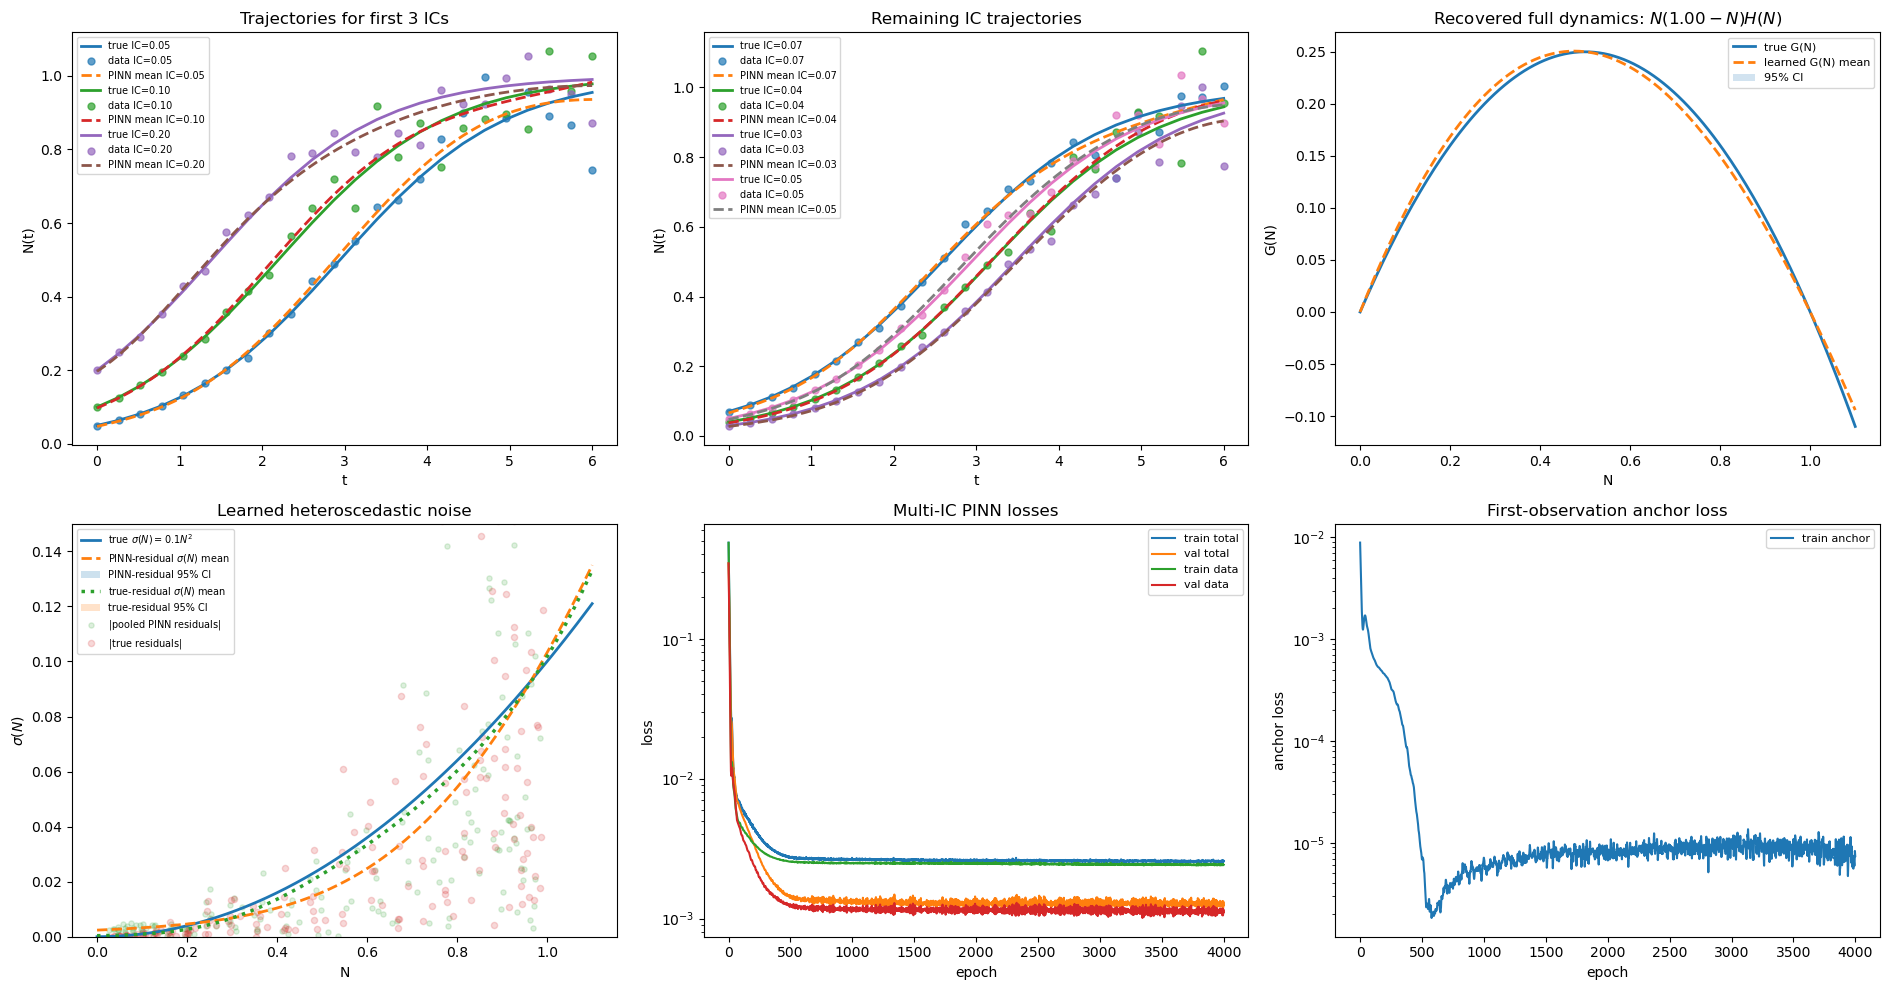

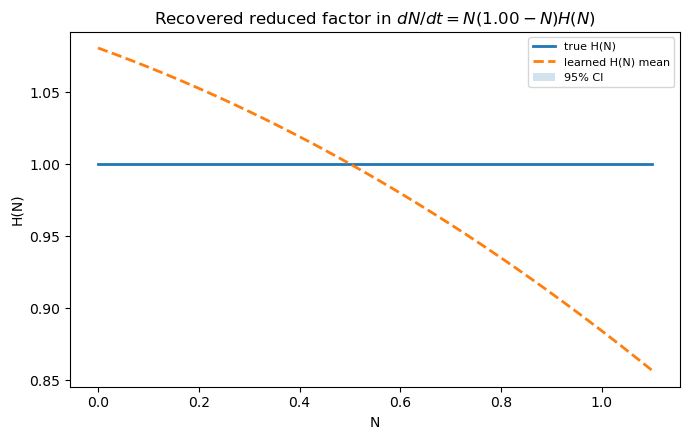

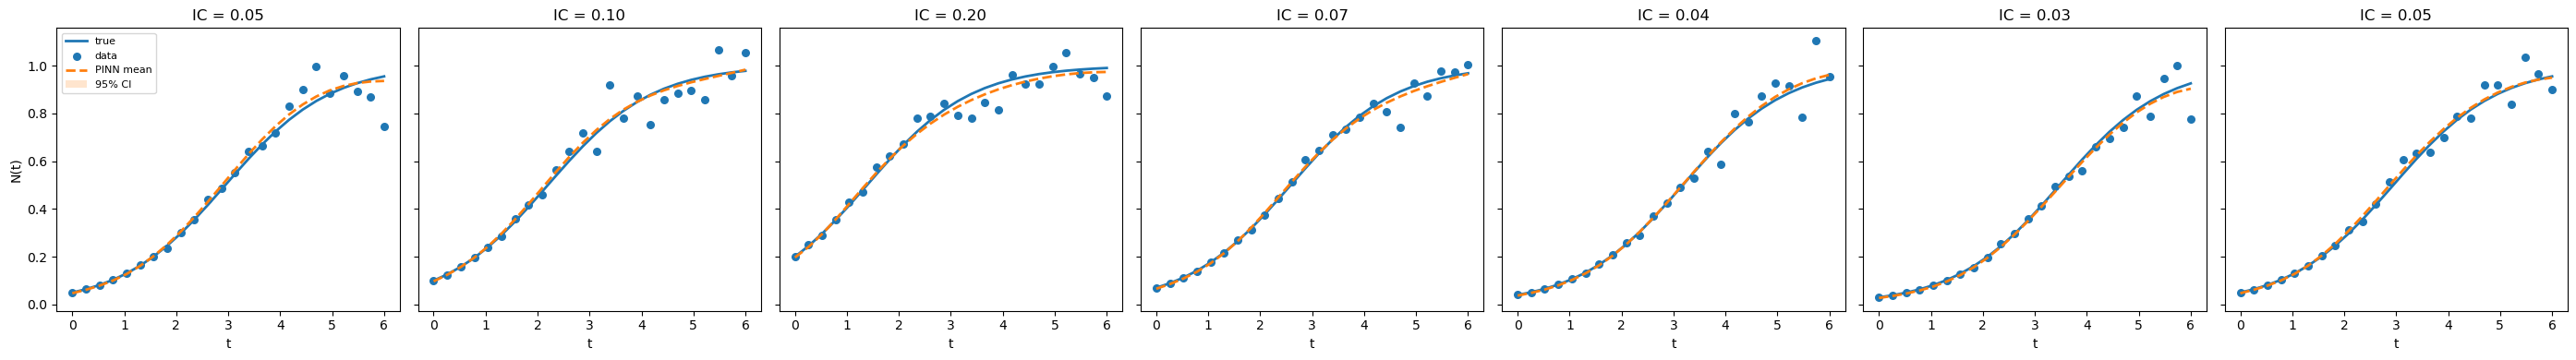

/var/folders/dn/jj6zl9nx6s541bq88x9x4zvm0000gn/T/ipykernel_84790/4106836078.py:1115: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axes[0].set_yscale("log")


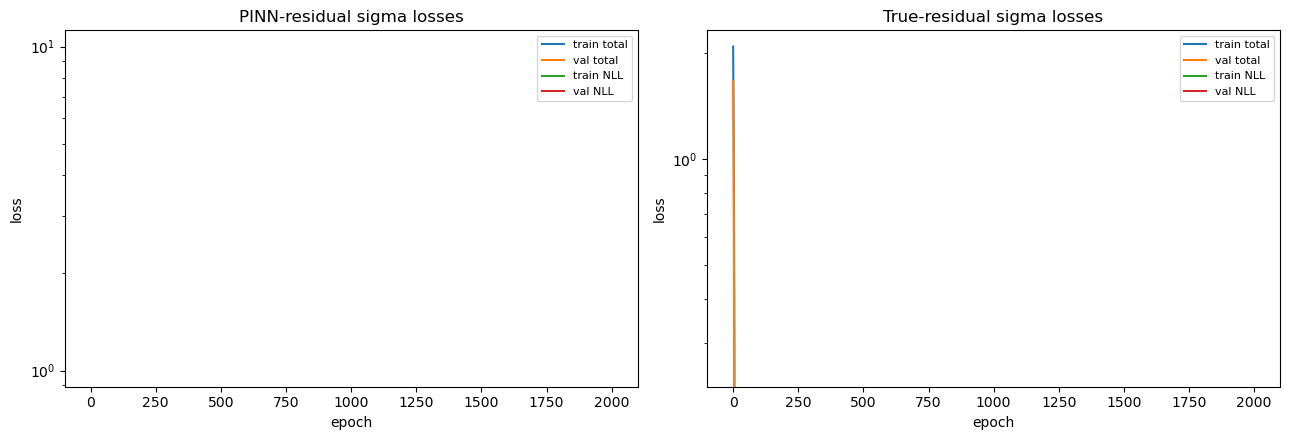


Multi-IC PINN summary
---------------------
Number of trajectories / ICs: 7
Synthetic IC values used to generate data: [0.05, 0.1, 0.2, 0.07, 0.04, 0.03, 0.05]
Number of PINN splits: 1
Validation fraction: 0.2
Model-selection criterion: validation loss
Mean best selection loss: 1.142292e-03
Std  best selection loss: N/A (only one split)
Mean best epoch: 3343.00
Std  best epoch: N/A (only one split)
Anchor weight lambda_anchor: 0.000
True structure:  dN/dt = N(1.0000 - N)H_true(N)
Model structure: dN/dt = N(1.0000 - N)H(N), with dyn_net learning H(N)

Initialization summary by split
-------------------------------
Split 1: dyn_init_seed=10000, sol_init_seeds=[20000, 20001, 20002, 20003, 20004, 20005, 20006], selection_criterion=val

PINN-residual sigma summary
---------------------------
Number of sigma repeats: 1
Mean best selection loss: -6.771662e+00
Std  best selection loss: N/A (only one repeat)
Mean best epoch: 1280.00
Std  best epoch: N/A (only one repeat)

True-residual sigma s

In [37]:


import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: dN/dt = N (a - N) H(N)
#    For logistic growth, choose H(N) = r and a = 1.
# ============================================================
r_true = 1.0
a_true = 1.0                  # true constant in N(a-N)
a_structure = 1.0             # model-side hyperparameter constant
N0_list = [0.05, 0.10, 0.20, 0.07, 0.04, 0.03, 0.05]
n_ics = len(N0_list)

numpts = 4 * (24 // 4)
t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)
t_plot = torch.linspace(0.0, 6.0, 200, device=device).view(-1, 1)
N_grid = torch.linspace(0.0, 1.1, 200, device=device).view(-1, 1)


def H_true(N):
    # logistic with N(a-N) factor pulled out
    return r_true * torch.ones_like(N)


def G_true(N):
    return N * (a_true - N) * H_true(N)


# ============================================================
# 2. Generate synthetic observed data
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)


y_true_list = []
y_data_list = []

with torch.no_grad():
    for N0 in N0_list:
        y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
        y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)
        y_data = y_true + 0.1 * torch.randn_like(y_true) * y_true**2

        y_true_list.append(y_true)
        y_data_list.append(y_data)

y_true_all = torch.stack(y_true_list, dim=0)   # [n_ics, numpts, 1]
y_data_all = torch.stack(y_data_list, dim=0)   # [n_ics, numpts, 1]

with torch.no_grad():
    G_grid_true = G_true(N_grid)
    H_grid_true = H_true(N_grid)
    sigma_true_grid = 0.1 * N_grid**2


# ============================================================
# 3. Model classes
# ============================================================
def init_weights_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        nn.init.zeros_(m.bias)


class SolutionNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        self.apply(init_weights_xavier)

    def forward(self, t):
        return self.net(t)


class DynamicsNet(nn.Module):
    """
    Learns H(N) in dN/dt = N (a - N) H(N),
    where a is a fixed hyperparameter constant.
    """
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        self.apply(init_weights_xavier)

    def forward(self, N):
        return self.net(N)


class SigmaNet(nn.Module):
    def __init__(self, hidden_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
            nn.Softplus(),
        )

    def forward(self, N):
        return self.net(N) + 1e-4


# ============================================================
# 4. Helper functions
# ============================================================
def mean_and_ci(arr, ci=1.96):
    arr = np.array(arr)
    mean = arr.mean(axis=0)
    if arr.shape[0] == 1:
        lo = mean.copy()
        hi = mean.copy()
    else:
        sem = arr.std(axis=0, ddof=1) / np.sqrt(arr.shape[0])
        lo = mean - ci * sem
        hi = mean + ci * sem
    return mean, lo, hi


def pinn_physics_residual(sol_net, dyn_net, t_col, a_const):
    """
    Physics model:
        dN/dt = N (a - N) H(N)
    where dyn_net(N) approximates H(N).
    """
    N_pred_col = sol_net(t_col)
    dN_dt = torch.autograd.grad(
        outputs=N_pred_col,
        inputs=t_col,
        grad_outputs=torch.ones_like(N_pred_col),
        create_graph=True,
        retain_graph=True,
    )[0]
    h_pred = dyn_net(N_pred_col)
    rhs_pred = N_pred_col * (a_const - N_pred_col) * h_pred
    phys_res = dN_dt - rhs_pred
    return N_pred_col, dN_dt, h_pred, rhs_pred, phys_res


def gaussian_sigma_nll(resid, sigma):
    sigma2 = sigma ** 2
    return torch.mean(torch.log(sigma2) + (resid ** 2) / sigma2)


def sigma_monotonicity_loss(model, N_col):
    N_req = N_col.clone().detach().requires_grad_(True)
    sigma_col = model(N_req)
    dsigma_dN = torch.autograd.grad(
        outputs=sigma_col,
        inputs=N_req,
        grad_outputs=torch.ones_like(sigma_col),
        create_graph=True,
        retain_graph=True,
    )[0]
    return torch.sum(torch.relu(-dsigma_dN) ** 2)


def fit_sigma_repeated(
    N_all,
    resid_all,
    N_eval_grid,
    N_col_base,
    n_repeats=1,
    val_fraction=0.2,
    n_epochs=3000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="sigma",
    print_every=500,
):
    n_samples = N_all.shape[0]
    use_validation = val_fraction > 0.0 and n_samples > 1

    if use_validation:
        n_val = int(round(val_fraction * n_samples))
        n_val = max(1, min(n_val, n_samples - 1))
    else:
        n_val = 0
    n_train = n_samples - n_val

    train_total_histories = []
    train_nll_histories = []
    train_mon_histories = []

    val_total_histories = []
    val_nll_histories = []
    val_mon_histories = []

    curve_histories = []
    best_val_losses = []
    best_epochs = []
    best_models = []

    for repeat in range(n_repeats):
        print(f"\n{'-' * 90}")
        print(f"Starting {label} repeat {repeat + 1}/{n_repeats}")
        print(f"{'-' * 90}")

        g = torch.Generator(device=device)
        g.manual_seed(seed_offset_split + repeat)

        perm = torch.randperm(n_samples, generator=g, device=device)
        train_idx = perm[:n_train].sort().values

        if use_validation:
            val_idx = perm[n_train:].sort().values
        else:
            val_idx = torch.empty(0, dtype=torch.long, device=device)

        N_train = N_all[train_idx]
        r_train = resid_all[train_idx]

        if use_validation:
            N_val = N_all[val_idx]
            r_val = resid_all[val_idx]

        torch.manual_seed(seed_offset_model + repeat)
        np.random.seed(seed_offset_model + repeat)

        sigma_net = SigmaNet(hidden_dim=hidden_dim).to(device)
        opt = torch.optim.Adam(sigma_net.parameters(), lr=lr)

        train_total_history = []
        train_nll_history = []
        train_mon_history = []

        val_total_history = []
        val_nll_history = []
        val_mon_history = []

        best_criterion = float("inf")
        best_epoch = -1
        best_state = None

        for epoch in range(n_epochs):
            opt.zero_grad()

            sigma_pred_train = sigma_net(N_train)
            train_nll = gaussian_sigma_nll(r_train, sigma_pred_train)
            train_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
            reg = lambda_reg * sum((p ** 2).sum() for p in sigma_net.parameters())

            train_total = train_nll + lambda_mon * train_mon + reg
            train_total.backward()
            opt.step()

            if use_validation:
                with torch.no_grad():
                    sigma_pred_val = sigma_net(N_val)
                    val_nll = gaussian_sigma_nll(r_val, sigma_pred_val)

                val_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
                val_total = val_nll + lambda_mon * val_mon

                criterion_value = val_total.item()
                val_total_item = val_total.item()
                val_nll_item = val_nll.item()
                val_mon_item = val_mon.item()
                criterion_name = "val"
            else:
                criterion_value = train_total.item()
                val_total_item = np.nan
                val_nll_item = np.nan
                val_mon_item = np.nan
                criterion_name = "train"

            train_total_history.append(train_total.item())
            train_nll_history.append(train_nll.item())
            train_mon_history.append(train_mon.item())

            val_total_history.append(val_total_item)
            val_nll_history.append(val_nll_item)
            val_mon_history.append(val_mon_item)

            if (epoch == 0) or ((epoch + 1) % print_every == 0) or (epoch == n_epochs - 1):
                if use_validation:
                    print(
                        f"{label} | Repeat {repeat + 1:2d}/{n_repeats} | "
                        f"Epoch {epoch + 1:5d}/{n_epochs} | "
                        f"Train Total: {train_total.item():.6e} | "
                        f"Train NLL: {train_nll.item():.6e} | "
                        f"Train Mon: {train_mon.item():.6e} | "
                        f"Val Total: {val_total_item:.6e} | "
                        f"Val NLL: {val_nll_item:.6e} | "
                        f"Val Mon: {val_mon_item:.6e}"
                    )
                else:
                    print(
                        f"{label} | Repeat {repeat + 1:2d}/{n_repeats} | "
                        f"Epoch {epoch + 1:5d}/{n_epochs} | "
                        f"Train Total: {train_total.item():.6e} | "
                        f"Train NLL: {train_nll.item():.6e} | "
                        f"Train Mon: {train_mon.item():.6e} | "
                        f"Val Total: N/A | Val NLL: N/A | Val Mon: N/A | "
                        f"Best-model criterion: training loss"
                    )

            if criterion_value < best_criterion:
                best_criterion = criterion_value
                best_epoch = epoch
                best_state = copy.deepcopy(sigma_net.state_dict())

        sigma_net.load_state_dict(best_state)
        sigma_net.eval()

        with torch.no_grad():
            sigma_curve = sigma_net(N_eval_grid).squeeze(1).cpu().numpy()

        best_models.append(copy.deepcopy(sigma_net))
        train_total_histories.append(train_total_history)
        train_nll_histories.append(train_nll_history)
        train_mon_histories.append(train_mon_history)

        val_total_histories.append(val_total_history)
        val_nll_histories.append(val_nll_history)
        val_mon_histories.append(val_mon_history)

        curve_histories.append(sigma_curve)
        best_val_losses.append(best_criterion)
        best_epochs.append(best_epoch)

        if use_validation:
            print(
                f"Finished {label} repeat {repeat + 1:2d}/{n_repeats} | "
                f"Best epoch = {best_epoch:5d} | Best val loss = {best_criterion:.6e}"
            )
        else:
            print(
                f"Finished {label} repeat {repeat + 1:2d}/{n_repeats} | "
                f"Best epoch = {best_epoch:5d} | Best train loss = {best_criterion:.6e}"
            )

    return {
        "train_total_histories": np.array(train_total_histories),
        "train_nll_histories": np.array(train_nll_histories),
        "train_mon_histories": np.array(train_mon_histories),
        "val_total_histories": np.array(val_total_histories),
        "val_nll_histories": np.array(val_nll_histories),
        "val_mon_histories": np.array(val_mon_histories),
        "curve_histories": np.array(curve_histories),
        "best_val_losses": np.array(best_val_losses),
        "best_epochs": np.array(best_epochs),
        "best_models": best_models,
    }


# ============================================================
# 5. Multi-IC PINN fit
# ============================================================
n_col = 1000
t_col_base = torch.linspace(0.0, 6.0, n_col, device=device).view(-1, 1)

n_epochs = 4000
n_splits = 1
print_every = 500
batch_obs = 24 * 4 * n_ics
batch_col = 100

val_fraction = 0.2
n_obs = t_obs.shape[0]
use_validation = val_fraction > 0.0 and n_obs > 1

if use_validation:
    n_val = int(round(val_fraction * n_obs))
    n_val = max(1, min(n_val, n_obs - 1))
else:
    n_val = 0
n_train = n_obs - n_val

lambda_phys = 1.0
lambda_anchor = 0.0
learning_rate = 1e-3
hidden_dim_sol = 32
hidden_dim_dyn = 32

data_split_seed_base = 1000
dyn_init_seed_base = 10000
sol_init_seed_base = 20000

train_total_histories = []
train_data_histories = []
train_phys_histories = []
train_anchor_histories = []

val_total_histories = []
val_data_histories = []
val_phys_histories = []

traj_histories = []
rhs_histories = []   # learned full G(N) = N(a-N)H(N)
h_histories = []     # learned reduced factor H(N)
obs_fit_histories = []

best_val_losses = []
best_epochs = []
best_states = []

for split in range(n_splits):
    print(f"\n{'=' * 90}")
    print(f"Starting PINN split {split + 1}/{n_splits}")
    print(f"{'=' * 90}")

    g = torch.Generator(device=device)
    g.manual_seed(data_split_seed_base + split)

    perm = torch.randperm(n_obs, generator=g, device=device)
    train_idx = perm[:n_train].sort().values

    if use_validation:
        val_idx = perm[n_train:].sort().values
    else:
        val_idx = torch.empty(0, dtype=torch.long, device=device)

    torch.manual_seed(dyn_init_seed_base + split)
    np.random.seed(dyn_init_seed_base + split)
    dyn_net = DynamicsNet(hidden_dim=hidden_dim_dyn).to(device)

    sol_net_list = []
    sol_init_seeds_this_split = []
    for i in range(n_ics):
        init_seed = sol_init_seed_base + 1000 * split + i
        sol_init_seeds_this_split.append(init_seed)
        torch.manual_seed(init_seed)
        np.random.seed(init_seed)
        sol_net_list.append(SolutionNet(hidden_dim=hidden_dim_sol).to(device))

    sol_nets = nn.ModuleList(sol_net_list)

    print(f"Dynamics init seed for split {split + 1}: {dyn_init_seed_base + split}")
    print(f"Solution init seeds for split {split + 1}: {sol_init_seeds_this_split}")
    print(f"Using structure: dN/dt = N * ({a_structure:.4f} - N) * H(N)")

    optimizer = torch.optim.Adam(
        list(dyn_net.parameters()) + list(sol_nets.parameters()),
        lr=learning_rate,
    )

    train_total_history = []
    train_data_history = []
    train_phys_history = []
    train_anchor_history = []

    val_total_history = []
    val_data_history = []
    val_phys_history = []

    best_criterion = float("inf")
    best_epoch = -1
    best_state = None

    for epoch in range(n_epochs):
        optimizer.zero_grad()

        total_data_loss = 0.0
        total_phys_loss = 0.0
        total_anchor_loss = 0.0

        for i in range(n_ics):
            sol_net = sol_nets[i]

            obs_sel = train_idx[torch.randperm(len(train_idx), device=device)[:batch_obs]]
            t_train = t_obs[obs_sel]
            y_train = y_data_all[i][obs_sel]

            N_pred_train = sol_net(t_train)
            data_loss = torch.mean((N_pred_train - y_train) ** 2)

            t_col = 6.0 * torch.rand(batch_col, 1, device=device)
            t_col.requires_grad_(True)
            _, _, _, _, phys_res = pinn_physics_residual(sol_net, dyn_net, t_col, a_structure)
            phys_loss = torch.mean(phys_res ** 2)

            t0_obs = t_obs[0:1]
            y0_obs = y_data_all[i][0:1]
            N0_pred = sol_net(t0_obs)
            anchor_loss = torch.mean((N0_pred - y0_obs) ** 2)

            total_data_loss += data_loss
            total_phys_loss += phys_loss
            total_anchor_loss += anchor_loss

        total_data_loss /= n_ics
        total_phys_loss /= n_ics
        total_anchor_loss /= n_ics

        train_loss = total_data_loss + lambda_phys * total_phys_loss + lambda_anchor * total_anchor_loss
        train_loss.backward()
        optimizer.step()

        if use_validation:
            with torch.no_grad():
                total_val_data_loss = 0.0
                for i in range(n_ics):
                    sol_net = sol_nets[i]
                    t_val = t_obs[val_idx]
                    y_val = y_data_all[i][val_idx]
                    N_pred_val = sol_net(t_val)
                    total_val_data_loss = total_val_data_loss + torch.mean((N_pred_val - y_val) ** 2)
                total_val_data_loss = total_val_data_loss / n_ics

            total_val_phys_loss = 0.0
            for i in range(n_ics):
                sol_net = sol_nets[i]
                t_col_val = t_col_base.clone().detach().requires_grad_(True)
                _, _, _, _, val_phys_res = pinn_physics_residual(sol_net, dyn_net, t_col_val, a_structure)
                total_val_phys_loss = total_val_phys_loss + torch.mean(val_phys_res ** 2)

            total_val_phys_loss = total_val_phys_loss / n_ics
            val_loss = total_val_data_loss + lambda_phys * total_val_phys_loss

            criterion_value = val_loss.item()
            criterion_name = "val"

            val_total_item = val_loss.item()
            val_data_item = total_val_data_loss.item()
            val_phys_item = total_val_phys_loss.item()
        else:
            criterion_value = train_loss.item()
            criterion_name = "train"

            val_total_item = np.nan
            val_data_item = np.nan
            val_phys_item = np.nan

        train_total_history.append(train_loss.item())
        train_data_history.append(total_data_loss.item())
        train_phys_history.append(total_phys_loss.item())
        train_anchor_history.append(total_anchor_loss.item())

        val_total_history.append(val_total_item)
        val_data_history.append(val_data_item)
        val_phys_history.append(val_phys_item)

        if (epoch == 0) or ((epoch + 1) % print_every == 0) or (epoch == n_epochs - 1):
            if use_validation:
                print(
                    f"PINN | Split {split + 1:2d}/{n_splits} | "
                    f"Epoch {epoch + 1:5d}/{n_epochs} | "
                    f"Train Total: {train_loss.item():.6e} | "
                    f"Train Data: {total_data_loss.item():.6e} | "
                    f"Train Phys: {total_phys_loss.item():.6e} | "
                    f"Train Anchor: {total_anchor_loss.item():.6e} | "
                    f"Val Total: {val_total_item:.6e} | "
                    f"Val Data: {val_data_item:.6e} | "
                    f"Val Phys: {val_phys_item:.6e}"
                )
            else:
                print(
                    f"PINN | Split {split + 1:2d}/{n_splits} | "
                    f"Epoch {epoch + 1:5d}/{n_epochs} | "
                    f"Train Total: {train_loss.item():.6e} | "
                    f"Train Data: {total_data_loss.item():.6e} | "
                    f"Train Phys: {total_phys_loss.item():.6e} | "
                    f"Train Anchor: {total_anchor_loss.item():.6e} | "
                    f"Val Total: N/A | Val Data: N/A | Val Phys: N/A | "
                    f"Best-model criterion: training loss"
                )

        if criterion_value < best_criterion:
            best_criterion = criterion_value
            best_epoch = epoch
            best_state = {
                "dyn_net": copy.deepcopy(dyn_net.state_dict()),
                "sol_nets": [copy.deepcopy(sol_net.state_dict()) for sol_net in sol_nets],
                "dyn_init_seed": dyn_init_seed_base + split,
                "sol_init_seeds": sol_init_seeds_this_split.copy(),
                "train_idx": train_idx.clone(),
                "val_idx": val_idx.clone(),
                "selection_criterion": criterion_name,
            }

    if use_validation:
        print(
            f"Finished PINN split {split + 1:2d}/{n_splits} | "
            f"Best epoch = {best_epoch:5d} | Best val loss = {best_criterion:.6e}"
        )
    else:
        print(
            f"Finished PINN split {split + 1:2d}/{n_splits} | "
            f"Best epoch = {best_epoch:5d} | Best train loss = {best_criterion:.6e}"
        )

    dyn_net.load_state_dict(best_state["dyn_net"])
    for i in range(n_ics):
        sol_nets[i].load_state_dict(best_state["sol_nets"][i])

    dyn_net.eval()
    for sol_net in sol_nets:
        sol_net.eval()

    with torch.no_grad():
        trajs_this_split = []
        obs_fits_this_split = []

        for i in range(n_ics):
            trajs_this_split.append(sol_nets[i](t_plot).squeeze(1).cpu().numpy())
            obs_fits_this_split.append(sol_nets[i](t_obs).squeeze(1).cpu().numpy())

        H_grid_learned = dyn_net(N_grid).squeeze(1).cpu().numpy()
        N_np = N_grid.squeeze(1).cpu().numpy()
        G_grid_learned = N_np * (a_structure - N_np) * H_grid_learned

    train_total_histories.append(train_total_history)
    train_data_histories.append(train_data_history)
    train_phys_histories.append(train_phys_history)
    train_anchor_histories.append(train_anchor_history)

    val_total_histories.append(val_total_history)
    val_data_histories.append(val_data_history)
    val_phys_histories.append(val_phys_history)

    traj_histories.append(np.array(trajs_this_split))
    obs_fit_histories.append(np.array(obs_fits_this_split))
    rhs_histories.append(G_grid_learned)
    h_histories.append(H_grid_learned)

    best_val_losses.append(best_criterion)
    best_epochs.append(best_epoch)
    best_states.append(best_state)

train_total_histories = np.array(train_total_histories)
train_data_histories = np.array(train_data_histories)
train_phys_histories = np.array(train_phys_histories)
train_anchor_histories = np.array(train_anchor_histories)

val_total_histories = np.array(val_total_histories)
val_data_histories = np.array(val_data_histories)
val_phys_histories = np.array(val_phys_histories)

traj_histories = np.array(traj_histories)
obs_fit_histories = np.array(obs_fit_histories)
rhs_histories = np.array(rhs_histories)
h_histories = np.array(h_histories)

rhs_mean, rhs_lo, rhs_hi = mean_and_ci(rhs_histories)
h_mean, h_lo, h_hi = mean_and_ci(h_histories)

traj_mean_per_ic = []
traj_lo_per_ic = []
traj_hi_per_ic = []

obs_fit_mean_per_ic = []
obs_fit_lo_per_ic = []
obs_fit_hi_per_ic = []

for i in range(n_ics):
    m, lo, hi = mean_and_ci(traj_histories[:, i, :])
    traj_mean_per_ic.append(m)
    traj_lo_per_ic.append(lo)
    traj_hi_per_ic.append(hi)

    m, lo, hi = mean_and_ci(obs_fit_histories[:, i, :])
    obs_fit_mean_per_ic.append(m)
    obs_fit_lo_per_ic.append(lo)
    obs_fit_hi_per_ic.append(hi)


# ============================================================
# 6. Learn sigma(N) from pooled multi-IC PINN residuals
# ============================================================
with torch.no_grad():
    y_rep = y_data_all.squeeze(-1).cpu().numpy()[None, :, :]
    resid_pinn_all_np = y_rep - obs_fit_histories

    N_pinn_sigma_all_np = obs_fit_histories.reshape(-1, 1)
    resid_pinn_sigma_all_np = resid_pinn_all_np.reshape(-1, 1)

    mask = N_pinn_sigma_all_np.squeeze() > 0.0
    N_pinn_sigma_all_np = N_pinn_sigma_all_np[mask]
    resid_pinn_sigma_all_np = resid_pinn_sigma_all_np[mask]

N_pinn_sigma_all = torch.tensor(N_pinn_sigma_all_np, dtype=torch.float32, device=device)
resid_pinn_sigma_all = torch.tensor(resid_pinn_sigma_all_np, dtype=torch.float32, device=device)

N_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_pinn_sigma_all.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_pinn_results = fit_sigma_repeated(
    N_all=N_pinn_sigma_all,
    resid_all=resid_pinn_sigma_all,
    N_eval_grid=N_grid,
    N_col_base=N_sigma_col_base,
    n_repeats=1,
    val_fraction=0.4,
    n_epochs=2000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="PINN-sigma",
    print_every=250,
)

sigma_pinn_mean, sigma_pinn_lo, sigma_pinn_hi = mean_and_ci(
    sigma_pinn_results["curve_histories"]
)


# ============================================================
# 7. Learn sigma_truefit(N) from true residuals
# ============================================================
with torch.no_grad():
    N_true_sigma_np = y_true_all.squeeze(-1).cpu().numpy().reshape(-1, 1)
    resid_true_sigma_np = (y_data_all - y_true_all).squeeze(-1).cpu().numpy().reshape(-1, 1)

    mask_true = N_true_sigma_np.squeeze() > 0.0
    N_true_sigma_np = N_true_sigma_np[mask_true]
    resid_true_sigma_np = resid_true_sigma_np[mask_true]

N_true_sigma = torch.tensor(N_true_sigma_np, dtype=torch.float32, device=device)
resid_true_sigma = torch.tensor(resid_true_sigma_np, dtype=torch.float32, device=device)

N_true_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_true_sigma.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_truefit_results = fit_sigma_repeated(
    N_all=N_true_sigma,
    resid_all=resid_true_sigma,
    N_eval_grid=N_grid,
    N_col_base=N_true_sigma_col_base,
    n_repeats=1,
    val_fraction=0.2,
    n_epochs=2000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=9000,
    seed_offset_model=11000,
    label="TRUE-sigma",
    print_every=250,
)

sigma_truefit_mean, sigma_truefit_lo, sigma_truefit_hi = mean_and_ci(
    sigma_truefit_results["curve_histories"]
)


# ============================================================
# 8. Residuals across all ICs using mean PINN fit
# ============================================================
with torch.no_grad():
    obs_fit_mean_all = np.array(obs_fit_mean_per_ic)
    y_true_np = y_true_all.squeeze(-1).cpu().numpy()
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()

    residuals_all = y_data_np - obs_fit_mean_all
    N_fit_all = obs_fit_mean_all.reshape(-1, 1)
    residuals_flat = residuals_all.reshape(-1, 1)

    mask = N_fit_all.squeeze() > 0.0
    N_fit_all = N_fit_all[mask]
    residuals_flat = residuals_flat[mask]


# ============================================================
# 9. Plots
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(19, 10))

# ------------------------------------------------------------
# Trajectories
# ------------------------------------------------------------
for i in range(min(3, n_ics)):
    axes[0, 0].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        linewidth=2,
        label=f"true IC={N0_list[i]:.2f}",
    )
    axes[0, 0].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        s=25,
        alpha=0.7,
        label=f"data IC={N0_list[i]:.2f}",
    )
    axes[0, 0].plot(
        t_plot.cpu().numpy(),
        traj_mean_per_ic[i],
        "--",
        linewidth=2,
        label=f"PINN mean IC={N0_list[i]:.2f}",
    )
    axes[0, 0].fill_between(
        t_plot.squeeze(1).cpu().numpy(),
        traj_lo_per_ic[i],
        traj_hi_per_ic[i],
        alpha=0.18,
    )

axes[0, 0].set_xlabel("t")
axes[0, 0].set_ylabel("N(t)")
axes[0, 0].set_title("Trajectories for first 3 ICs")
axes[0, 0].legend(fontsize=7)

# ------------------------------------------------------------
# Remaining ICs
# ------------------------------------------------------------
for i in range(3, n_ics):
    axes[0, 1].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        linewidth=2,
        label=f"true IC={N0_list[i]:.2f}",
    )
    axes[0, 1].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        s=25,
        alpha=0.7,
        label=f"data IC={N0_list[i]:.2f}",
    )
    axes[0, 1].plot(
        t_plot.cpu().numpy(),
        traj_mean_per_ic[i],
        "--",
        linewidth=2,
        label=f"PINN mean IC={N0_list[i]:.2f}",
    )
    axes[0, 1].fill_between(
        t_plot.squeeze(1).cpu().numpy(),
        traj_lo_per_ic[i],
        traj_hi_per_ic[i],
        alpha=0.18,
    )

axes[0, 1].set_xlabel("t")
axes[0, 1].set_ylabel("N(t)")
axes[0, 1].set_title("Remaining IC trajectories")
axes[0, 1].legend(fontsize=7)

# ------------------------------------------------------------
# Recovered full dynamics G(N) = N(a-N)H(N)
# ------------------------------------------------------------
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    G_grid_true.squeeze(1).cpu().numpy(),
    label="true G(N)",
    linewidth=2,
)
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    rhs_mean,
    "--",
    linewidth=2,
    label="learned G(N) mean",
)
axes[0, 2].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    rhs_lo,
    rhs_hi,
    alpha=0.20,
    label="95% CI",
)
axes[0, 2].set_xlabel("N")
axes[0, 2].set_ylabel("G(N)")
axes[0, 2].set_title(rf"Recovered full dynamics: $N({a_structure:.2f}-N)H(N)$")
axes[0, 2].legend(fontsize=8)

# ------------------------------------------------------------
# Learned sigma(N)
# ------------------------------------------------------------
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_true_grid.squeeze(1).cpu().numpy(),
    linewidth=2,
    label=r"true $\sigma(N)=0.1N^2$",
)
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_pinn_mean,
    "--",
    linewidth=2,
    label=r"PINN-residual $\sigma(N)$ mean",
)
axes[1, 0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_pinn_lo,
    sigma_pinn_hi,
    alpha=0.22,
    label="PINN-residual 95% CI",
)
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_truefit_mean,
    ":",
    linewidth=2.5,
    label=r"true-residual $\sigma(N)$ mean",
)
axes[1, 0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_truefit_lo,
    sigma_truefit_hi,
    alpha=0.22,
    label="true-residual 95% CI",
)
axes[1, 0].scatter(
    N_pinn_sigma_all.cpu().numpy().squeeze(),
    np.abs(resid_pinn_sigma_all.cpu().numpy().squeeze()),
    s=14,
    alpha=0.16,
    label=r"$|$pooled PINN residuals$|$",
)
axes[1, 0].scatter(
    N_true_sigma.cpu().numpy().squeeze(),
    np.abs(resid_true_sigma.cpu().numpy().squeeze()),
    s=20,
    alpha=0.18,
    label=r"$|$true residuals$|$",
)
axes[1, 0].set_xlabel("N")
axes[1, 0].set_ylabel(r"$\sigma(N)$")
axes[1, 0].set_title("Learned heteroscedastic noise")
axes[1, 0].legend(fontsize=7)
axes[1, 0].set_ylim(0, 0.15)

# ------------------------------------------------------------
# PINN losses
# ------------------------------------------------------------
epochs_init = np.arange(n_epochs)

train_total_mean, train_total_lo, train_total_hi = mean_and_ci(train_total_histories)
val_total_mean, val_total_lo, val_total_hi = mean_and_ci(val_total_histories)
train_data_mean, train_data_lo, train_data_hi = mean_and_ci(train_data_histories)
val_data_mean, val_data_lo, val_data_hi = mean_and_ci(val_data_histories)

axes[1, 1].plot(epochs_init, train_total_mean, label="train total")
axes[1, 1].fill_between(epochs_init, train_total_lo, train_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, val_total_mean, label="val total")
axes[1, 1].fill_between(epochs_init, val_total_lo, val_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, train_data_mean, label="train data")
axes[1, 1].fill_between(epochs_init, train_data_lo, train_data_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, val_data_mean, label="val data")
axes[1, 1].fill_between(epochs_init, val_data_lo, val_data_hi, alpha=0.2)
axes[1, 1].set_yscale("log")
axes[1, 1].set_xlabel("epoch")
axes[1, 1].set_ylabel("loss")
axes[1, 1].set_title("Multi-IC PINN losses")
axes[1, 1].legend(fontsize=8)

# ------------------------------------------------------------
# Anchor loss
# ------------------------------------------------------------
train_anchor_mean, train_anchor_lo, train_anchor_hi = mean_and_ci(train_anchor_histories)
axes[1, 2].plot(epochs_init, train_anchor_mean, label="train anchor")
axes[1, 2].fill_between(epochs_init, train_anchor_lo, train_anchor_hi, alpha=0.2)
axes[1, 2].set_yscale("log")
axes[1, 2].set_xlabel("epoch")
axes[1, 2].set_ylabel("anchor loss")
axes[1, 2].set_title("First-observation anchor loss")
axes[1, 2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Extra plot: recovered reduced factor H(N)
# ------------------------------------------------------------
plt.figure(figsize=(7, 4.5))
plt.plot(
    N_grid.cpu().numpy(),
    H_grid_true.squeeze(1).cpu().numpy(),
    label="true H(N)",
    linewidth=2,
)
plt.plot(
    N_grid.cpu().numpy(),
    h_mean,
    "--",
    linewidth=2,
    label="learned H(N) mean",
)
plt.fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    h_lo,
    h_hi,
    alpha=0.20,
    label="95% CI",
)
plt.xlabel("N")
plt.ylabel("H(N)")
plt.title(rf"Recovered reduced factor in $dN/dt = N({a_structure:.2f}-N)H(N)$")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# 10. Observation-time comparison
# ============================================================
fig, axs = plt.subplots(1, n_ics, figsize=(4 * n_ics, 4), sharey=True)

if n_ics == 1:
    axs = [axs]

for i in range(n_ics):
    axs[i].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        label="true",
        linewidth=2,
    )
    axs[i].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        label="data",
        s=30,
    )
    axs[i].plot(
        t_obs.cpu().numpy(),
        obs_fit_mean_per_ic[i],
        "--",
        linewidth=2,
        label="PINN mean",
    )
    axs[i].fill_between(
        t_obs.squeeze(1).cpu().numpy(),
        obs_fit_lo_per_ic[i],
        obs_fit_hi_per_ic[i],
        alpha=0.20,
        label="95% CI",
    )
    axs[i].set_title(f"IC = {N0_list[i]:.2f}")
    axs[i].set_xlabel("t")

axs[0].set_ylabel("N(t)")
axs[0].legend(fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# 11. Sigma training diagnostics
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

epochs_sigma = np.arange(sigma_pinn_results["train_total_histories"].shape[1])

sp_train_total_mean, sp_train_total_lo, sp_train_total_hi = mean_and_ci(
    sigma_pinn_results["train_total_histories"]
)
sp_val_total_mean, sp_val_total_lo, sp_val_total_hi = mean_and_ci(
    sigma_pinn_results["val_total_histories"]
)
sp_train_nll_mean, sp_train_nll_lo, sp_train_nll_hi = mean_and_ci(
    sigma_pinn_results["train_nll_histories"]
)
sp_val_nll_mean, sp_val_nll_lo, sp_val_nll_hi = mean_and_ci(
    sigma_pinn_results["val_nll_histories"]
)

axes[0].plot(epochs_sigma, sp_train_total_mean, label="train total")
axes[0].fill_between(epochs_sigma, sp_train_total_lo, sp_train_total_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_val_total_mean, label="val total")
axes[0].fill_between(epochs_sigma, sp_val_total_lo, sp_val_total_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_train_nll_mean, label="train NLL")
axes[0].fill_between(epochs_sigma, sp_train_nll_lo, sp_train_nll_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_val_nll_mean, label="val NLL")
axes[0].fill_between(epochs_sigma, sp_val_nll_lo, sp_val_nll_hi, alpha=0.2)
axes[0].set_yscale("log")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("PINN-residual sigma losses")
axes[0].legend(fontsize=8)

st_train_total_mean, st_train_total_lo, st_train_total_hi = mean_and_ci(
    sigma_truefit_results["train_total_histories"]
)
st_val_total_mean, st_val_total_lo, st_val_total_hi = mean_and_ci(
    sigma_truefit_results["val_total_histories"]
)
st_train_nll_mean, st_train_nll_lo, st_train_nll_hi = mean_and_ci(
    sigma_truefit_results["train_nll_histories"]
)
st_val_nll_mean, st_val_nll_lo, st_val_nll_hi = mean_and_ci(
    sigma_truefit_results["val_nll_histories"]
)

axes[1].plot(epochs_sigma, st_train_total_mean, label="train total")
axes[1].fill_between(epochs_sigma, st_train_total_lo, st_train_total_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_val_total_mean, label="val total")
axes[1].fill_between(epochs_sigma, st_val_total_lo, st_val_total_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_train_nll_mean, label="train NLL")
axes[1].fill_between(epochs_sigma, st_train_nll_lo, st_train_nll_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_val_nll_mean, label="val NLL")
axes[1].fill_between(epochs_sigma, st_val_nll_lo, st_val_nll_hi, alpha=0.2)
axes[1].set_yscale("log")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].set_title("True-residual sigma losses")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# 12. Summary
# ============================================================
print("\nMulti-IC PINN summary")
print("---------------------")
print(f"Number of trajectories / ICs: {n_ics}")
print(f"Synthetic IC values used to generate data: {N0_list}")
print(f"Number of PINN splits: {n_splits}")
print(f"Validation fraction: {val_fraction}")
print(f"Model-selection criterion: {'validation loss' if use_validation else 'training loss'}")
print(f"Mean best selection loss: {np.mean(best_val_losses):.6e}")
if len(best_val_losses) > 1:
    print(f"Std  best selection loss: {np.std(best_val_losses, ddof=1):.6e}")
else:
    print("Std  best selection loss: N/A (only one split)")
print(f"Mean best epoch: {np.mean(best_epochs):.2f}")
if len(best_epochs) > 1:
    print(f"Std  best epoch: {np.std(best_epochs, ddof=1):.2f}")
else:
    print("Std  best epoch: N/A (only one split)")
print(f"Anchor weight lambda_anchor: {lambda_anchor:.3f}")
print(f"True structure:  dN/dt = N({a_true:.4f} - N)H_true(N)")
print(f"Model structure: dN/dt = N({a_structure:.4f} - N)H(N), with dyn_net learning H(N)")

print("\nInitialization summary by split")
print("-------------------------------")
for split, st in enumerate(best_states, start=1):
    print(
        f"Split {split}: dyn_init_seed={st['dyn_init_seed']}, "
        f"sol_init_seeds={st['sol_init_seeds']}, "
        f"selection_criterion={st['selection_criterion']}"
    )

print("\nPINN-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_pinn_results['best_val_losses'])}")
print(f"Mean best selection loss: {sigma_pinn_results['best_val_losses'].mean():.6e}")
if len(sigma_pinn_results['best_val_losses']) > 1:
    print(f"Std  best selection loss: {sigma_pinn_results['best_val_losses'].std(ddof=1):.6e}")
else:
    print("Std  best selection loss: N/A (only one repeat)")
print(f"Mean best epoch: {sigma_pinn_results['best_epochs'].mean():.2f}")
if len(sigma_pinn_results['best_epochs']) > 1:
    print(f"Std  best epoch: {sigma_pinn_results['best_epochs'].std(ddof=1):.2f}")
else:
    print("Std  best epoch: N/A (only one repeat)")

print("\nTrue-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_truefit_results['best_val_losses'])}")
print(f"Mean best selection loss: {sigma_truefit_results['best_val_losses'].mean():.6e}")
if len(sigma_truefit_results['best_val_losses']) > 1:
    print(f"Std  best selection loss: {sigma_truefit_results['best_val_losses'].std(ddof=1):.6e}")
else:
    print("Std  best selection loss: N/A (only one repeat)")
print(f"Mean best epoch: {sigma_truefit_results['best_epochs'].mean():.2f}")
if len(sigma_truefit_results['best_epochs']) > 1:
    print(f"Std  best epoch: {sigma_truefit_results['best_epochs'].std(ddof=1):.2f}")
else:
    print("Std  best epoch: N/A (only one repeat)")

print("\nObserved time points: true vs data vs PINN mean")
for i in range(n_ics):
    print(f"\nTrajectory {i + 1} (synthetic IC used to generate data = {N0_list[i]:.2f})")
    for ti, yt, yd, mu in zip(
        t_obs.squeeze(1).cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        obs_fit_mean_per_ic[i],
    ):
        print(
            f"t = {ti:6.3f} | true = {yt:8.5f} | data = {yd:8.5f} | PINN = {mu:8.5f}"
        )

## gamma 


Starting PINN split 1/1
Dynamics init seed for split 1: 10000
Solution init seeds for split 1: [20000]
PINN | Split  1/1 | Epoch     1/20000 | Train Total: 1.000465e+02 | Train Data: 1.000429e+02 | Train Phys: 3.586849e-03 | Train Anchor: 2.471933e-03 | Val Total: N/A | Val Data: N/A | Val Phys: N/A | Best-model criterion: training loss
PINN | Split  1/1 | Epoch   500/20000 | Train Total: 4.282453e-02 | Train Data: 4.273508e-02 | Train Phys: 8.945038e-05 | Train Anchor: 1.368376e-03 | Val Total: N/A | Val Data: N/A | Val Phys: N/A | Best-model criterion: training loss
PINN | Split  1/1 | Epoch  1000/20000 | Train Total: 3.181348e-02 | Train Data: 3.178792e-02 | Train Phys: 2.556276e-05 | Train Anchor: 8.579378e-04 | Val Total: N/A | Val Data: N/A | Val Phys: N/A | Best-model criterion: training loss
PINN | Split  1/1 | Epoch  1500/20000 | Train Total: 2.292106e-02 | Train Data: 2.286143e-02 | Train Phys: 5.962265e-05 | Train Anchor: 3.233273e-04 | Val Total: N/A | Val Data: N/A | Val 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


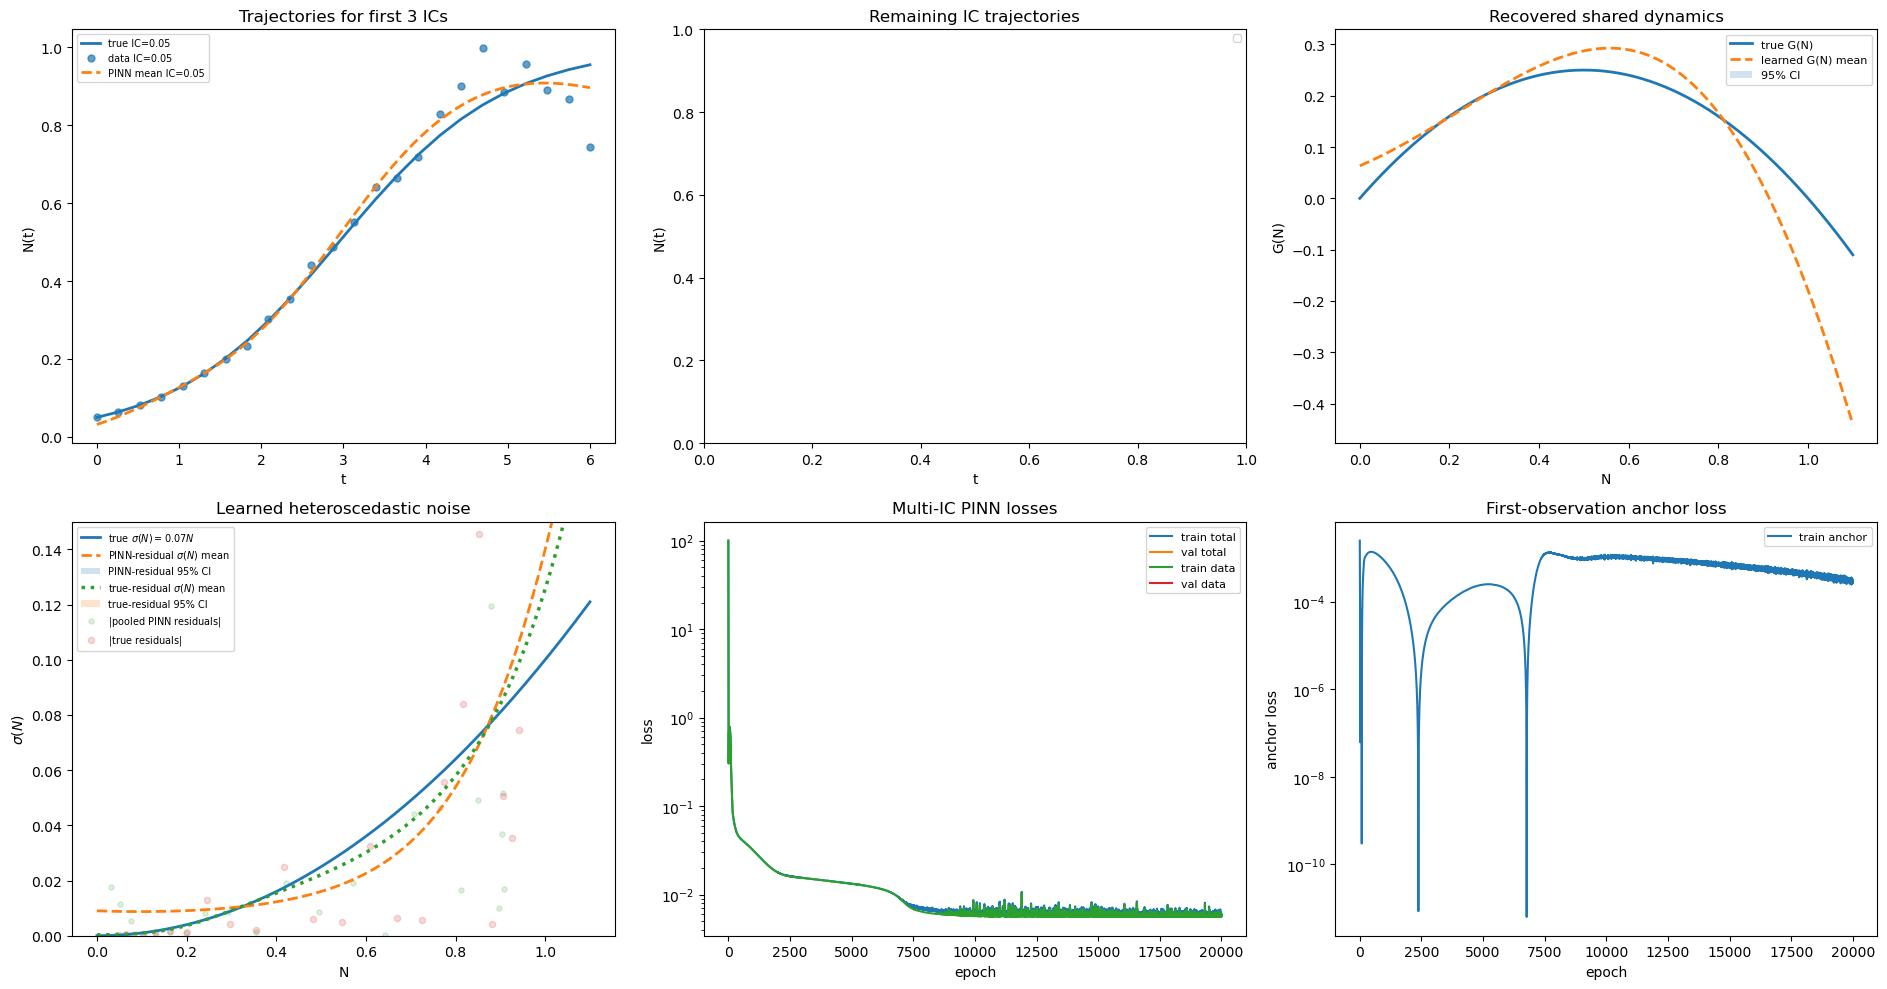

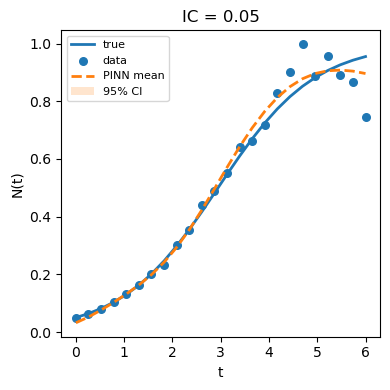

/var/folders/dn/jj6zl9nx6s541bq88x9x4zvm0000gn/T/ipykernel_62805/1440032368.py:1081: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axes[0].set_yscale("log")


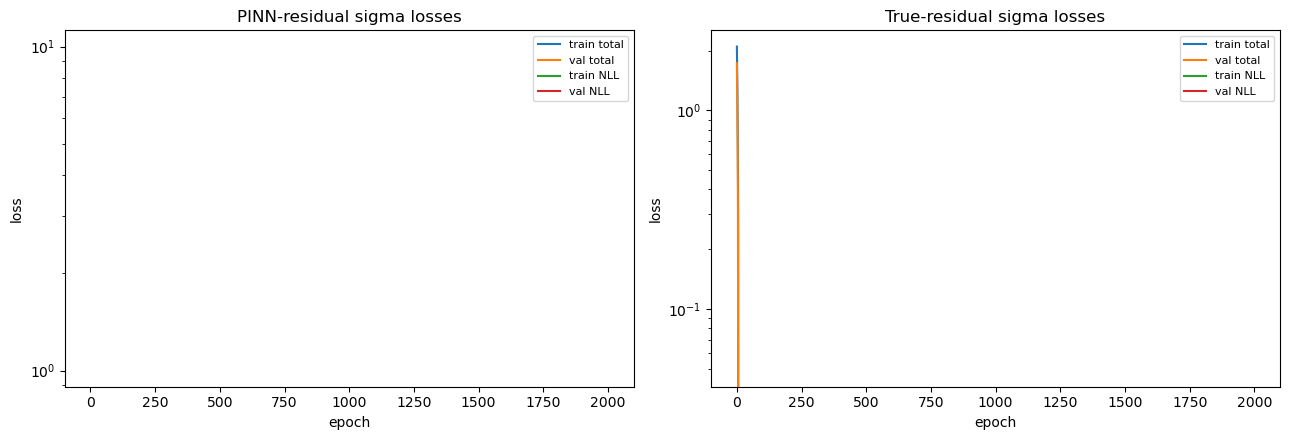


Multi-IC PINN summary
---------------------
Number of trajectories / ICs: 1
Synthetic IC values used to generate data: [0.05]
Number of PINN splits: 1
Validation fraction: 0.0
Model-selection criterion: training loss
Mean best selection loss: 5.774199e-03
Std  best selection loss: nan
Mean best epoch: 19413.00
Std  best epoch: nan
Anchor weight lambda_anchor: 0.000

Initialization summary by split
-------------------------------
Split 1: dyn_init_seed=10000, sol_init_seeds=[20000], selection_criterion=train

PINN-residual sigma summary
---------------------------
Number of sigma repeats: 1
Mean best selection loss: -6.976671e+00
Std  best selection loss: nan
Mean best epoch: 554.00
Std  best epoch: nan

True-residual sigma summary
---------------------------
Number of sigma repeats: 1
Mean best selection loss: -8.920355e+00
Std  best selection loss: nan
Mean best epoch: 1999.00
Std  best epoch: nan

Observed time points: true vs data vs PINN mean

Trajectory 1 (synthetic IC used to ge

In [45]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
# ============================================================
r_true = 1.0
N0_list = [0.05]#, 0.10, 0.20]#, 0.07, 0.04, 0.03, 0.05]
n_ics = len(N0_list)

numpts = 4 * (24 // 4)
t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)
t_plot = torch.linspace(0.0, 6.0, 200, device=device).view(-1, 1)
N_grid = torch.linspace(0.0, 1.1, 200, device=device).view(-1, 1)


def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# 2. Generate synthetic observed data for multiple ICs
#    Noise law is heteroscedastic: sigma_true(N) = 0.07 N
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)


y_true_list = []
y_data_list = []

with torch.no_grad():
    for N0 in N0_list:
        y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
        y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)
        y_data = y_true + 0.1 * torch.randn_like(y_true) * y_true**2

        y_true_list.append(y_true)
        y_data_list.append(y_data)

y_true_all = torch.stack(y_true_list, dim=0)   # [n_ics, numpts, 1]
y_data_all = torch.stack(y_data_list, dim=0)   # [n_ics, numpts, 1]

with torch.no_grad():
    G_grid_true = G_true(N_grid)
    sigma_true_grid = 0.1 * N_grid**2


# ============================================================
# 3. Model classes
# ============================================================
def init_weights_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        nn.init.zeros_(m.bias)
        
class SolutionNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        self.apply(init_weights_xavier)

    def forward(self, t):
        return self.net(t)


class DynamicsNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        self.apply(init_weights_xavier)

    def forward(self, N):
        return self.net(N)


class SigmaNet(nn.Module):
    def __init__(self, hidden_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
            nn.Softplus(),
        )

    def forward(self, N):
        return self.net(N) + 1e-4


# ============================================================
# 4. Helper functions
# ============================================================
def mean_and_ci(arr, ci=1.96):
    arr = np.array(arr)
    mean = arr.mean(axis=0)
    if arr.shape[0] == 1:
        lo = mean.copy()
        hi = mean.copy()
    else:
        sem = arr.std(axis=0, ddof=1) / np.sqrt(arr.shape[0])
        lo = mean - ci * sem
        hi = mean + ci * sem
    return mean, lo, hi


def pinn_physics_residual(sol_net, dyn_net, t_col):
    N_pred_col = sol_net(t_col)
    dN_dt = torch.autograd.grad(
        outputs=N_pred_col,
        inputs=t_col,
        grad_outputs=torch.ones_like(N_pred_col),
        create_graph=True,
        retain_graph=True,
    )[0]
    rhs_pred = dyn_net(N_pred_col)
    phys_res = dN_dt - rhs_pred
    return N_pred_col, dN_dt, rhs_pred, phys_res


def gaussian_sigma_nll(resid, sigma):
    sigma2 = sigma ** 2
    return torch.mean(torch.log(sigma2) + (resid ** 2) / sigma2)


def sigma_monotonicity_loss(model, N_col):
    N_req = N_col.clone().detach().requires_grad_(True)
    sigma_col = model(N_req)
    dsigma_dN = torch.autograd.grad(
        outputs=sigma_col,
        inputs=N_req,
        grad_outputs=torch.ones_like(sigma_col),
        create_graph=True,
        retain_graph=True,
    )[0]
    return torch.sum(torch.relu(-dsigma_dN) ** 2)


def fit_sigma_repeated(
    N_all,
    resid_all,
    N_eval_grid,
    N_col_base,
    n_repeats=1,
    val_fraction=0.2,
    n_epochs=3000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="sigma",
    print_every=500,
):
    n_samples = N_all.shape[0]
    use_validation = val_fraction > 0.0 and n_samples > 1

    if use_validation:
        n_val = int(round(val_fraction * n_samples))
        n_val = max(1, min(n_val, n_samples - 1))
    else:
        n_val = 0
    n_train = n_samples - n_val

    train_total_histories = []
    train_nll_histories = []
    train_mon_histories = []

    val_total_histories = []
    val_nll_histories = []
    val_mon_histories = []

    curve_histories = []
    best_val_losses = []
    best_epochs = []
    best_models = []

    for repeat in range(n_repeats):
        print(f"\n{'-' * 90}")
        print(f"Starting {label} repeat {repeat + 1}/{n_repeats}")
        print(f"{'-' * 90}")

        g = torch.Generator(device=device)
        g.manual_seed(seed_offset_split + repeat)

        perm = torch.randperm(n_samples, generator=g, device=device)
        train_idx = perm[:n_train].sort().values

        if use_validation:
            val_idx = perm[n_train:].sort().values
        else:
            val_idx = torch.empty(0, dtype=torch.long, device=device)

        N_train = N_all[train_idx]
        r_train = resid_all[train_idx]

        if use_validation:
            N_val = N_all[val_idx]
            r_val = resid_all[val_idx]

        torch.manual_seed(seed_offset_model + repeat)
        np.random.seed(seed_offset_model + repeat)

        sigma_net = SigmaNet(hidden_dim=hidden_dim).to(device)
        opt = torch.optim.Adam(sigma_net.parameters(), lr=lr)

        train_total_history = []
        train_nll_history = []
        train_mon_history = []

        val_total_history = []
        val_nll_history = []
        val_mon_history = []

        best_criterion = float("inf")
        best_epoch = -1
        best_state = None

        for epoch in range(n_epochs):
            opt.zero_grad()

            sigma_pred_train = sigma_net(N_train)
            train_nll = gaussian_sigma_nll(r_train, sigma_pred_train)
            train_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
            reg = lambda_reg * sum((p ** 2).sum() for p in sigma_net.parameters())

            train_total = train_nll + lambda_mon * train_mon + reg
            train_total.backward()
            opt.step()

            if use_validation:
                with torch.no_grad():
                    sigma_pred_val = sigma_net(N_val)
                    val_nll = gaussian_sigma_nll(r_val, sigma_pred_val)

                val_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
                val_total = val_nll + lambda_mon * val_mon

                criterion_value = val_total.item()
                val_total_item = val_total.item()
                val_nll_item = val_nll.item()
                val_mon_item = val_mon.item()
                criterion_name = "val"
            else:
                criterion_value = train_total.item()
                val_total_item = np.nan
                val_nll_item = np.nan
                val_mon_item = np.nan
                criterion_name = "train"

            train_total_history.append(train_total.item())
            train_nll_history.append(train_nll.item())
            train_mon_history.append(train_mon.item())

            val_total_history.append(val_total_item)
            val_nll_history.append(val_nll_item)
            val_mon_history.append(val_mon_item)

            if (epoch == 0) or ((epoch + 1) % print_every == 0) or (epoch == n_epochs - 1):
                if use_validation:
                    print(
                        f"{label} | Repeat {repeat + 1:2d}/{n_repeats} | "
                        f"Epoch {epoch + 1:5d}/{n_epochs} | "
                        f"Train Total: {train_total.item():.6e} | "
                        f"Train NLL: {train_nll.item():.6e} | "
                        f"Train Mon: {train_mon.item():.6e} | "
                        f"Val Total: {val_total_item:.6e} | "
                        f"Val NLL: {val_nll_item:.6e} | "
                        f"Val Mon: {val_mon_item:.6e}"
                    )
                else:
                    print(
                        f"{label} | Repeat {repeat + 1:2d}/{n_repeats} | "
                        f"Epoch {epoch + 1:5d}/{n_epochs} | "
                        f"Train Total: {train_total.item():.6e} | "
                        f"Train NLL: {train_nll.item():.6e} | "
                        f"Train Mon: {train_mon.item():.6e} | "
                        f"Val Total: N/A | Val NLL: N/A | Val Mon: N/A | "
                        f"Best-model criterion: training loss"
                    )

            if criterion_value < best_criterion:
                best_criterion = criterion_value
                best_epoch = epoch
                best_state = copy.deepcopy(sigma_net.state_dict())

        sigma_net.load_state_dict(best_state)
        sigma_net.eval()

        with torch.no_grad():
            sigma_curve = sigma_net(N_eval_grid).squeeze(1).cpu().numpy()

        best_models.append(copy.deepcopy(sigma_net))
        train_total_histories.append(train_total_history)
        train_nll_histories.append(train_nll_history)
        train_mon_histories.append(train_mon_history)

        val_total_histories.append(val_total_history)
        val_nll_histories.append(val_nll_history)
        val_mon_histories.append(val_mon_history)

        curve_histories.append(sigma_curve)
        best_val_losses.append(best_criterion)
        best_epochs.append(best_epoch)

        if use_validation:
            print(
                f"Finished {label} repeat {repeat + 1:2d}/{n_repeats} | "
                f"Best epoch = {best_epoch:5d} | Best val loss = {best_criterion:.6e}"
            )
        else:
            print(
                f"Finished {label} repeat {repeat + 1:2d}/{n_repeats} | "
                f"Best epoch = {best_epoch:5d} | Best train loss = {best_criterion:.6e}"
            )

    return {
        "train_total_histories": np.array(train_total_histories),
        "train_nll_histories": np.array(train_nll_histories),
        "train_mon_histories": np.array(train_mon_histories),
        "val_total_histories": np.array(val_total_histories),
        "val_nll_histories": np.array(val_nll_histories),
        "val_mon_histories": np.array(val_mon_histories),
        "curve_histories": np.array(curve_histories),
        "best_val_losses": np.array(best_val_losses),
        "best_epochs": np.array(best_epochs),
        "best_models": best_models,
    }


# ============================================================
# 5. Multi-IC PINN fit across train/validation splits
#    - one shared dyn_net
#    - one sol_net per IC
#    - NO true IC penalty
#    - optional anchor to first observed point
#    - DIVERSE NN INITIALIZATIONS across splits and ICs
#    - if val_fraction == 0, best model is chosen by training loss
# ============================================================
n_col = 1000
t_col_base = torch.linspace(0.0, 6.0, n_col, device=device).view(-1, 1)

n_epochs = 20000
n_splits = 1
print_every = 500
batch_obs = 24*4*n_ics
batch_col = 100

val_fraction = 0.0
n_obs = t_obs.shape[0]
use_validation = val_fraction > 0.0 and n_obs > 1

if use_validation:
    n_val = int(round(val_fraction * n_obs))
    n_val = max(1, min(n_val, n_obs - 1))
else:
    n_val = 0
n_train = n_obs - n_val

lambda_phys = 1.0
lambda_anchor = 0.0
learning_rate = 1e-3
hidden_dim_sol = 32
hidden_dim_dyn = 32

# seeds controlling diverse initializations
data_split_seed_base = 1000
dyn_init_seed_base = 10000
sol_init_seed_base = 20000

train_total_histories = []
train_data_histories = []
train_phys_histories = []
train_anchor_histories = []

val_total_histories = []
val_data_histories = []
val_phys_histories = []

traj_histories = []
rhs_histories = []
obs_fit_histories = []

best_val_losses = []
best_epochs = []
best_states = []

for split in range(n_splits):
    print(f"\n{'=' * 90}")
    print(f"Starting PINN split {split + 1}/{n_splits}")
    print(f"{'=' * 90}")

    # -------------------------
    # split-specific data split
    # -------------------------
    g = torch.Generator(device=device)
    g.manual_seed(data_split_seed_base + split)

    perm = torch.randperm(n_obs, generator=g, device=device)
    train_idx = perm[:n_train].sort().values

    if use_validation:
        val_idx = perm[n_train:].sort().values
    else:
        val_idx = torch.empty(0, dtype=torch.long, device=device)

    # -------------------------
    # DIVERSE model initialization
    # - different dyn_net init per split
    # - different sol_net init per split
    # - different sol_net init across ICs
    # -------------------------
    torch.manual_seed(dyn_init_seed_base + split)
    np.random.seed(dyn_init_seed_base + split)
    dyn_net = DynamicsNet(hidden_dim=hidden_dim_dyn).to(device)

    sol_net_list = []
    sol_init_seeds_this_split = []
    for i in range(n_ics):
        init_seed = sol_init_seed_base + 1000 * split + i
        sol_init_seeds_this_split.append(init_seed)
        torch.manual_seed(init_seed)
        np.random.seed(init_seed)
        sol_net_list.append(SolutionNet(hidden_dim=hidden_dim_sol).to(device))

    sol_nets = nn.ModuleList(sol_net_list)

    print(f"Dynamics init seed for split {split + 1}: {dyn_init_seed_base + split}")
    print(f"Solution init seeds for split {split + 1}: {sol_init_seeds_this_split}")

    optimizer = torch.optim.Adam(
        list(dyn_net.parameters()) + list(sol_nets.parameters()),
        lr=learning_rate,
    )

    train_total_history = []
    train_data_history = []
    train_phys_history = []
    train_anchor_history = []

    val_total_history = []
    val_data_history = []
    val_phys_history = []

    best_criterion = float("inf")
    best_epoch = -1
    best_state = None

    for epoch in range(n_epochs):
        optimizer.zero_grad()

        total_data_loss = 0.0
        total_phys_loss = 0.0
        total_anchor_loss = 0.0

        for i in range(n_ics):
            sol_net = sol_nets[i]

            # sample observation mini-batch from training indices
            obs_sel = train_idx[torch.randperm(len(train_idx), device=device)[:batch_obs]]
            t_train = t_obs[obs_sel]
            y_train = y_data_all[i][obs_sel]

            N_pred_train = sol_net(t_train)
            denom = torch.where(N_pred_train > 0.1, N_pred_train**2, torch.ones_like(N_pred_train))
            data_loss = torch.mean(((N_pred_train - y_train) / denom) ** 2)

            # resample collocation points each epoch
            t_col = 6.0 * torch.rand(batch_col, 1, device=device)
            t_col.requires_grad_(True)
            _, _, _, phys_res = pinn_physics_residual(sol_net, dyn_net, t_col)
            phys_loss = torch.mean(phys_res ** 2)

            # anchor stays deterministic
            t0_obs = t_obs[0:1]
            y0_obs = y_data_all[i][0:1]
            N0_pred = sol_net(t0_obs)
            anchor_loss = torch.mean((N0_pred - y0_obs) ** 2)

            total_data_loss += data_loss
            total_phys_loss += phys_loss
            total_anchor_loss += anchor_loss

        total_data_loss /= n_ics
        total_phys_loss /= n_ics
        total_anchor_loss /= n_ics

        train_loss = total_data_loss + lambda_phys * total_phys_loss + lambda_anchor * total_anchor_loss
        train_loss.backward()
        optimizer.step()

        if use_validation:
            with torch.no_grad():
                total_val_data_loss = 0.0
                for i in range(n_ics):
                    sol_net = sol_nets[i]
                    t_val = t_obs[val_idx]
                    y_val = y_data_all[i][val_idx]
                    N_pred_val = sol_net(t_val)
                    total_val_data_loss = total_val_data_loss + torch.mean((N_pred_val - y_val) ** 2)

                total_val_data_loss = total_val_data_loss / n_ics

            total_val_phys_loss = 0.0
            for i in range(n_ics):
                sol_net = sol_nets[i]
                t_col_val = t_col_base.clone().detach().requires_grad_(True)
                _, _, _, val_phys_res = pinn_physics_residual(sol_net, dyn_net, t_col_val)
                total_val_phys_loss = total_val_phys_loss + torch.mean(val_phys_res ** 2)

            total_val_phys_loss = total_val_phys_loss / n_ics
            val_loss = total_val_data_loss + lambda_phys * total_val_phys_loss

            criterion_value = val_loss.item()
            criterion_name = "val"

            val_total_item = val_loss.item()
            val_data_item = total_val_data_loss.item()
            val_phys_item = total_val_phys_loss.item()
        else:
            criterion_value = train_loss.item()
            criterion_name = "train"

            val_total_item = np.nan
            val_data_item = np.nan
            val_phys_item = np.nan

        train_total_history.append(train_loss.item())
        train_data_history.append(total_data_loss.item())
        train_phys_history.append(total_phys_loss.item())
        train_anchor_history.append(total_anchor_loss.item())

        val_total_history.append(val_total_item)
        val_data_history.append(val_data_item)
        val_phys_history.append(val_phys_item)

        if (epoch == 0) or ((epoch + 1) % print_every == 0) or (epoch == n_epochs - 1):
            if use_validation:
                print(
                    f"PINN | Split {split + 1:2d}/{n_splits} | "
                    f"Epoch {epoch + 1:5d}/{n_epochs} | "
                    f"Train Total: {train_loss.item():.6e} | "
                    f"Train Data: {total_data_loss.item():.6e} | "
                    f"Train Phys: {total_phys_loss.item():.6e} | "
                    f"Train Anchor: {total_anchor_loss.item():.6e} | "
                    f"Val Total: {val_total_item:.6e} | "
                    f"Val Data: {val_data_item:.6e} | "
                    f"Val Phys: {val_phys_item:.6e}"
                )
            else:
                print(
                    f"PINN | Split {split + 1:2d}/{n_splits} | "
                    f"Epoch {epoch + 1:5d}/{n_epochs} | "
                    f"Train Total: {train_loss.item():.6e} | "
                    f"Train Data: {total_data_loss.item():.6e} | "
                    f"Train Phys: {total_phys_loss.item():.6e} | "
                    f"Train Anchor: {total_anchor_loss.item():.6e} | "
                    f"Val Total: N/A | Val Data: N/A | Val Phys: N/A | "
                    f"Best-model criterion: training loss"
                )

        if criterion_value < best_criterion:
            best_criterion = criterion_value
            best_epoch = epoch
            best_state = {
                "dyn_net": copy.deepcopy(dyn_net.state_dict()),
                "sol_nets": [copy.deepcopy(sol_net.state_dict()) for sol_net in sol_nets],
                "dyn_init_seed": dyn_init_seed_base + split,
                "sol_init_seeds": sol_init_seeds_this_split.copy(),
                "train_idx": train_idx.clone(),
                "val_idx": val_idx.clone(),
                "selection_criterion": criterion_name,
            }

    if use_validation:
        print(
            f"Finished PINN split {split + 1:2d}/{n_splits} | "
            f"Best epoch = {best_epoch:5d} | Best val loss = {best_criterion:.6e}"
        )
    else:
        print(
            f"Finished PINN split {split + 1:2d}/{n_splits} | "
            f"Best epoch = {best_epoch:5d} | Best train loss = {best_criterion:.6e}"
        )

    dyn_net.load_state_dict(best_state["dyn_net"])
    for i in range(n_ics):
        sol_nets[i].load_state_dict(best_state["sol_nets"][i])

    dyn_net.eval()
    for sol_net in sol_nets:
        sol_net.eval()

    with torch.no_grad():
        trajs_this_split = []
        obs_fits_this_split = []

        for i in range(n_ics):
            trajs_this_split.append(sol_nets[i](t_plot).squeeze(1).cpu().numpy())
            obs_fits_this_split.append(sol_nets[i](t_obs).squeeze(1).cpu().numpy())

        G_grid_learned = dyn_net(N_grid).squeeze(1).cpu().numpy()

    train_total_histories.append(train_total_history)
    train_data_histories.append(train_data_history)
    train_phys_histories.append(train_phys_history)
    train_anchor_histories.append(train_anchor_history)

    val_total_histories.append(val_total_history)
    val_data_histories.append(val_data_history)
    val_phys_histories.append(val_phys_history)

    traj_histories.append(np.array(trajs_this_split))
    obs_fit_histories.append(np.array(obs_fits_this_split))
    rhs_histories.append(G_grid_learned)

    best_val_losses.append(best_criterion)
    best_epochs.append(best_epoch)
    best_states.append(best_state)

train_total_histories = np.array(train_total_histories)
train_data_histories = np.array(train_data_histories)
train_phys_histories = np.array(train_phys_histories)
train_anchor_histories = np.array(train_anchor_histories)

val_total_histories = np.array(val_total_histories)
val_data_histories = np.array(val_data_histories)
val_phys_histories = np.array(val_phys_histories)

traj_histories = np.array(traj_histories)         # [n_splits, n_ics, len(t_plot)]
obs_fit_histories = np.array(obs_fit_histories)   # [n_splits, n_ics, len(t_obs)]
rhs_histories = np.array(rhs_histories)

rhs_mean, rhs_lo, rhs_hi = mean_and_ci(rhs_histories)

traj_mean_per_ic = []
traj_lo_per_ic = []
traj_hi_per_ic = []

obs_fit_mean_per_ic = []
obs_fit_lo_per_ic = []
obs_fit_hi_per_ic = []

for i in range(n_ics):
    m, lo, hi = mean_and_ci(traj_histories[:, i, :])
    traj_mean_per_ic.append(m)
    traj_lo_per_ic.append(lo)
    traj_hi_per_ic.append(hi)

    m, lo, hi = mean_and_ci(obs_fit_histories[:, i, :])
    obs_fit_mean_per_ic.append(m)
    obs_fit_lo_per_ic.append(lo)
    obs_fit_hi_per_ic.append(hi)


# ============================================================
# 6. Learn sigma(N) from pooled multi-IC PINN residuals
#    residual = y_data - N_hat_PINN
# ============================================================
with torch.no_grad():
    y_rep = y_data_all.squeeze(-1).cpu().numpy()[None, :, :]
    resid_pinn_all_np = y_rep - obs_fit_histories

    N_pinn_sigma_all_np = obs_fit_histories.reshape(-1, 1)
    resid_pinn_sigma_all_np = resid_pinn_all_np.reshape(-1, 1)

    mask = N_pinn_sigma_all_np.squeeze() > 0.0
    N_pinn_sigma_all_np = N_pinn_sigma_all_np[mask]
    resid_pinn_sigma_all_np = resid_pinn_sigma_all_np[mask]

N_pinn_sigma_all = torch.tensor(N_pinn_sigma_all_np, dtype=torch.float32, device=device)
resid_pinn_sigma_all = torch.tensor(resid_pinn_sigma_all_np, dtype=torch.float32, device=device)

N_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_pinn_sigma_all.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_pinn_results = fit_sigma_repeated(
    N_all=N_pinn_sigma_all,
    resid_all=resid_pinn_sigma_all,
    N_eval_grid=N_grid,
    N_col_base=N_sigma_col_base,
    n_repeats=1,
    val_fraction=0.4,
    n_epochs=2000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="PINN-sigma",
    print_every=250,
)

sigma_pinn_mean, sigma_pinn_lo, sigma_pinn_hi = mean_and_ci(
    sigma_pinn_results["curve_histories"]
)


# ============================================================
# 7. Learn sigma_truefit(N) from true residuals using all ICs
#    residual_true = y_data - y_true
# ============================================================
with torch.no_grad():
    N_true_sigma_np = y_true_all.squeeze(-1).cpu().numpy().reshape(-1, 1)
    resid_true_sigma_np = (y_data_all - y_true_all).squeeze(-1).cpu().numpy().reshape(-1, 1)

    mask_true = N_true_sigma_np.squeeze() > 0.0
    N_true_sigma_np = N_true_sigma_np[mask_true]
    resid_true_sigma_np = resid_true_sigma_np[mask_true]

N_true_sigma = torch.tensor(N_true_sigma_np, dtype=torch.float32, device=device)
resid_true_sigma = torch.tensor(resid_true_sigma_np, dtype=torch.float32, device=device)

N_true_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_true_sigma.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_truefit_results = fit_sigma_repeated(
    N_all=N_true_sigma,
    resid_all=resid_true_sigma,
    N_eval_grid=N_grid,
    N_col_base=N_true_sigma_col_base,
    n_repeats=1,
    val_fraction=0.2,
    n_epochs=2000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=9000,
    seed_offset_model=11000,
    label="TRUE-sigma",
    print_every=250,
)

sigma_truefit_mean, sigma_truefit_lo, sigma_truefit_hi = mean_and_ci(
    sigma_truefit_results["curve_histories"]
)


# ============================================================
# 8. Residuals across all ICs using mean PINN fit
# ============================================================
with torch.no_grad():
    obs_fit_mean_all = np.array(obs_fit_mean_per_ic)
    y_true_np = y_true_all.squeeze(-1).cpu().numpy()
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()

    residuals_all = y_data_np - obs_fit_mean_all
    N_fit_all = obs_fit_mean_all.reshape(-1, 1)
    residuals_flat = residuals_all.reshape(-1, 1)

    mask = N_fit_all.squeeze() > 0.0
    N_fit_all = N_fit_all[mask]
    residuals_flat = residuals_flat[mask]


# ============================================================
# 9. Plots
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(19, 10))

# ------------------------------------------------------------
# Trajectories for first 3 ICs
# ------------------------------------------------------------
for i in range(min(3, n_ics)):
    axes[0, 0].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        linewidth=2,
        label=f"true IC={N0_list[i]:.2f}",
    )
    axes[0, 0].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        s=25,
        alpha=0.7,
        label=f"data IC={N0_list[i]:.2f}",
    )
    axes[0, 0].plot(
        t_plot.cpu().numpy(),
        traj_mean_per_ic[i],
        "--",
        linewidth=2,
        label=f"PINN mean IC={N0_list[i]:.2f}",
    )
    axes[0, 0].fill_between(
        t_plot.squeeze(1).cpu().numpy(),
        traj_lo_per_ic[i],
        traj_hi_per_ic[i],
        alpha=0.18,
    )

axes[0, 0].set_xlabel("t")
axes[0, 0].set_ylabel("N(t)")
axes[0, 0].set_title("Trajectories for first 3 ICs")
axes[0, 0].legend(fontsize=7)

# ------------------------------------------------------------
# Trajectories for remaining ICs
# ------------------------------------------------------------
for i in range(3, n_ics):
    axes[0, 1].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        linewidth=2,
        label=f"true IC={N0_list[i]:.2f}",
    )
    axes[0, 1].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        s=25,
        alpha=0.7,
        label=f"data IC={N0_list[i]:.2f}",
    )
    axes[0, 1].plot(
        t_plot.cpu().numpy(),
        traj_mean_per_ic[i],
        "--",
        linewidth=2,
        label=f"PINN mean IC={N0_list[i]:.2f}",
    )
    axes[0, 1].fill_between(
        t_plot.squeeze(1).cpu().numpy(),
        traj_lo_per_ic[i],
        traj_hi_per_ic[i],
        alpha=0.18,
    )

axes[0, 1].set_xlabel("t")
axes[0, 1].set_ylabel("N(t)")
axes[0, 1].set_title("Remaining IC trajectories")
axes[0, 1].legend(fontsize=7)

# ------------------------------------------------------------
# Recovered dynamics
# ------------------------------------------------------------
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    G_grid_true.squeeze(1).cpu().numpy(),
    label="true G(N)",
    linewidth=2,
)
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    rhs_mean,
    "--",
    linewidth=2,
    label="learned G(N) mean",
)
axes[0, 2].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    rhs_lo,
    rhs_hi,
    alpha=0.20,
    label="95% CI",
)
axes[0, 2].set_xlabel("N")
axes[0, 2].set_ylabel("G(N)")
axes[0, 2].set_title("Recovered shared dynamics")
axes[0, 2].legend(fontsize=8)

# ------------------------------------------------------------
# Learned sigma(N): PINN residual sigma + true residual sigma
# ------------------------------------------------------------
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_true_grid.squeeze(1).cpu().numpy(),
    linewidth=2,
    label=r"true $\sigma(N)=0.07N$",
)
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_pinn_mean,
    "--",
    linewidth=2,
    label=r"PINN-residual $\sigma(N)$ mean",
)
axes[1, 0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_pinn_lo,
    sigma_pinn_hi,
    alpha=0.22,
    label="PINN-residual 95% CI",
)
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_truefit_mean,
    ":",
    linewidth=2.5,
    label=r"true-residual $\sigma(N)$ mean",
)
axes[1, 0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_truefit_lo,
    sigma_truefit_hi,
    alpha=0.22,
    label="true-residual 95% CI",
)
axes[1, 0].scatter(
    N_pinn_sigma_all.cpu().numpy().squeeze(),
    np.abs(resid_pinn_sigma_all.cpu().numpy().squeeze()),
    s=14,
    alpha=0.16,
    label=r"$|$pooled PINN residuals$|$",
)
axes[1, 0].scatter(
    N_true_sigma.cpu().numpy().squeeze(),
    np.abs(resid_true_sigma.cpu().numpy().squeeze()),
    s=20,
    alpha=0.18,
    label=r"$|$true residuals$|$",
)
axes[1, 0].set_xlabel("N")
axes[1, 0].set_ylabel(r"$\sigma(N)$")
axes[1, 0].set_title("Learned heteroscedastic noise")
axes[1, 0].legend(fontsize=7)
axes[1, 0].set_ylim(0, 0.15)

# ------------------------------------------------------------
# PINN training losses
# ------------------------------------------------------------
epochs_init = np.arange(n_epochs)

train_total_mean, train_total_lo, train_total_hi = mean_and_ci(train_total_histories)
val_total_mean, val_total_lo, val_total_hi = mean_and_ci(val_total_histories)
train_data_mean, train_data_lo, train_data_hi = mean_and_ci(train_data_histories)
val_data_mean, val_data_lo, val_data_hi = mean_and_ci(val_data_histories)

axes[1, 1].plot(epochs_init, train_total_mean, label="train total")
axes[1, 1].fill_between(epochs_init, train_total_lo, train_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, val_total_mean, label="val total")
axes[1, 1].fill_between(epochs_init, val_total_lo, val_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, train_data_mean, label="train data")
axes[1, 1].fill_between(epochs_init, train_data_lo, train_data_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, val_data_mean, label="val data")
axes[1, 1].fill_between(epochs_init, val_data_lo, val_data_hi, alpha=0.2)
axes[1, 1].set_yscale("log")
axes[1, 1].set_xlabel("epoch")
axes[1, 1].set_ylabel("loss")
axes[1, 1].set_title("Multi-IC PINN losses")
axes[1, 1].legend(fontsize=8)

# ------------------------------------------------------------
# Anchor loss
# ------------------------------------------------------------
train_anchor_mean, train_anchor_lo, train_anchor_hi = mean_and_ci(train_anchor_histories)
axes[1, 2].plot(epochs_init, train_anchor_mean, label="train anchor")
axes[1, 2].fill_between(epochs_init, train_anchor_lo, train_anchor_hi, alpha=0.2)
axes[1, 2].set_yscale("log")
axes[1, 2].set_xlabel("epoch")
axes[1, 2].set_ylabel("anchor loss")
axes[1, 2].set_title("First-observation anchor loss")
axes[1, 2].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# 10. Observation-time comparison for all ICs
# ============================================================
fig, axs = plt.subplots(1, n_ics, figsize=(4 * n_ics, 4), sharey=True)

if n_ics == 1:
    axs = [axs]

for i in range(n_ics):
    axs[i].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        label="true",
        linewidth=2,
    )
    axs[i].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        label="data",
        s=30,
    )
    axs[i].plot(
        t_obs.cpu().numpy(),
        obs_fit_mean_per_ic[i],
        "--",
        linewidth=2,
        label="PINN mean",
    )
    axs[i].fill_between(
        t_obs.squeeze(1).cpu().numpy(),
        obs_fit_lo_per_ic[i],
        obs_fit_hi_per_ic[i],
        alpha=0.20,
        label="95% CI",
    )
    axs[i].set_title(f"IC = {N0_list[i]:.2f}")
    axs[i].set_xlabel("t")

axs[0].set_ylabel("N(t)")
axs[0].legend(fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# 11. Sigma training diagnostics
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

epochs_sigma = np.arange(sigma_pinn_results["train_total_histories"].shape[1])

sp_train_total_mean, sp_train_total_lo, sp_train_total_hi = mean_and_ci(
    sigma_pinn_results["train_total_histories"]
)
sp_val_total_mean, sp_val_total_lo, sp_val_total_hi = mean_and_ci(
    sigma_pinn_results["val_total_histories"]
)
sp_train_nll_mean, sp_train_nll_lo, sp_train_nll_hi = mean_and_ci(
    sigma_pinn_results["train_nll_histories"]
)
sp_val_nll_mean, sp_val_nll_lo, sp_val_nll_hi = mean_and_ci(
    sigma_pinn_results["val_nll_histories"]
)

axes[0].plot(epochs_sigma, sp_train_total_mean, label="train total")
axes[0].fill_between(epochs_sigma, sp_train_total_lo, sp_train_total_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_val_total_mean, label="val total")
axes[0].fill_between(epochs_sigma, sp_val_total_lo, sp_val_total_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_train_nll_mean, label="train NLL")
axes[0].fill_between(epochs_sigma, sp_train_nll_lo, sp_train_nll_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_val_nll_mean, label="val NLL")
axes[0].fill_between(epochs_sigma, sp_val_nll_lo, sp_val_nll_hi, alpha=0.2)
axes[0].set_yscale("log")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("PINN-residual sigma losses")
axes[0].legend(fontsize=8)

st_train_total_mean, st_train_total_lo, st_train_total_hi = mean_and_ci(
    sigma_truefit_results["train_total_histories"]
)
st_val_total_mean, st_val_total_lo, st_val_total_hi = mean_and_ci(
    sigma_truefit_results["val_total_histories"]
)
st_train_nll_mean, st_train_nll_lo, st_train_nll_hi = mean_and_ci(
    sigma_truefit_results["train_nll_histories"]
)
st_val_nll_mean, st_val_nll_lo, st_val_nll_hi = mean_and_ci(
    sigma_truefit_results["val_nll_histories"]
)

axes[1].plot(epochs_sigma, st_train_total_mean, label="train total")
axes[1].fill_between(epochs_sigma, st_train_total_lo, st_train_total_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_val_total_mean, label="val total")
axes[1].fill_between(epochs_sigma, st_val_total_lo, st_val_total_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_train_nll_mean, label="train NLL")
axes[1].fill_between(epochs_sigma, st_train_nll_lo, st_train_nll_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_val_nll_mean, label="val NLL")
axes[1].fill_between(epochs_sigma, st_val_nll_lo, st_val_nll_hi, alpha=0.2)
axes[1].set_yscale("log")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].set_title("True-residual sigma losses")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# 12. Summary
# ============================================================
print("\nMulti-IC PINN summary")
print("---------------------")
print(f"Number of trajectories / ICs: {n_ics}")
print(f"Synthetic IC values used to generate data: {N0_list}")
print(f"Number of PINN splits: {n_splits}")
print(f"Validation fraction: {val_fraction}")
print(f"Model-selection criterion: {'validation loss' if use_validation else 'training loss'}")
print(f"Mean best selection loss: {np.mean(best_val_losses):.6e}")
print(f"Std  best selection loss: {np.std(best_val_losses, ddof=1):.6e}")
print(f"Mean best epoch: {np.mean(best_epochs):.2f}")
print(f"Std  best epoch: {np.std(best_epochs, ddof=1):.2f}")
print(f"Anchor weight lambda_anchor: {lambda_anchor:.3f}")

print("\nInitialization summary by split")
print("-------------------------------")
for split, st in enumerate(best_states, start=1):
    print(
        f"Split {split}: dyn_init_seed={st['dyn_init_seed']}, "
        f"sol_init_seeds={st['sol_init_seeds']}, "
        f"selection_criterion={st['selection_criterion']}"
    )

print("\nPINN-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_pinn_results['best_val_losses'])}")
print(f"Mean best selection loss: {sigma_pinn_results['best_val_losses'].mean():.6e}")
print(f"Std  best selection loss: {sigma_pinn_results['best_val_losses'].std(ddof=1):.6e}")
print(f"Mean best epoch: {sigma_pinn_results['best_epochs'].mean():.2f}")
print(f"Std  best epoch: {sigma_pinn_results['best_epochs'].std(ddof=1):.2f}")

print("\nTrue-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_truefit_results['best_val_losses'])}")
print(f"Mean best selection loss: {sigma_truefit_results['best_val_losses'].mean():.6e}")
print(f"Std  best selection loss: {sigma_truefit_results['best_val_losses'].std(ddof=1):.6e}")
print(f"Mean best epoch: {sigma_truefit_results['best_epochs'].mean():.2f}")
print(f"Std  best epoch: {sigma_truefit_results['best_epochs'].std(ddof=1):.2f}")

print("\nObserved time points: true vs data vs PINN mean")
for i in range(n_ics):
    print(f"\nTrajectory {i + 1} (synthetic IC used to generate data = {N0_list[i]:.2f})")
    for ti, yt, yd, mu in zip(
        t_obs.squeeze(1).cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        obs_fit_mean_per_ic[i],
    ):
        print(
            f"t = {ti:6.3f} | true = {yt:8.5f} | data = {yd:8.5f} | PINN = {mu:8.5f}"
        )

Number of non-empty PINN bins: 18
Bin counts: [1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 6]


/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:1017: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:2776: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!
[ Info: Final population:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.598e-04  1.594e+01  y = 0.026917
3           2.096e-04  5.734e-01  y = x₀ * 0.056501
5           8.247e-05  4.663e-01  y = -0.0069254 / (x₀ - 1.0004)
7           8.240e-05  4.205e-04  y = -0.0069254 / (x₀ - (x₀ / x₀))
───────────────────────────────────────────────────────────────────────────────────────────────────

Best symbolic expression for PINN empirical mean residual:
complexity                                                      5
loss                                                     0.000082
equation                          -0.006925391 / (x0 - 1.0003812)
score                                                    0.466289
sympy_format                      -0.006925391/(x0 - 1*1.0003812)
lambda_format    PySRFunction(X=>-0.006925391/(x0 - 1*1.0003812))
Name: 2, dtype: object
ideal value 0.7978845608028654

Sympy form:
-0

[ Info: Results saved to:


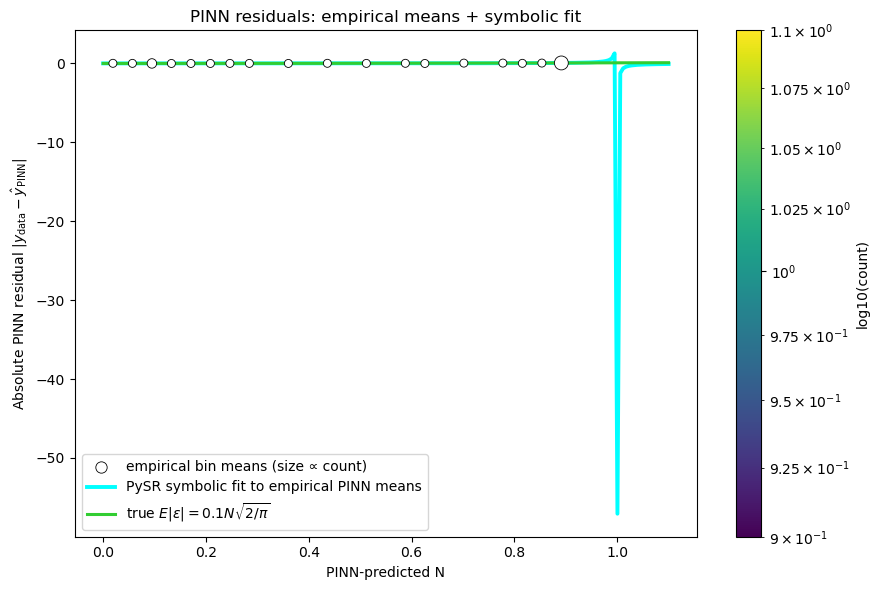

  - /var/folders/dn/jj6zl9nx6s541bq88x9x4zvm0000gn/T/tmpyi65ysvk/20260309_125553_hcwPMQ/hall_of_fame.csv


In [46]:
from pysr import PySRRegressor

# ============================================================
# A. Build empirical means from PINN residuals
#    using the already-computed quantities:
#      N_pinn_sigma_all, resid_pinn_sigma_all, N_grid
# ============================================================
N_pinn_np = N_pinn_sigma_all.detach().cpu().numpy().reshape(-1)
abs_resid_pinn_np = np.abs(resid_pinn_sigma_all.detach().cpu().numpy().reshape(-1))

# choose bins over the support of the PINN-predicted states
N_max_fit = max(float(N_pinn_np.max()), float(N_grid.max().item()))
bins = np.linspace(0.0, N_max_fit, 30)
centers = 0.5 * (bins[:-1] + bins[1:])

means = []
counts = []

for i in range(len(bins) - 1):
    mask = (N_pinn_np >= bins[i]) & (N_pinn_np < bins[i + 1])
    if np.any(mask):
        means.append(abs_resid_pinn_np[mask].mean())
        counts.append(mask.sum())
    else:
        means.append(np.nan)
        counts.append(0)

means = np.array(means, dtype=np.float64)
counts = np.array(counts, dtype=np.float64)

valid = ~np.isnan(means)

X_emp_pinn = centers[valid][:, None]   # shape [n_bins_nonempty, 1]
Y_emp_pinn = means[valid]              # shape [n_bins_nonempty]
W_emp_pinn = counts[valid]             # weight by number of points in bin

print("Number of non-empty PINN bins:", len(X_emp_pinn))
print("Bin counts:", W_emp_pinn.astype(int))


# ============================================================
# B. Fit symbolic expression to empirical PINN mean residuals
#    weighted by bin counts
# ============================================================
pysr_model_pinn = PySRRegressor(
    niterations=10,
    populations=100,
   # population_size=10,
    maxsize=10,
    maxdepth=10,
    binary_operators=["+", "-", "*", "/"],
    #unary_operators=["exp", "log"],
    model_selection="best",
    loss="loss(prediction, target, weight) = weight * (prediction - target)^2",
    verbosity=1,
    progress=True,
    temp_equation_file=True,
    delete_tempfiles=True,
)

pysr_model_pinn.fit(X_emp_pinn, Y_emp_pinn, weights=W_emp_pinn)

print("\nBest symbolic expression for PINN empirical mean residual:")
print(pysr_model_pinn.get_best())

print("ideal value", np.sqrt(2 / np.pi))
try:
    print("\nSympy form:")
    print(pysr_model_pinn.sympy())
except Exception:
    pass

try:
    print("\nLaTeX form:")
    print(pysr_model_pinn.latex())
except Exception:
    pass

def sigma_true(N):
    return 0.1 * N**2

sigma_grid_np = sigma_true(N_grid).squeeze(-1).cpu().numpy()
expected_abs = sigma_grid_np * np.sqrt(2 / np.pi)

# ============================================================
# C. Evaluate symbolic fit on the same N_grid used elsewhere
# ============================================================
N_grid_np = N_grid.detach().cpu().numpy().reshape(-1, 1)
symbolic_pinn_mean = pysr_model_pinn.predict(N_grid_np)


# ============================================================
# D. Optional reference curve from the known true noise law
#    Since data were generated with sigma(N)=0.1N and
#    E|epsilon| = sigma*sqrt(2/pi)
# ============================================================
expected_abs_true = sigma_grid_np * np.sqrt(2 / np.pi)


# ============================================================
# E. Plot: PINN absolute residuals + empirical means + symbolic fit
# ============================================================
plt.figure(figsize=(9, 6))

hb = plt.hexbin(
    N_pinn_np,
    abs_resid_pinn_np,
    gridsize=70,
    mincnt=1,
    bins="log"
)
plt.colorbar(hb, label="log10(count)")

marker_sizes = 20 + 80 * (W_emp_pinn / W_emp_pinn.max())
plt.scatter(
    X_emp_pinn[:, 0],
    Y_emp_pinn,
    s=marker_sizes,
    color="white",
    edgecolor="black",
    linewidth=0.6,
    zorder=3,
    label="empirical bin means (size ∝ count)"
)

plt.plot(
    N_grid_np[:, 0],
    symbolic_pinn_mean,
    color="cyan",
    lw=2.8,
    label="PySR symbolic fit to empirical PINN means"
)

plt.plot(
    N_grid_np[:, 0],
    expected_abs_true,
    color="limegreen",
    lw=2.2,
    label=r"true $E|\epsilon| = 0.1N\sqrt{2/\pi}$"
)

plt.xlabel("PINN-predicted N")
plt.ylabel(r"Absolute PINN residual $|y_{\mathrm{data}}-\hat y_{\mathrm{PINN}}|$")
plt.title("PINN residuals: empirical means + symbolic fit")
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
# ============================================================
r_true = 1
N0_list = [0.05, 0.10, 0.20, 0.07, 0.04, 0.03, 0.05]
n_ics = len(N0_list)

numpts = 4 * (24 // 4)\\\\\\
t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)

def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# 2. Generate synthetic observed data
#    Noise law is heteroscedastic: sigma_true(N) = 0.1 N
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)

with torch.no_grad():
    y_true_list = []
    y_data_list = []

    for N0 in N0_list:
        y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
        y_true_i = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)
        y_data_i = y_true_i + 0.1 * torch.randn_like(y_true_i) * y_true_i

        y_true_list.append(y_true_i)
        y_data_list.append(y_data_i)

    y_true_all = torch.stack(y_true_list, dim=0)   # [n_ics, T, 1]
    y_data_all = torch.stack(y_data_list, dim=0)   # [n_ics, T, 1]


# ============================================================
# 3. Networks
# ============================================================
class SolutionNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, t):
        return self.net(t)


class DynamicsNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, N):
        return self.net(N)


# ============================================================
# 4. Helpers
# ============================================================
def make_sigma_data_from_obs(y_obs, floor=0.02):
    """
    Known heteroscedastic observation model.
    Here we use sigma(y_obs)=0.1*|y_obs| with a small floor.
    Works for either [T,1] or [n_ics,T,1] tensors.
    """
    return 0.05 * torch.ones_like(y_obs) 
    #return 0.1 * torch.clamp(y_obs.abs(), min=floor)

def flatten_param_count(model):
    return sum(p.numel() for p in model.parameters())

def l2_prior_loss(model, sigma_prior):
    loss = 0.0
    nblocks = 0
    for p in model.parameters():
        loss = loss + 0.5 * torch.mean((p / sigma_prior) ** 2)
        nblocks += 1
    return loss / nblocks

def randomized_prior_loss(model, noise_list, sigma_prior):
    loss = 0.0
    nblocks = 0
    for p, eta in zip(model.parameters(), noise_list):
        loss = loss + 0.5 * torch.mean((p / sigma_prior - eta) ** 2)
        nblocks += 1
    return loss / nblocks

def grad_wrt_t(y, t):
    return torch.autograd.grad(
        outputs=y,
        inputs=t,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]

def mean_and_std(arr, axis=0):
    arr = np.array(arr)
    return arr.mean(axis=axis), arr.std(axis=axis)

def mean_and_ci(arr, ci=1.96):
    arr = np.array(arr)
    mean = arr.mean(axis=0)
    if arr.shape[0] == 1:
        lo = mean.copy()
        hi = mean.copy()
    else:
        sem = arr.std(axis=0, ddof=1) / np.sqrt(arr.shape[0])
        lo = mean - ci * sem
        hi = mean + ci * sem
    return mean, lo, hi


# ============================================================
# 5. Bayesian/MAP and randomized rPINN losses
# ============================================================
t_phys = torch.linspace(0.0, 6.0, 300, device=device).view(-1, 1)

# Known observation uncertainty model from data
sigma_data_all = make_sigma_data_from_obs(y_data_all)

# Hyperparameters
sigma_phys = 0.1
sigma_prior = 1

def compute_map_losses(sol_nets, dyn_net, t_obs, y_data_all, sigma_data_all, t_phys,
                       sigma_phys=0.05, sigma_prior=1.0):
    """
    Deterministic multi-IC PINN/MAP objective:
      average over ICs of:
        data term + physics term
      plus Gaussian priors
    No true-IC term is used.
    """
    total_data_loss = 0.0
    total_physics_loss = 0.0

    for i, sol_net in enumerate(sol_nets):
        # ----- data term -----
        N_obs = sol_net(t_obs)
        data_res = (N_obs - y_data_all[i]) / sigma_data_all[i]
        data_loss_i = 0.5 * torch.mean(data_res ** 2)

        # ----- physics term -----
        t_phys_req = t_phys.clone().detach().requires_grad_(True)
        N_phys = sol_net(t_phys_req)
        dN_dt = grad_wrt_t(N_phys, t_phys_req)
        G_phys = dyn_net(N_phys)
        phys_res = (dN_dt - G_phys) / sigma_phys
        physics_loss_i = 0.5 * torch.mean(phys_res ** 2)

        total_data_loss = total_data_loss + data_loss_i
        total_physics_loss = total_physics_loss + physics_loss_i

    data_loss = total_data_loss / len(sol_nets)
    physics_loss = total_physics_loss / len(sol_nets)

    # ----- Gaussian priors on NN weights -----
    prior_sol = 0.0
    for sol_net in sol_nets:
        prior_sol = prior_sol + l2_prior_loss(sol_net, sigma_prior)
    prior_sol = prior_sol / len(sol_nets)

    prior_dyn = l2_prior_loss(dyn_net, sigma_prior)
    prior_loss = prior_sol + prior_dyn

    total = data_loss + physics_loss + prior_loss
    return {
        "total": total,
        "data": data_loss,
        "physics": physics_loss,
        "prior": prior_loss,
    }

def sample_rpinn_noises(sol_nets, dyn_net, y_shape, phys_shape, device):
    """
    In normalized coordinates, all randomized targets are standard normal.
    One data/physics noise per IC, and one prior noise list per network.
    """
    noise = {
        "data": [torch.randn(y_shape, device=device) for _ in range(len(sol_nets))],
        "physics": [torch.randn(phys_shape, device=device) for _ in range(len(sol_nets))],
        "sol_prior": [[torch.randn_like(p)*0 for p in sol_net.parameters()] for sol_net in sol_nets],
        "dyn_prior": [torch.randn_like(p)*0 for p in dyn_net.parameters()],
    }
    return noise

def compute_randomized_losses(sol_nets, dyn_net, t_obs, y_data_all, sigma_data_all, t_phys, noise,
                              sigma_phys=0.05, sigma_prior=1.0):
    """
    Multi-IC rPINN randomized objective:
      average over ICs of:
        0.5 * || standardized_residual - random_noise ||^2
      for data and physics, plus randomized priors.
    """
    total_data_loss = 0.0
    total_physics_loss = 0.0

    for i, sol_net in enumerate(sol_nets):
        # ----- randomized data term -----
        N_obs = sol_net(t_obs)
        data_res = (N_obs - y_data_all[i]) / sigma_data_all[i]
        data_loss_i = 0.5 * torch.mean((data_res - noise["data"][i]) ** 2)

        # ----- randomized physics term -----
        t_phys_req = t_phys.clone().detach().requires_grad_(True)
        N_phys = sol_net(t_phys_req)
        dN_dt = grad_wrt_t(N_phys, t_phys_req)
        G_phys = dyn_net(N_phys)
        phys_res = (dN_dt - G_phys) / sigma_phys
        physics_loss_i = 0.5 * torch.mean((phys_res - noise["physics"][i]) ** 2)

        total_data_loss = total_data_loss + data_loss_i
        total_physics_loss = total_physics_loss + physics_loss_i

    data_loss = total_data_loss / len(sol_nets)
    physics_loss = total_physics_loss / len(sol_nets)

    # ----- randomized priors -----
    prior_sol = 0.0
    for sol_net, eta_list in zip(sol_nets, noise["sol_prior"]):
        prior_sol = prior_sol + randomized_prior_loss(sol_net, eta_list, sigma_prior)
    prior_sol = prior_sol / len(sol_nets)

    prior_dyn = randomized_prior_loss(dyn_net, noise["dyn_prior"], sigma_prior)
    prior_loss = prior_sol + prior_dyn

    total = data_loss + physics_loss + prior_loss
    return {
        "total": total,
        "data": data_loss,
        "physics": physics_loss,
        "prior": prior_loss,
    }


# ============================================================
# 6. Training utilities
# ============================================================
def train_map_model(sol_nets, dyn_net,
                    t_obs, y_data_all, sigma_data_all, t_phys,
                    lr=1e-3, epochs=4000,
                    sigma_phys=0.05, sigma_prior=1.0,
                    verbose_every=500):
    params = list(dyn_net.parameters())
    for sol_net in sol_nets:
        params += list(sol_net.parameters())

    opt = torch.optim.Adam(params, lr=lr)

    history = {"total": [], "data": [], "physics": [], "prior": []}
    best_loss = float("inf")
    best_state = None

    for ep in range(epochs):
        opt.zero_grad()
        losses = compute_map_losses(
            sol_nets, dyn_net, t_obs, y_data_all, sigma_data_all, t_phys,
            sigma_phys=sigma_phys, sigma_prior=sigma_prior
        )
        losses["total"].backward()
        opt.step()

        for k in history:
            history[k].append(losses[k].item())

        if losses["total"].item() < best_loss:
            best_loss = losses["total"].item()
            best_state = {
                "sol_list": [copy.deepcopy(sol_net.state_dict()) for sol_net in sol_nets],
                "dyn": copy.deepcopy(dyn_net.state_dict()),
            }

        if verbose_every is not None and ((ep == 0) or ((ep + 1) % verbose_every == 0) or (ep == epochs - 1)):
            print(
                f"[MAP] ep={ep+1:5d}/{epochs} | "
                f"total={losses['total'].item():.4e} | "
                f"data={losses['data'].item():.4e} | "
                f"phys={losses['physics'].item():.4e} | "
                f"prior={losses['prior'].item():.4e}"
            )

    for i, sol_net in enumerate(sol_nets):
        sol_net.load_state_dict(best_state["sol_list"][i])
    dyn_net.load_state_dict(best_state["dyn"])

    return history, best_loss

def train_rpinn_sample(base_sol_states, base_dyn_state,
                       t_obs, y_data_all, sigma_data_all, t_phys,
                       hidden_dim=64, lr=1e-3, epochs=2000,
                       sigma_phys=0.05, sigma_prior=1.0,
                       warmstart_noise=1e-2, verbose=False):
    """
    Train one randomized multi-IC sample, initialized from MAP weights + tiny perturbation.
    """
    sol_nets = nn.ModuleList([SolutionNet(hidden_dim=hidden_dim).to(device) for _ in range(len(base_sol_states))])
    dyn_net = DynamicsNet(hidden_dim=hidden_dim).to(device)

    if warmstart_noise > 0:
        for i, sol_net in enumerate(sol_nets):
            sol_net.load_state_dict(copy.deepcopy(base_sol_states[i]))
        dyn_net.load_state_dict(copy.deepcopy(base_dyn_state))

    with torch.no_grad():
        for sol_net in sol_nets:
            for p in sol_net.parameters():
                p.add_(warmstart_noise * torch.randn_like(p))
        for p in dyn_net.parameters():
            p.add_(warmstart_noise * torch.randn_like(p))

    noise = sample_rpinn_noises(
        sol_nets, dyn_net,
        y_shape=y_data_all[0].shape,
        phys_shape=(t_phys.shape[0], 1),
        device=device
    )

    params = list(dyn_net.parameters())
    for sol_net in sol_nets:
        params += list(sol_net.parameters())

    opt = torch.optim.Adam(params, lr=lr)

    history = {"total": [], "data": [], "physics": [], "prior": []}
    best_loss = float("inf")
    best_state = None

    for ep in range(epochs):
        opt.zero_grad()
        losses = compute_randomized_losses(
            sol_nets, dyn_net, t_obs, y_data_all, sigma_data_all, t_phys, noise,
            sigma_phys=sigma_phys, sigma_prior=sigma_prior
        )
        losses["total"].backward()
        opt.step()

        for k in history:
            history[k].append(losses[k].item())

        if losses["total"].item() < best_loss:
            best_loss = losses["total"].item()
            best_state = {
                "sol_list": [copy.deepcopy(sol_net.state_dict()) for sol_net in sol_nets],
                "dyn": copy.deepcopy(dyn_net.state_dict()),
            }

        if verbose and ((ep == 0) or ((ep + 1) % 500 == 0) or (ep == epochs - 1)):
            print(
                f"[rPINN] ep={ep+1:5d}/{epochs} | "
                f"total={losses['total'].item():.4e} | "
                f"data={losses['data'].item():.4e} | "
                f"phys={losses['physics'].item():.4e} | "
                f"prior={losses['prior'].item():.4e}"
            )

    for i, sol_net in enumerate(sol_nets):
        sol_net.load_state_dict(best_state["sol_list"][i])
    dyn_net.load_state_dict(best_state["dyn"])

    return sol_nets, dyn_net, history, best_loss


# ============================================================
# 7. MAP pretraining
# ============================================================
hidden_dim = 32

map_sols = nn.ModuleList([SolutionNet(hidden_dim=hidden_dim).to(device) for _ in range(n_ics)])
map_dyn = DynamicsNet(hidden_dim=hidden_dim).to(device)

map_history, map_best = train_map_model(
    map_sols, map_dyn,
    t_obs, y_data_all, sigma_data_all, t_phys,
    lr=1e-3,
    epochs=3000,
    sigma_phys=sigma_phys,
    sigma_prior=sigma_prior,
    verbose_every=500
)

base_sol_states = [copy.deepcopy(sol_net.state_dict()) for sol_net in map_sols]
base_dyn_state = copy.deepcopy(map_dyn.state_dict())


# # ============================================================
# # 8. rPINN ensemble
# # ============================================================
# n_samples = 2
# sample_histories = []
# sol_samples = []
# dyn_samples = []
# sample_best_losses = []

# for s in range(n_samples):
#     print(f"\nTraining rPINN sample {s+1}/{n_samples}")
#     sol_s_list, dyn_s, hist_s, best_s = train_rpinn_sample(
#         base_sol_states, base_dyn_state,
#         t_obs, y_data_all, sigma_data_all, t_phys,
#         hidden_dim=hidden_dim,
#         lr=1e-3,
#         epochs=2000,
#         sigma_phys=sigma_phys,
#         sigma_prior=sigma_prior,
#         warmstart_noise=1e-3,
#         verbose=False
#     )
#     sol_samples.append(sol_s_list)
#     dyn_samples.append(dyn_s)
#     sample_histories.append(hist_s)
#     sample_best_losses.append(best_s)


# # ============================================================
# # 9. Posterior predictions
# # ============================================================
# t_plot = torch.linspace(0.0, 6.0, 400, device=device).view(-1, 1)

# with torch.no_grad():
#     y_true_dense_list = []
#     for N0 in N0_list:
#         y_true_dense_i = odeint_rk4(
#             lambda t, y: G_true(y),
#             torch.tensor([[N0]], dtype=torch.float32, device=device),
#             t_plot.squeeze()
#         ).squeeze(1)
#         y_true_dense_list.append(y_true_dense_i)

#     y_true_dense_all = torch.stack(y_true_dense_list, dim=0)   # [n_ics, T, 1]

#     # State posterior: [S, n_ics, T]
#     N_ensemble = []
#     for sol_list in sol_samples:
#         pred_this_sample = []
#         for i in range(n_ics):
#             pred_this_sample.append(sol_list[i](t_plot).squeeze(-1))
#         N_ensemble.append(torch.stack(pred_this_sample, dim=0).squeeze(-1))
#     N_ensemble = torch.stack(N_ensemble, dim=0)

#     N_mean = N_ensemble.mean(dim=0)   # [n_ics, T]
#     N_std = N_ensemble.std(dim=0)     # [n_ics, T]

#     # Dynamics posterior
#     ymax = float(torch.max(y_true_dense_all).cpu())
#     N_grid = torch.linspace(
#         0.0,
#         max(1.1, ymax + 0.05),
#         300,
#         device=device
#     ).view(-1, 1)

#     G_ensemble = []
#     for dyn_s in dyn_samples:
#         G_ensemble.append(dyn_s(N_grid).squeeze(-1))
#     G_ensemble = torch.stack(G_ensemble, dim=0)   # [S, M]

#     G_mean = G_ensemble.mean(dim=0)
#     G_std = G_ensemble.std(dim=0)
#     G_exact = G_true(N_grid).squeeze(-1)

#     # MAP predictions for reference
#     N_map_all = []
#     for i in range(n_ics):
#         N_map_all.append(map_sols[i](t_plot).squeeze(-1))
#     N_map_all = torch.stack(N_map_all, dim=0)    # [n_ics, T]

#     G_map = map_dyn(N_grid).squeeze(-1)


# # ============================================================
# # 10. Aggregate sample loss histories
# # ============================================================
# def aggregate_histories(sample_histories, key):
#     arr = np.array([h[key] for h in sample_histories])
#     return arr.mean(axis=0), arr.std(axis=0), arr

# rpinn_loss_stats = {}
# for k in ["total", "data", "physics", "prior"]:
#     rpinn_loss_stats[k] = aggregate_histories(sample_histories, k)

# map_epochs = np.arange(len(map_history["total"]))
# rpinn_epochs = np.arange(len(sample_histories[0]["total"]))


# # ============================================================
# # 11. Metrics
# # ============================================================
# with torch.no_grad():
#     y_true_dense_flat = y_true_dense_all.squeeze(-1)   # [n_ics, T]

#     # Coverage of true state by posterior mean ± 2 std on dense grid
#     lower = N_mean - 2.0 * N_std
#     upper = N_mean + 2.0 * N_std
#     coverage = ((y_true_dense_flat >= lower) & (y_true_dense_flat <= upper)).float().mean().item()

#     # RMSE of posterior mean over all ICs and times
#     rmse_state = torch.sqrt(torch.mean((N_mean - y_true_dense_flat) ** 2)).item()

#     # Relative L2 error in posterior mean G
#     rel_l2_G = (torch.norm(G_mean - G_exact) / torch.norm(G_exact)).item()

# print("\n================ Summary ================")
# print(f"Number of ICs                : {n_ics}")
# print(f"MAP best loss                : {map_best:.6e}")
# print(f"Mean rPINN best loss         : {np.mean(sample_best_losses):.6e}")
# print(f"State posterior RMSE         : {rmse_state:.6e}")
# print(f"G posterior mean rel L2 error: {rel_l2_G:.6e}")
# print(f"95% band coverage (~mean±2σ) : {coverage*100:.2f}%")
# print("=========================================")


# # ============================================================
# # 12. Plots
# # ============================================================
# fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# # ------------------------------------------------------------
# # (a) State posterior N(t) for first few ICs
# # ------------------------------------------------------------
# ax = axes[0, 0]
# n_plot_ics = min(3, n_ics)

# for i in range(n_plot_ics):
#     ax.plot(
#         t_plot.cpu(),
#         y_true_dense_all[i].squeeze(-1).cpu(),
#         lw=2,
#         label=f"True N(t), IC={N0_list[i]:.2f}"
#     )
#     ax.scatter(
#         t_obs.cpu(),
#         y_data_all[i].squeeze(-1).cpu(),
#         s=25,
#         zorder=3,
#         label=f"Obs, IC={N0_list[i]:.2f}"
#     )
#     ax.plot(
#         t_plot.cpu(),
#         N_map_all[i].cpu(),
#         "--",
#         lw=2,
#         label=f"MAP, IC={N0_list[i]:.2f}"
#     )
#     ax.plot(
#         t_plot.cpu(),
#         N_mean[i].cpu(),
#         lw=2,
#         label=f"rPINN mean, IC={N0_list[i]:.2f}"
#     )
#     ax.fill_between(
#         t_plot.squeeze(-1).cpu().numpy(),
#         (N_mean[i] - 2 * N_std[i]).cpu().numpy(),
#         (N_mean[i] + 2 * N_std[i]).cpu().numpy(),
#         alpha=0.18
#     )

# ax.set_title("State posterior (first few ICs)")
# ax.set_xlabel("t")
# ax.set_ylabel("N(t)")
# ax.grid(True, alpha=0.3)
# ax.legend(fontsize=8)

# # ------------------------------------------------------------
# # (b) Dynamics posterior G(N)
# # ------------------------------------------------------------
# ax = axes[0, 1]
# ax.plot(N_grid.cpu(), G_exact.cpu(), lw=2, label="True G(N)")
# ax.plot(N_grid.cpu(), G_map.cpu(), "--", lw=2, label="MAP")
# # all ensemble dynamics curves as transparent lines
# for s in range(G_ensemble.shape[0]):
#     ax.plot(
#         N_grid.cpu().numpy(),
#         G_ensemble[s].cpu().numpy(),
#         alpha=0.12,
#         linewidth=1.0,
#         color="C2",
#     )

# # ensemble mean as separate bold line
# ax.plot(
#     N_grid.cpu().numpy(),
#     G_mean.cpu().numpy(),
#     lw=2.5,
#     color="C2",
#     label="rPINN mean"
# )

# ax.set_title("Dynamics posterior")
# ax.set_xlabel("N")
# ax.set_ylabel("G(N)")
# ax.grid(True, alpha=0.3)
# ax.legend()

# # ------------------------------------------------------------
# # (c) MAP losses
# # ------------------------------------------------------------
# ax = axes[1, 0]
# for k in ["total", "data", "physics", "prior"]:
#     ax.plot(map_epochs, map_history[k], label=k)
# ax.set_yscale("log")
# ax.set_title("MAP training losses")
# ax.set_xlabel("epoch")
# ax.set_ylabel("loss")
# ax.grid(True, alpha=0.3)
# ax.legend()

# # ------------------------------------------------------------
# # (d) rPINN losses: mean ± std across randomized runs
# # ------------------------------------------------------------
# ax = axes[1, 1]
# for k in ["total", "data", "physics", "prior"]:
#     mean_k, std_k, raw_k = rpinn_loss_stats[k]

#     for i in range(raw_k.shape[0]):
#         ax.plot(rpinn_epochs, raw_k[i], alpha=0.08)

#     ax.plot(rpinn_epochs, mean_k, lw=2, label=f"{k} mean")
#     ax.fill_between(
#         rpinn_epochs,
#         np.maximum(mean_k - std_k, 1e-12),
#         mean_k + std_k,
#         alpha=0.18
#     )

# ax.set_yscale("log")
# ax.set_title("rPINN randomized losses")
# ax.set_xlabel("epoch")
# ax.set_ylabel("loss")
# ax.grid(True, alpha=0.3)
# ax.legend()

# plt.tight_layout()
# plt.show()


# # ============================================================
# # 13. Additional observation-time comparison for all ICs
# # ============================================================
# fig, axs = plt.subplots(1, n_ics, figsize=(4 * n_ics, 4), sharey=True)

# if n_ics == 1:
#     axs = [axs]

# for i in range(n_ics):
#     axs[i].plot(
#         t_plot.cpu().numpy(),
#         y_true_dense_all[i].squeeze(-1).cpu().numpy(),
#         label="true",
#         linewidth=2,
#     )
#     axs[i].scatter(
#         t_obs.cpu().numpy(),
#         y_data_all[i].squeeze(-1).cpu().numpy(),
#         label="data",
#         s=28,
#     )
#     axs[i].plot(
#         t_plot.cpu().numpy(),
#         N_map_all[i].cpu().numpy(),
#         "--",
#         linewidth=2,
#         label="MAP",
#     )
#     axs[i].plot(
#         t_plot.cpu().numpy(),
#         N_mean[i].cpu().numpy(),
#         linewidth=2,
#         label="rPINN mean",
#     )
#     axs[i].fill_between(
#         t_plot.squeeze(-1).cpu().numpy(),
#         (N_mean[i] - 2 * N_std[i]).cpu().numpy(),
#         (N_mean[i] + 2 * N_std[i]).cpu().numpy(),
#         alpha=0.20,
#         label="±2 std",
#     )
#     axs[i].set_title(f"IC = {N0_list[i]:.2f}")
#     axs[i].set_xlabel("t")

# axs[0].set_ylabel("N(t)")
# axs[0].legend(fontsize=8)
# plt.tight_layout()
# plt.show()

[MAP] ep=    1/3000 | total=1.0348e+02 | data=1.0305e+02 | phys=3.2151e-01 | prior=1.0466e-01
[MAP] ep=  500/3000 | total=7.3020e-01 | data=6.1295e-01 | phys=2.8788e-02 | prior=8.8462e-02
[MAP] ep= 1000/3000 | total=6.5694e-01 | data=5.5508e-01 | phys=3.5216e-02 | prior=6.6651e-02
[MAP] ep= 1500/3000 | total=6.3435e-01 | data=5.3726e-01 | phys=4.1720e-02 | prior=5.5369e-02
[MAP] ep= 2000/3000 | total=6.2023e-01 | data=5.2483e-01 | phys=4.6801e-02 | prior=4.8602e-02
[MAP] ep= 2500/3000 | total=6.1020e-01 | data=5.1411e-01 | phys=5.2199e-02 | prior=4.3893e-02
[MAP] ep= 3000/3000 | total=6.0384e-01 | data=5.0895e-01 | phys=5.4636e-02 | prior=4.0253e-02


(0.0, 0.12)

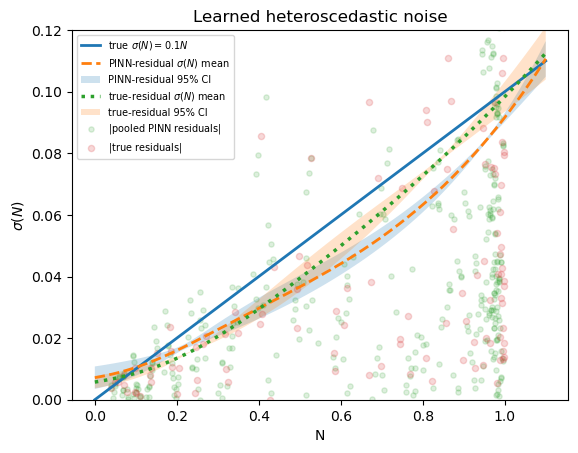

In [ ]:
plt.plot(
    N_grid.cpu().numpy(),
    sigma_true_grid.squeeze(1).cpu().numpy(),
    linewidth=2,
    label=r"true $\sigma(N)=0.1N$",
)
plt.plot(
    N_grid.cpu().numpy(),
    sigma_pinn_mean,
    "--",
    linewidth=2,
    label=r"PINN-residual $\sigma(N)$ mean",
)
plt.fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_pinn_lo,
    sigma_pinn_hi,
    alpha=0.22,
    label="PINN-residual 95% CI",
)
plt.plot(
    N_grid.cpu().numpy(),
    sigma_truefit_mean,
    ":",
    linewidth=2.5,
    label=r"true-residual $\sigma(N)$ mean",
)
plt.fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_truefit_lo,
    sigma_truefit_hi,
    alpha=0.22,
    label="true-residual 95% CI",
)
plt.scatter(
    N_pinn_sigma_all.cpu().numpy().squeeze(),
    np.abs(resid_pinn_sigma_all.cpu().numpy().squeeze()),
    s=14,
    alpha=0.16,
    label=r"$|$pooled PINN residuals$|$",
)
plt.scatter(
    N_true_sigma.cpu().numpy().squeeze(),
    np.abs(resid_true_sigma.cpu().numpy().squeeze()),
    s=20,
    alpha=0.18,
    label=r"$|$true residuals$|$",
)
plt.xlabel("N")
plt.ylabel(r"$\sigma(N)$")
plt.title("Learned heteroscedastic noise")
plt.legend(fontsize=7)
plt.ylim(0, 0.12)